

*   BEN-ZINE Asma
*   AIDOUNE Leaticia


## **Presentation of the Challenge**

# **Bank Term Deposit Prediction: Marketing Campaign Analysis**
**Project Overview**
This project analyzes data from a Portuguese bank's telemarketing campaigns to predict which customers are most likely to subscribe to a term deposit. By identifying patterns in customer attributes and campaign interactions, we aim to build a model that improves targeting efficiency for future marketing efforts.

**Dataset Description**
The dataset captures multiple aspects of the bank's direct marketing campaigns conducted via phone calls between May 2008 and November 2010. It includes 45,211 records with 17 attributes (16 features plus the target variable).

**Feature Categories**
**Personal Information**



*   age: Customer's age
*   job: Professional category (admin, management, student, etc.)
*   marital: Marriage status (married, single, divorced/widowed)
*   education: Educational level (primary, secondary, tertiary, unknown)
*   default: Credit default history (yes/no)
*   balance: Average yearly account balance (euros)
*   housing: Has a mortgage (yes/no)
*   loan: Has a personal loan (yes/no)


**Current Campaign Details**

*   contact: Communication method (cellular, telephone, unknown)
*   day: Day of month of the last contact
*   month: Month of the last contact
*   duration: Length of last call in seconds
*   campaign: Number of contacts during current campaign

**Previous Campaign History**

*   pdays: Days since last contact from a previous campaign (-1 if never contacted)
*   previous: Number of contacts before this campaign
*   poutcome: Result of previous campaign (success, failure, other, unknown)

**Target Variable**

y: Term deposit subscription (yes/no)

**Business Challenge**
The key challenge is to identify which factors best predict a customer's likelihood to subscribe to a term deposit. A successful model would allow the bank to:

Prioritize high-potential prospects
Reduce unsuccessful contact attempts
Increase the return on investment of marketing campaigns
Create more targeted messaging based on customer attributes

This classification model has practical applications in marketing strategy development, campaign planning, and resource allocation for the bank's direct marketing department.

#Loading Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

from sklearn import linear_model, ensemble, svm, naive_bayes, neighbors, metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Lire les données depuis le fichier CSV
data = pd.read_csv('bank-full.csv', delimiter=';')

# Afficher les premières lignes du DataFrame
print(data.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [ ]:
print("\nDataset information:")
print(data.info())

print("\nSummary statistics:")
print(data.describe())

print("\nMissing values:")
print(data.isnull().sum())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Summary statistics:
                age        balance           day   

Although there are no actual NaN values in the dataset, many columns contain 'UNKNOWN' values, which effectively serve as placeholders for missing data, similar to NaN.

In [ ]:
# Replace all occurrences of 'unknown' with NaN.
data.replace('unknown', np.nan, inplace=True)

In [ ]:
print("\nDataset information:")
print(data.info())

print("\nSummary statistics:")
print(data.describe())

print("\nMissing values:")
print(data.isnull().sum())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        44923 non-null  object
 2   marital    45211 non-null  object
 3   education  43354 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    32191 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   8252 non-null   object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Summary statistics:
                age        balance           day   

##Exploratory Data Analysis

##Replace the missing values

Based on the previous results, we observe that 81.95% of the values in the 'poutcome' column are missing. Given this high percentage, we decide to drop the column.

In [ ]:
cols_to_drop = ['poutcome']

if set(cols_to_drop).issubset(data.columns):
    data.drop(columns=cols_to_drop, inplace=True)

In [ ]:
# Gestion des valeurs manquantes
for col in data.columns:
    if data[col].dtype == 'object':  # Si c'est une colonne catégorique
        data[col] = data[col].fillna(data[col].mode()[0])
    else:  # Si c'est une colonne numérique
        data[col] = data[col].fillna(data[col].median())

In [ ]:
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
y            0
dtype: int64


##Analysis of the Target y

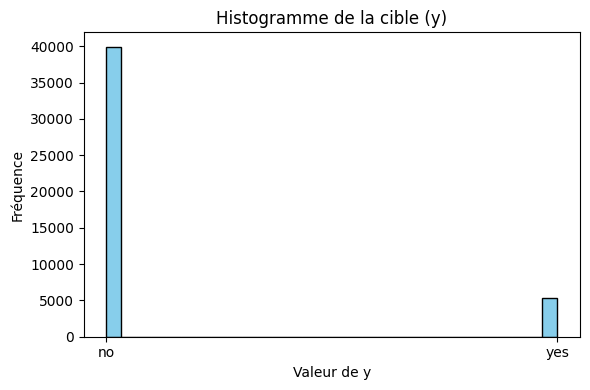

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.hist(data['y'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogramme de la cible (y)')
plt.xlabel('Valeur de y')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()


In [ ]:
print(data['y'].value_counts())
print(data['y'].value_counts(normalize=True) * 100)

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


##### Handling Imbalanced Data in Our Classification Problem  

From the histogram, we observe that our dataset is highly imbalanced:  
- **88.30%** of clients did **not** subscribe to the term deposit ("no").  
- Only **11.69%** of clients **did** subscribe ("yes").  

##### Challenges of Imbalanced Data  
One major issue with imbalanced datasets is that traditional metrics like **accuracy** can be misleading. Since the majority class is "no," a model could achieve high accuracy simply by predicting "no" for most cases. However, such a model would be ineffective in identifying potential subscribers, which is our main goal.  

**Better Metrics for Evaluating Our Model**

To properly assess the model's performance in identifying subscribers, we focus on the following metrics:  

- **Precision**: Measures how many of the predicted "yes" cases are actually correct.  
  - High precision ensures that we don’t waste resources contacting people who are unlikely to subscribe.  

- **Recall**: Measures how many actual subscribers are correctly identified by the model.  
  - High recall ensures that we don’t miss too many potential customers.  

- **F1 Score**: The harmonic mean of precision and recall.  
  - Since both precision and recall are important, we aim to maximize the **F1 score** to balance both.  

- **PR-AUC (Precision-Recall Area Under Curve)**:  
  - This metric measures the trade-off between **precision and recall** at different prediction thresholds.  
  - Unlike ROC-AUC, which can be misleading in imbalanced datasets, **PR-AUC is more informative** because it focuses on the minority class (subscribers).  
  - A high PR-AUC means our model is effectively identifying subscribers without generating too many false positives.  


##Analysis of the correlation

In [ ]:
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features = data.select_dtypes(include=['object']).columns.tolist()

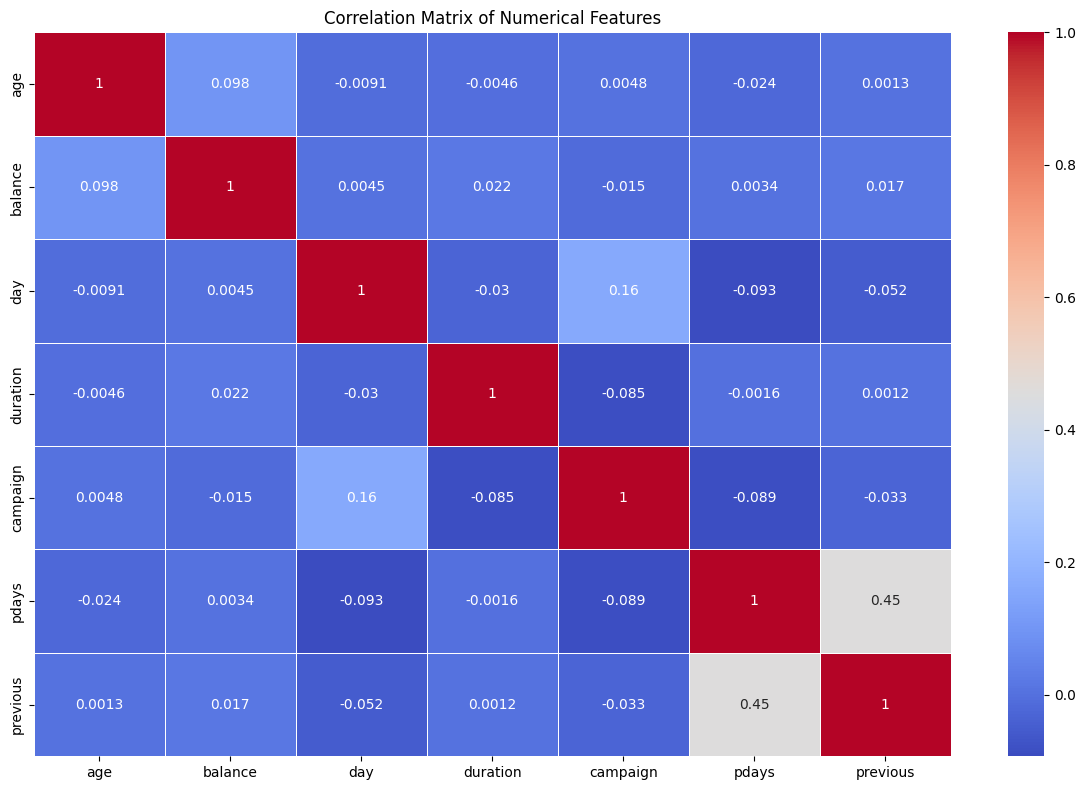

In [ ]:
# Matrice de corrélation pour les variables numériques
plt.figure(figsize=(12, 8))
correlation_matrix = data[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()



As we can see, the correlation between numerical features is generally low, except for **pdays** and **previous**. However, their correlation is not strong enough to be considered significant for our analysis **(0.45)**.  


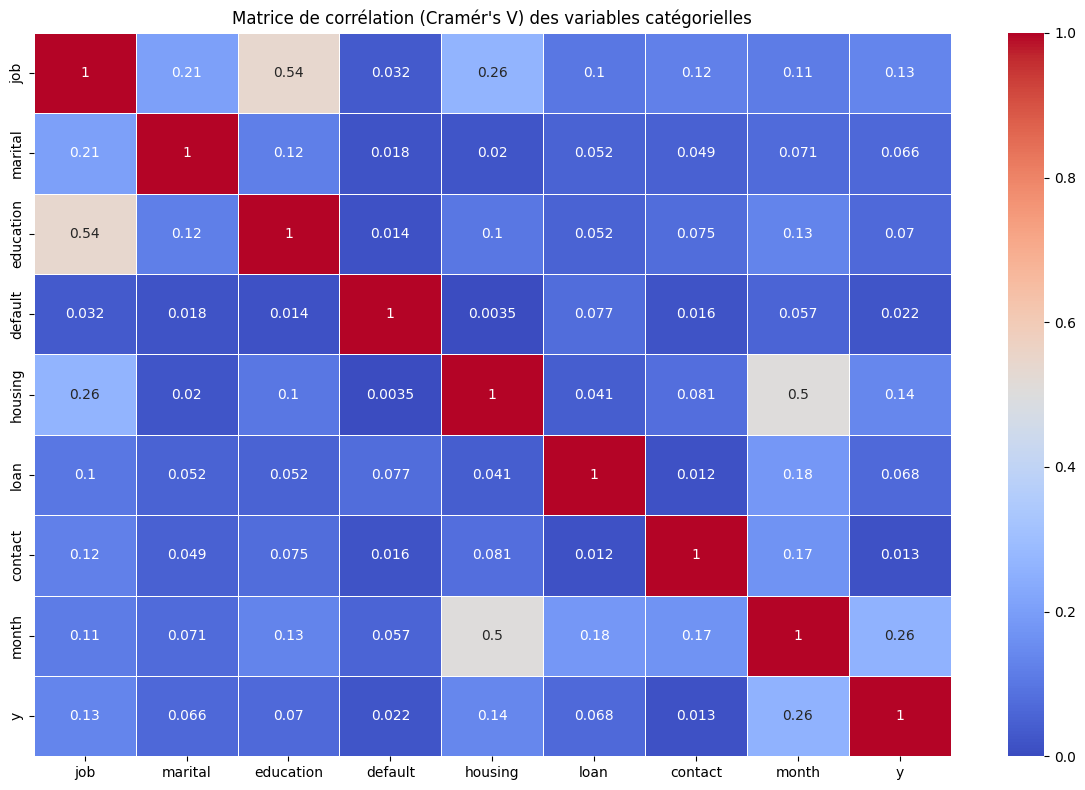

In [ ]:
# calculate Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# confusion matrix based on Cramér's V
correlation_matrix = pd.DataFrame(index=categorical_features, columns=categorical_features)

for i in categorical_features:
    for j in categorical_features:
        correlation_matrix.loc[i, j] = cramers_v(data[i], data[j])


correlation_matrix = correlation_matrix.astype(float)

# display heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=0, vmax=1)
plt.title("Matrice de corrélation (Cramér's V) des variables catégorielles")
plt.tight_layout()
plt.show()

Similarly, the highest correlation between categorical features is **(0.54)** between education and job, and **(0.5)** between housing and month. However, these values are still too low to be considered significant for our analysis. Therefore, since the features are not highly correlated, we will not delete them.

##Analysis of the Features

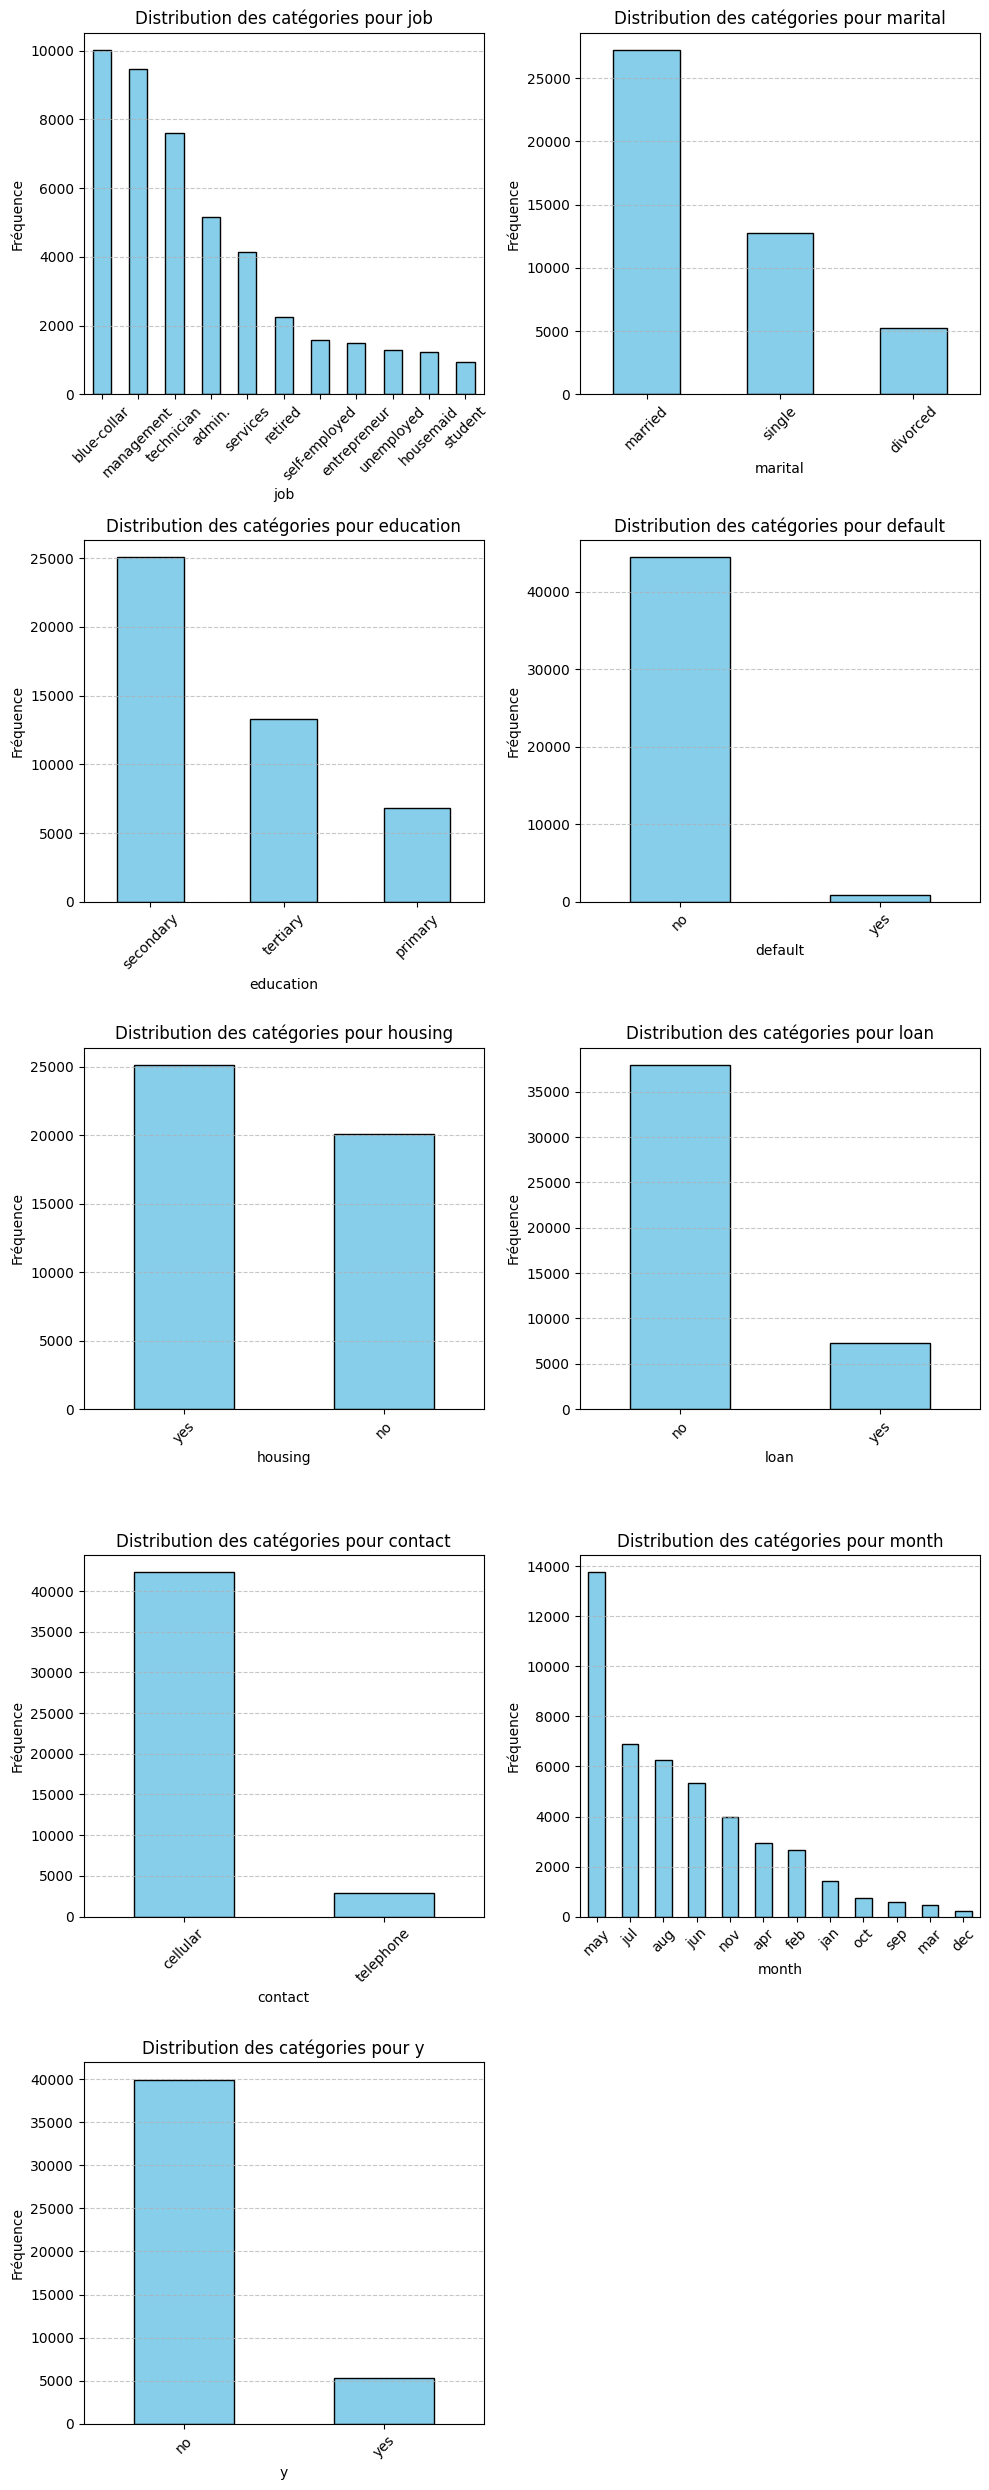

In [ ]:
n_cols = 2
n_rows = (len(categorical_features) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))

axes = axes.flatten()

for i, column in enumerate(categorical_features):
    data[column].value_counts().plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[i])
    axes[i].set_title(f"Distribution des catégories pour {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Fréquence")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

###Detecting Rare Categories

The imbalanced columns are **contact** and **default**, but since they have binary values (yes or no), there isn't much we can do about them.

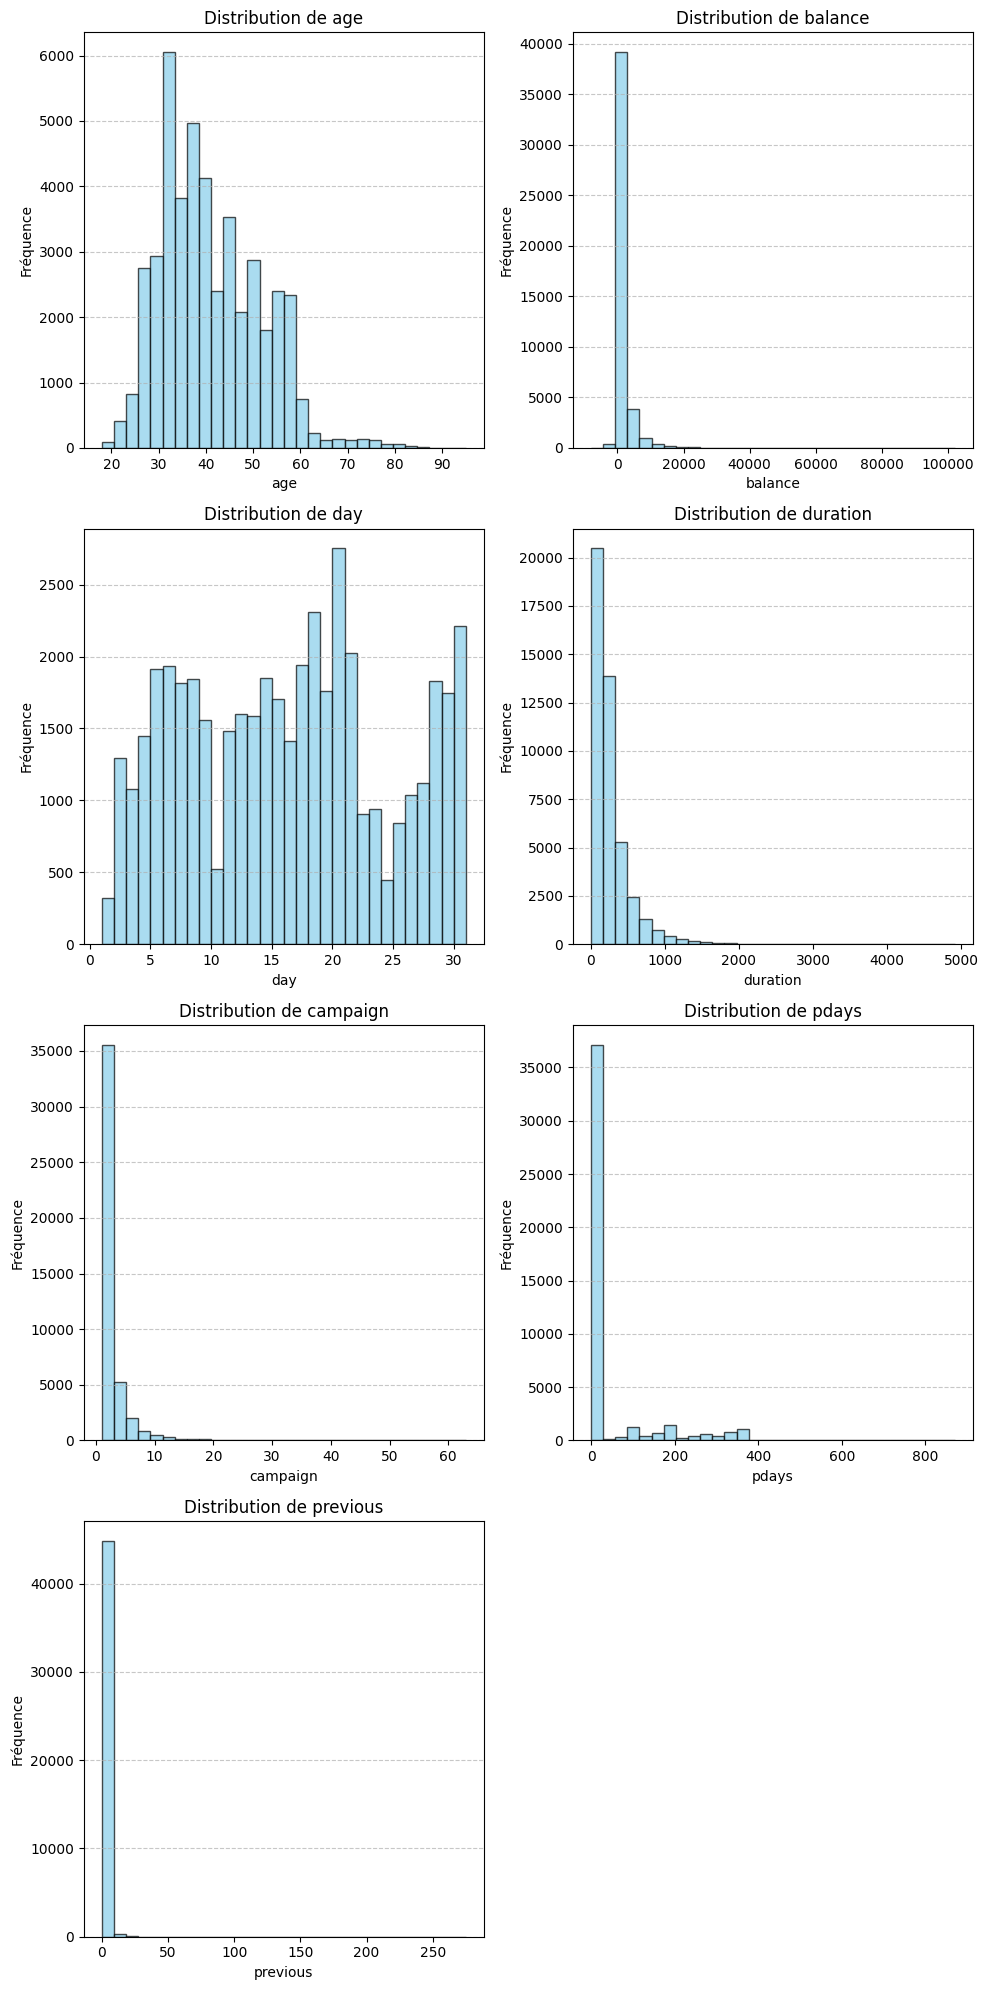

In [ ]:
n_cols = 2
n_rows = (len(numerical_features) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))


axes = axes.flatten()

for i, column in enumerate(numerical_features):
    axes[i].hist(data[column].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f"Distribution de {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Fréquence")
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
numerical_summary = data[numerical_features].describe()
print(numerical_summary)


                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

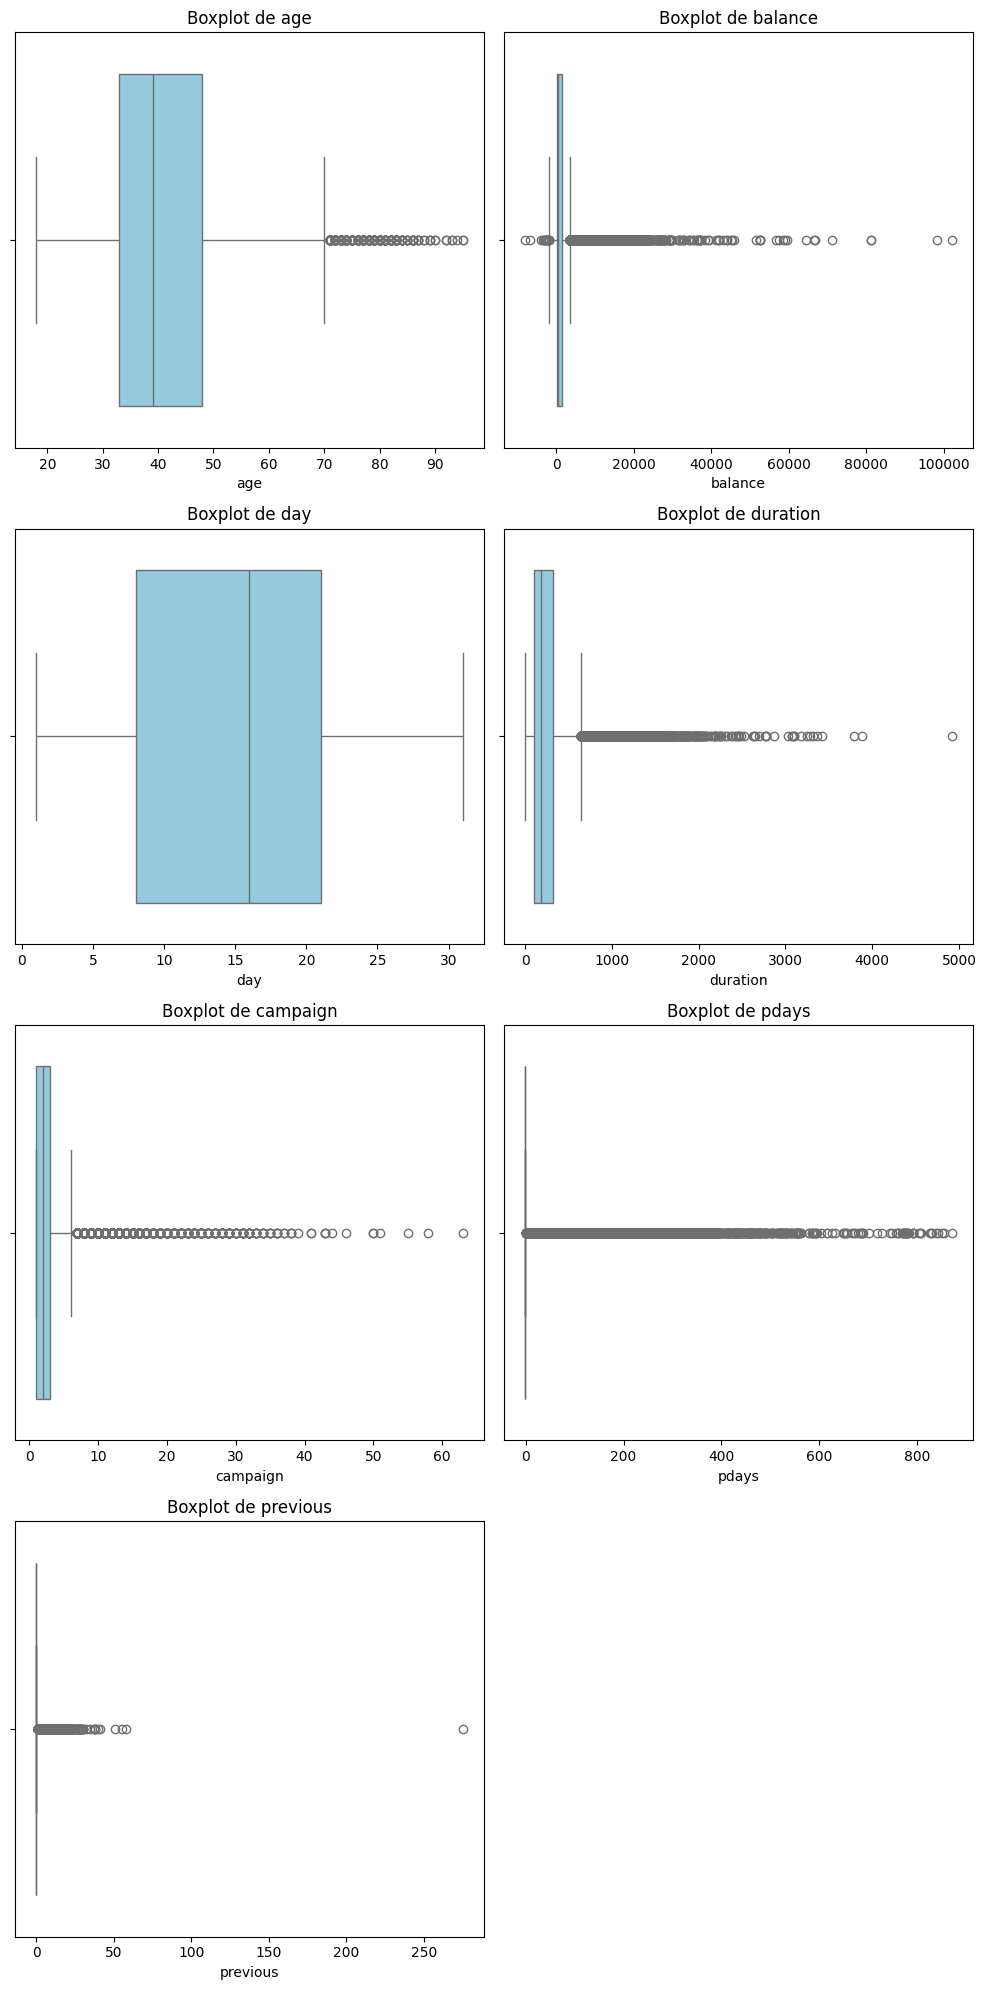

In [ ]:

n_cols = 2
n_rows = (len(numerical_features) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x=data[col], color="skyblue", ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


###Detecting Outliers

From the distribution of the values of the data, we can see that there as many values that we can consider as outliers, such as value 100 of the feature age.
In our current approach we decided de keep the values.

We could also try to replace the outliers with the mean value.

##Deleting other columns

During our analysis, we experimented with dropping features like education and pdays due to their low correlation with the target and their relationship with other features. However, we observed a decrease in model performance, suggesting that these features still contribute valuable information.


Additionally, we faced a dilemma with the "duration" feature, which has a high impact on the target but cannot be used in a real-world predictive model. Removing duration resulted in a significant drop in performance, which aligns with the dataset's description that it should only be used for benchmarking.

To address these challenges, we recommend using duration for benchmarking purposes only and focusing on feature engineering and regularization techniques to improve the performance of our realistic model. This approach ensures that our model is both accurate and applicable in real-world scenarios.

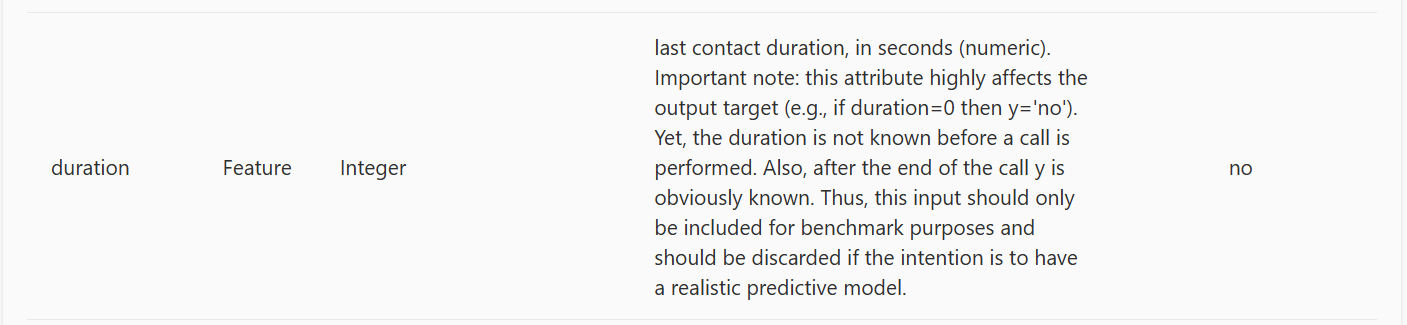

## Analysing the distribution of the numerical values

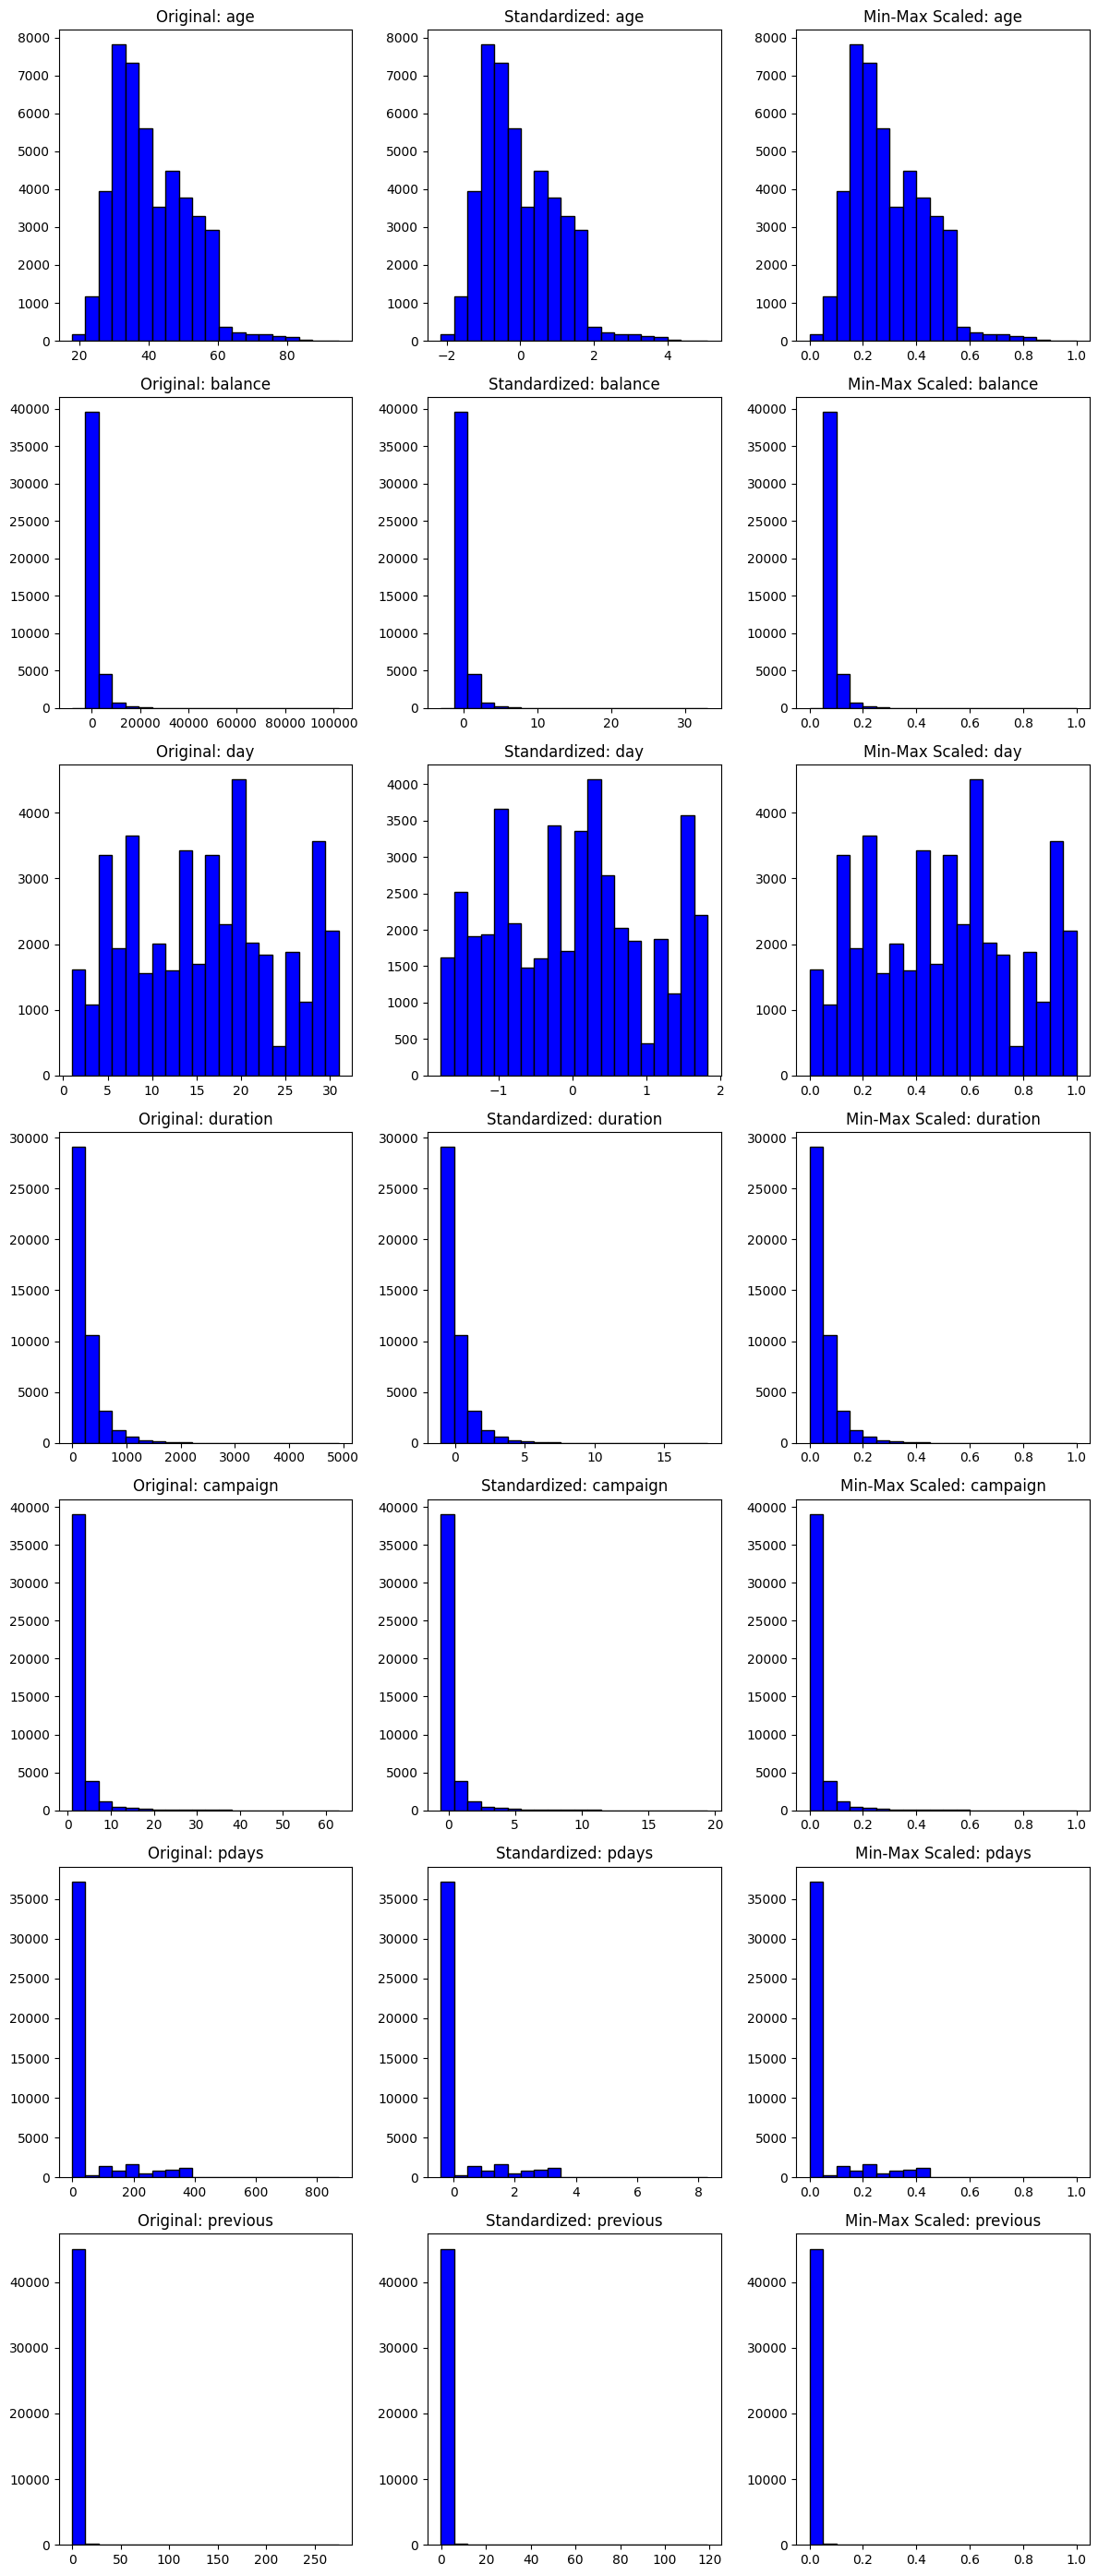

In [ ]:
n_attributes = len(numerical_features)
X = data[numerical_features]

X_scaled = StandardScaler().fit_transform(X)
X_minmax = MinMaxScaler().fit_transform(X)

fig, axes = plt.subplots(n_attributes, 3, figsize=(12, 4 * n_attributes))

for i in range(n_attributes):
   # Original data
  axes[i,0].hist(X.iloc[:,i],bins=20, color = 'blue', align='mid',edgecolor='black')
  axes[i,0].set_title(f"Original: {numerical_features[i]}")
  # Standardized data
  axes[i,1].hist(X_scaled[:,i],bins=20, color = 'blue', align='mid',edgecolor='black')
  axes[i,1].set_title(f"Standardized: {numerical_features[i]}")
  # Min-max scaled data
  axes[i,2].hist(X_minmax[:,i],bins=20, color = 'blue', align='mid',edgecolor='black')
  axes[i,2].set_title(f"Min-Max Scaled: {numerical_features[i]}")

plt.tight_layout()
plt.show()



#Data Preprocessing

##Encoding

In [ ]:
categorical_columns = data.select_dtypes(include=['object']).columns
binary_columns = [col for col in categorical_columns if data[col].nunique() ==2];
ordinal_columns = ['education']
one_hot_encoder_columns = [col for col in categorical_columns if col not in binary_columns and col
                           not in ordinal_columns]

print("\nBinary Columns:", binary_columns)
print("Ordinal Columns:", ordinal_columns)
print("Nominal Columns:", one_hot_encoder_columns)

label_encoder = LabelEncoder()
for col in binary_columns:
  data[col] = label_encoder.fit_transform(data[col])

one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data = one_hot_encoder.fit_transform(data[one_hot_encoder_columns])

ordinal_mapping ={
    'primary':0,
    'secondary':1,
    'tertiary':2,
    'unknown':-1
}

data['education'] = data['education'].map(ordinal_mapping)

encoded_columns = one_hot_encoder.get_feature_names_out(one_hot_encoder_columns)
encoded_df = pd.DataFrame(encoded_data,columns = encoded_columns)

data = pd.concat([data.drop(one_hot_encoder_columns,axis=1),encoded_df],axis=1)
print("\nProcessed Dataset:")
print(data.head())



Binary Columns: ['default', 'housing', 'loan', 'contact', 'y']
Ordinal Columns: ['education']
Nominal Columns: ['job', 'marital', 'month']

Processed Dataset:
   age  education  default  balance  housing  loan  contact  day  duration  \
0   58          2        0     2143        1     0        0    5       261   
1   44          1        0       29        1     0        0    5       151   
2   33          1        0        2        1     1        0    5        76   
3   47          1        0     1506        1     0        0    5        92   
4   33          1        0        1        0     0        0    5       198   

   campaign  ...  month_dec  month_feb  month_jan  month_jul  month_jun  \
0         1  ...        0.0        0.0        0.0        0.0        0.0   
1         1  ...        0.0        0.0        0.0        0.0        0.0   
2         1  ...        0.0        0.0        0.0        0.0        0.0   
3         1  ...        0.0        0.0        0.0        0.0        0.0

#Training Models

To train the models, our approach is to try different methods, test various metrics, and explore different strategies to achieve the best score. We will explain each approach in the following sections.

In The following, we try to organize the whole approach in one or two cells max so it can be easier to run. Hence, the cells might be long.

Moreover, we tried to copy the original data, standardize it, and normalize it in each approach so that they can be executed separately and to avoid data leakage.

###Raw models

Our approach is to split the dataset into two sets: 80% for training and 20% for testing. We define several models, train them on the training data, and evaluate their performance on the test set. The goal is to test the models in their raw form, without any data balancing or hyperparameter tuning.

We train the models using raw data, standardized data, and normalized data to explore different preprocessing techniques and their impact on performance.

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                               Model  Accuracy  Precision    Recall  F1 Score  \
23                  XGBoost (MinMax)  0.904014   0.625661  0.447070  0.521499   
22                     XGBoost (Std)  0.904014   0.625661  0.447070  0.521499   
21                     XGBoost (Raw)  0.904014   0.625661  0.447070  0.521499   
6            Gradient Boosting (Raw)  0.904567   0.634483  0.434783  0.515984   
7            Gradient Boosting (Std)  0.904567   0.634483  0.434783  0.515984   
8         Gradient Boosting (MinMax)  0.904567   0.634483  0.434783  0.515984   
31     Decision Tree (Entropy) (Std)  0.870286   0.445908  0.448015  0.446959   
30     Decision Tree (Entropy) (Raw)  0.869733   0.443925  0.448960  0.446429   
32  Decision Tree (Entropy) (MinMax)  0.869623   0.443511  0.448960  0.446219   
27        Decision Tree (Gini) (Raw)  0.863209   0.418858  0.436673  0.427580   
29     Decision Tree (Gini) (MinMax)  0.862877   0.417572  0.435728  0.426457   
28        Decision Tree (Gin

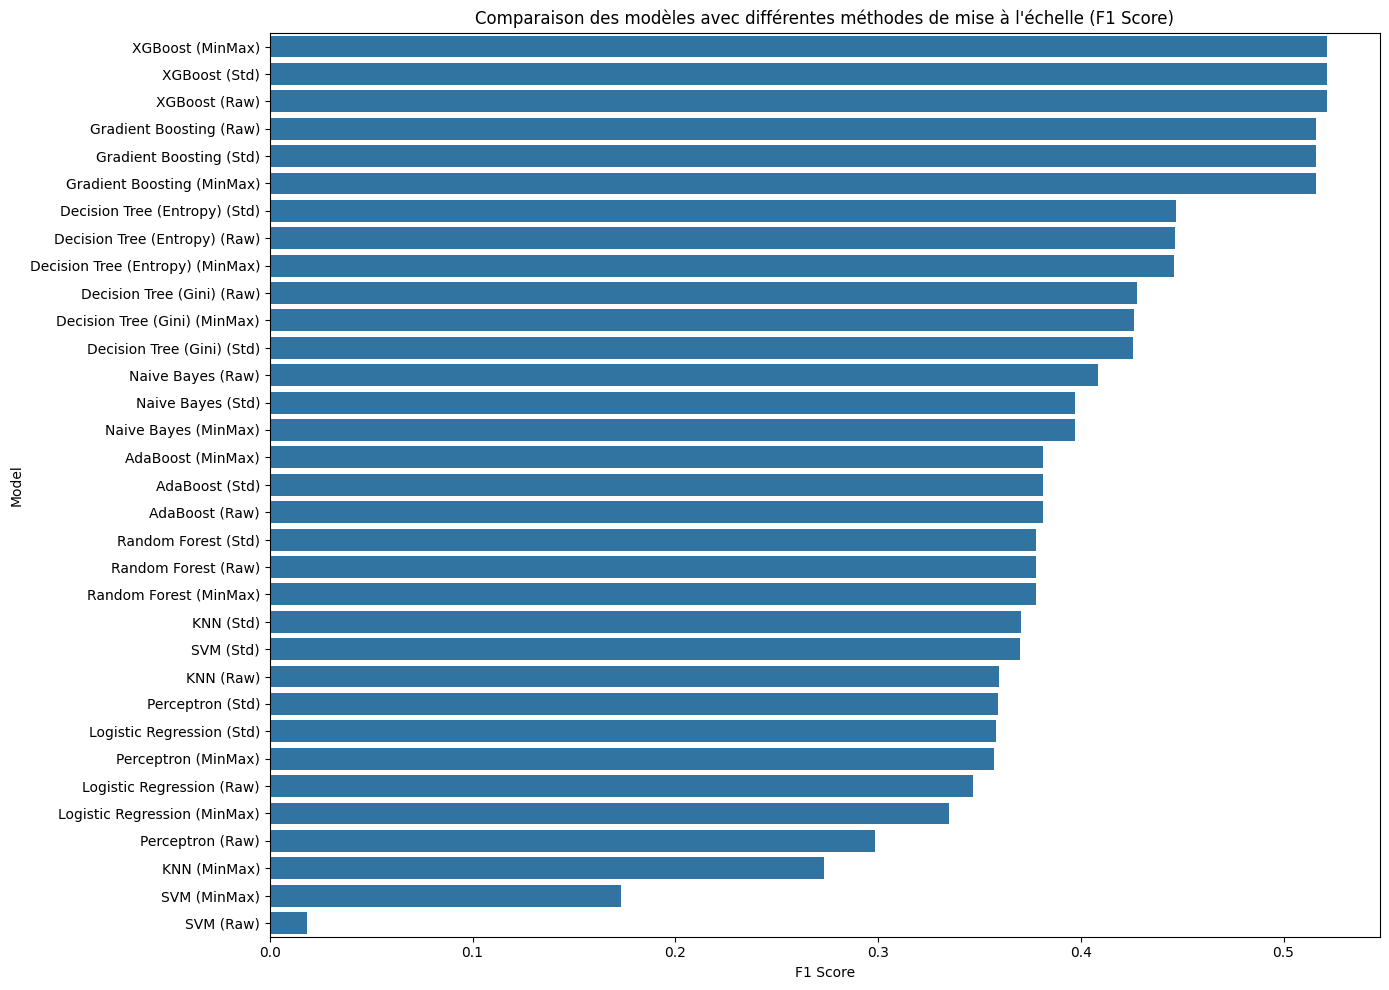


🚀 Meilleures configurations (modèle + scaling) :
                      Model  Accuracy  Precision    Recall  F1 Score  \
23         XGBoost (MinMax)  0.904014   0.625661  0.447070  0.521499   
22            XGBoost (Std)  0.904014   0.625661  0.447070  0.521499   
21            XGBoost (Raw)  0.904014   0.625661  0.447070  0.521499   
6   Gradient Boosting (Raw)  0.904567   0.634483  0.434783  0.515984   
7   Gradient Boosting (Std)  0.904567   0.634483  0.434783  0.515984   

    F1 Score Weighted       AUC    PR AUC  
23           0.896915  0.923378  0.579663  
22           0.896915  0.923378  0.579663  
21           0.896915  0.923378  0.579663  
6            0.896630  0.921063  0.581810  
7            0.896630  0.921067  0.581329  


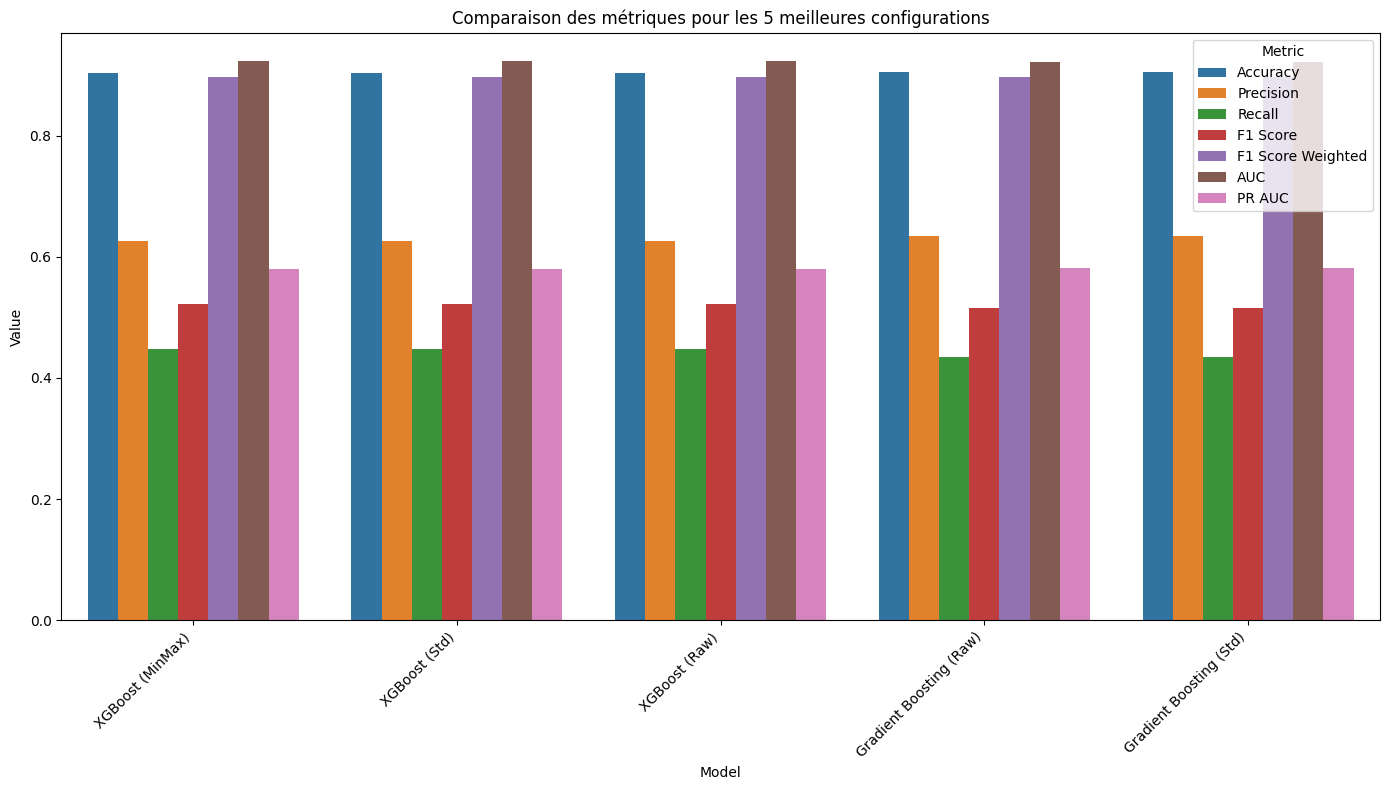

In [ ]:

X = data.drop(columns=['y'])
y = data['y']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

base_models = [
    ('Logistic Regression', linear_model.LogisticRegression(max_iter=3000, random_state=42)),
    ('Random Forest', ensemble.RandomForestClassifier(random_state=42, max_depth=15, min_samples_leaf=5, n_estimators=200)),
    ('Gradient Boosting', ensemble.GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=5)),
    ('SVM', svm.SVC(probability=True, random_state=42)),
    ('Naive Bayes', naive_bayes.GaussianNB()),
    ('AdaBoost', ensemble.AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('KNN', neighbors.KNeighborsClassifier(n_neighbors=5)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=200, learning_rate=0.1, max_depth=6)),
    ('Perceptron', Perceptron(random_state=42)),
    ('Decision Tree (Gini)', DecisionTreeClassifier(criterion='gini', random_state=42)),
    ('Decision Tree (Entropy)', DecisionTreeClassifier(criterion='entropy', random_state=42))
]
#############################################################################################################################################

# Evaluating each model
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    precision, recall, _ = precision_recall_curve(y_test, y_proba) if y_proba is not None else (None, None, None)
    pr_auc = auc(recall, precision) if y_proba is not None else None

    return [
        metrics.accuracy_score(y_test, y_pred),
        metrics.precision_score(y_test, y_pred, pos_label=1),
        metrics.recall_score(y_test, y_pred, pos_label=1),
        metrics.f1_score(y_test, y_pred, pos_label=1),
        metrics.f1_score(y_test, y_pred, average="weighted"),
        metrics.roc_auc_score(y_test, y_proba) if y_proba is not None else None,
        pr_auc
    ]


# evaluate each model with the different scalings
def evaluate_models_with_scalings(base_models, X_train, X_test, X_train_std, X_test_std, X_train_minmax, X_test_minmax, y_train, y_test):
    results = []
    for name, model in base_models:
        raw_results = evaluate_model(model, X_train, X_test, y_train, y_test)
        results.append([f"{name} (Raw)"] + raw_results)

        std_results = evaluate_model(model, X_train_std, X_test_std, y_train, y_test)
        results.append([f"{name} (Std)"] + std_results)

        minmax_results = evaluate_model(model, X_train_minmax, X_test_minmax, y_train, y_test)
        results.append([f"{name} (MinMax)"] + minmax_results)

    return pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "F1 Score Weighted", "AUC", "PR AUC"]).sort_values(by="F1 Score", ascending=False)

# evaluating models
results_df = evaluate_models_with_scalings(base_models, X_train, X_test, X_train_std, X_test_std, X_train_minmax, X_test_minmax, y_train, y_test)
print(results_df)

# Visualisation results (F1 Score)
plt.figure(figsize=(14, 10))
sns.barplot(x="F1 Score", y="Model", data=results_df)
plt.title("Comparaison des modèles avec différentes méthodes de mise à l'échelle (F1 Score)")
plt.tight_layout()
plt.show()


best_configurations = results_df.sort_values(by="F1 Score", ascending=False).head(5)
print("\n🚀 Meilleures configurations (modèle + scaling) :")
print(best_configurations)


metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "F1 Score Weighted", "AUC", "PR AUC"]
best_models_df = best_configurations.melt(id_vars=["Model"], value_vars=metrics_to_plot, var_name="Metric", value_name="Value")

plt.figure(figsize=(14, 8))
sns.barplot(x="Model", y="Value", hue="Metric", data=best_models_df)
plt.title("Comparaison des métriques pour les 5 meilleures configurations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The highest score we achieved using this strategy is from the XGBoost (MinMax) model (the normalized dataSet), with the following performance metrics:

* Accuracy: 0.904014
* Precision: 0.625661
* Recall: 0.447070
* **F1 Score : 0.521499**
* F1 Score Weighted: 0.896915  
* AUC: 0.923378
* PR AUC: 0.579663

##Balanced Models

Since our data is highly imbalanced, we defined our models with **class_weight='balanced'**. This setting automatically adjusts the weight of each class based on its frequency in the dataset, helping the model pay more attention to the minority class and reduce bias towards the majority class.
[Reference](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                           Model  Accuracy  Precision    Recall  \
22                 XGBoost (Std)  0.863651   0.454640  0.828922   
21                 XGBoost (Raw)  0.863651   0.454640  0.828922   
23              XGBoost (MinMax)  0.863651   0.454640  0.828922   
3            Random Forest (Raw)  0.857901   0.441161  0.804348   
4            Random Forest (Std)  0.857901   0.441161  0.804348   
5         Random Forest (MinMax)  0.857791   0.440933  0.804348   
10                     SVM (Std)  0.833684   0.400179  0.844991   
11                  SVM (MinMax)  0.837112   0.403802  0.823251   
8     Gradient Boosting (MinMax)  0.904567   0.634483  0.434783   
7        Gradient Boosting (Std)  0.904567   0.634483  0.434783   
6        Gradient Boosting (Raw)  0.904567   0.634483  0.434783   
1      Logistic Regression (Std)  0.822183   0.375903  0.787335   
2   Logistic Regression (MinMax)  0.821741   0.374774  0.783554   
0      Logistic Regression (Raw)  0.819418   0.371823  0.78828

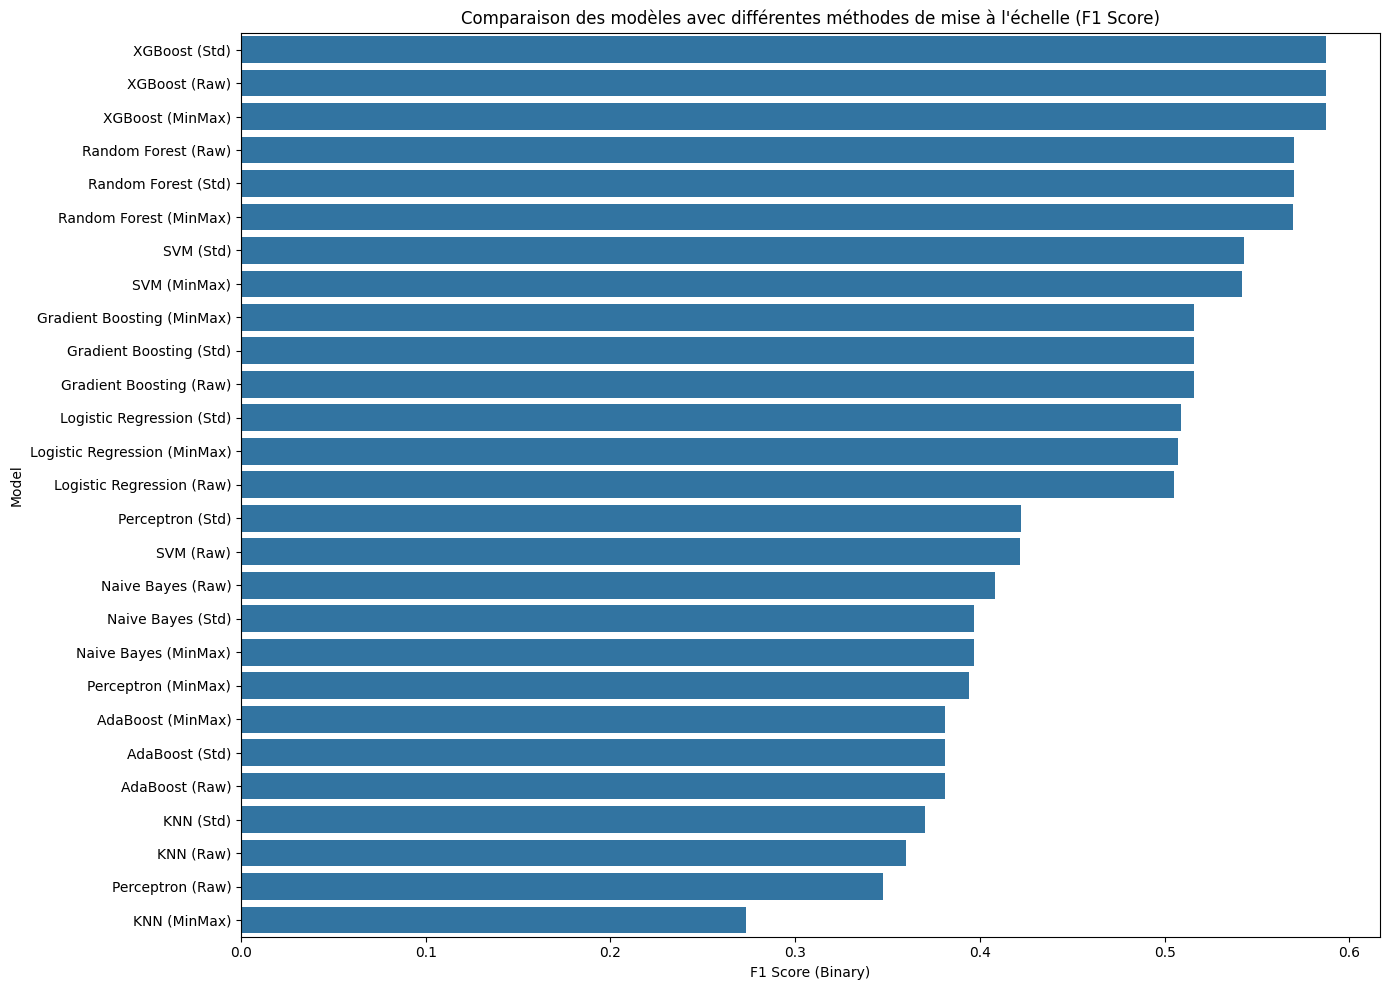


🚀 Meilleures configurations (modèle + scaling) :
                  Model  Accuracy  Precision    Recall  F1 Score (Binary)  \
22        XGBoost (Std)  0.863651   0.454640  0.828922           0.587211   
21        XGBoost (Raw)  0.863651   0.454640  0.828922           0.587211   
23     XGBoost (MinMax)  0.863651   0.454640  0.828922           0.587211   
3   Random Forest (Raw)  0.857901   0.441161  0.804348           0.569802   
4   Random Forest (Std)  0.857901   0.441161  0.804348           0.569802   

    F1 Score (Weighted)       AUC    PR AUC  
22             0.879598  0.922295  0.573948  
21             0.879598  0.922295  0.573948  
23             0.879598  0.922295  0.573948  
3              0.874520  0.916830  0.560351  
4              0.874520  0.916878  0.560319  


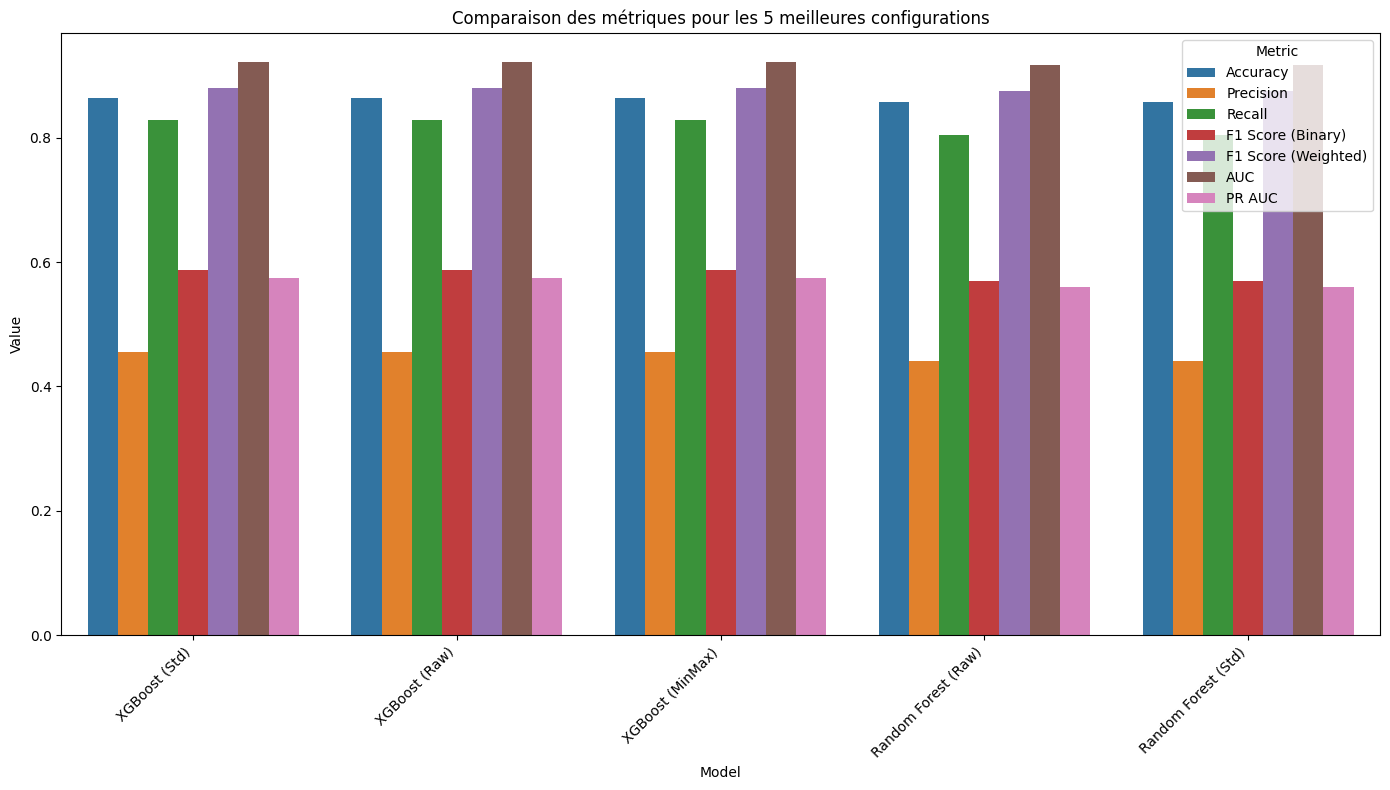

In [ ]:
X = data.drop(columns=['y'])
y = data['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

# our models
base_models = [
    ('Logistic Regression', linear_model.LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')),
    ('Random Forest', ensemble.RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=15, min_samples_leaf=5, n_estimators=200)),
    ('Gradient Boosting', ensemble.GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=5)),
    ('SVM', svm.SVC(probability=True, random_state=42, class_weight='balanced')),
    ('Naive Bayes', naive_bayes.GaussianNB()),
    ('AdaBoost', ensemble.AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('KNN', neighbors.KNeighborsClassifier(n_neighbors=5)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=200, learning_rate=0.1, max_depth=6,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())),
    ('Perceptron', Perceptron(random_state=42, class_weight='balanced'))
]



def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    precision, recall, _ = precision_recall_curve(y_test, y_proba) if y_proba is not None else (None, None, None)
    pr_auc = auc(recall, precision) if y_proba is not None else None

    return [
      metrics.accuracy_score(y_test, y_pred),
      metrics.precision_score(y_test, y_pred, pos_label=1),
      metrics.recall_score(y_test, y_pred, pos_label=1),
      metrics.f1_score(y_test, y_pred, pos_label=1),
      metrics.f1_score(y_test, y_pred, average="weighted"),
      metrics.roc_auc_score(y_test, y_proba) if y_proba is not None else None,
      pr_auc
    ]

def evaluate_models_with_scalings(base_models, X_train, X_test, X_train_std, X_test_std, X_train_minmax, X_test_minmax, y_train, y_test):
    results = []
    for name, model in base_models:
        raw_results = evaluate_model(model, X_train, X_test, y_train, y_test)
        results.append([f"{name} (Raw)"] + raw_results)

        std_results = evaluate_model(model, X_train_std, X_test_std, y_train, y_test)
        results.append([f"{name} (Std)"] + std_results)

        minmax_results = evaluate_model(model, X_train_minmax, X_test_minmax, y_train, y_test)
        results.append([f"{name} (MinMax)"] + minmax_results)

    return pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score (Binary)", "F1 Score (Weighted)", "AUC", "PR AUC"]).sort_values(by="F1 Score (Binary)", ascending=False)  # Correction ici


results_df = evaluate_models_with_scalings(base_models, X_train, X_test, X_train_std, X_test_std, X_train_minmax, X_test_minmax, y_train, y_test)
print(results_df)

# show results
plt.figure(figsize=(14, 10))
sns.barplot(x="F1 Score (Binary)", y="Model", data=results_df)
plt.title("Comparaison des modèles avec différentes méthodes de mise à l'échelle (F1 Score)")
plt.tight_layout()
plt.show()

# best models
best_configurations = results_df.sort_values(by="F1 Score (Binary)", ascending=False).head(5)
print("\n🚀 Meilleures configurations (modèle + scaling) :")
print(best_configurations)

# metrics for top models
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score (Binary)", "F1 Score (Weighted)", "AUC", "PR AUC"]
best_models_df = best_configurations.melt(id_vars=["Model"], value_vars=metrics_to_plot, var_name="Metric", value_name="Value")

plt.figure(figsize=(14, 8))
sns.barplot(x="Model", y="Value", hue="Metric", data=best_models_df)
plt.title("comparing 5 best configurations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Our scores are  better than the raw models when using class_weight='balanced'. The highest score we achieved this time is from XGBoost (Std) model, with the following performance metrics:

* Accuracy: 0.863651
* Precision: 0.454640
* Recall: 0.828922
* **F1 Score (Binary): 0.587211**
* F1 Score (Weighted): 0.879598
* AUC: 0.922295
* PR AUC: 0.573948

The F1 score improved from 0.52 to 0.587

##Balancing Data using SMOTE

Another approach to balance the data is to use SMOTE, which generates synthetic samples for the minority class to help the model better learn from imbalanced data.
[Reference](https://www.analyticsvidhya.com/blog/2020/10/overcoming-class-imbalance-using-smote-techniques/)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                           Model  Accuracy  Precision    Recall  \
3            Random Forest (Raw)  0.893398   0.537420  0.637996   
21                 XGBoost (Raw)  0.854805   0.437408  0.842155   
8     Gradient Boosting (MinMax)  0.901028   0.580933  0.552930   
4            Random Forest (Std)  0.863983   0.451412  0.755198   
5         Random Forest (MinMax)  0.861108   0.445000  0.757089   
22                 XGBoost (Std)  0.841093   0.414215  0.864839   
23              XGBoost (MinMax)  0.838328   0.410382  0.874291   
7        Gradient Boosting (Std)  0.900476   0.581781  0.531191   
10                     SVM (Std)  0.842088   0.412405  0.823251   
11                  SVM (MinMax)  0.844852   0.415066  0.796786   
6        Gradient Boosting (Raw)  0.903461   0.616352  0.463138   
16                AdaBoost (Std)  0.883114   0.500434  0.545369   
17             AdaBoost (MinMax)  0.882672   0.498674  0.533081   
1      Logistic Regression (Std)  0.823731   0.378292  0.78733

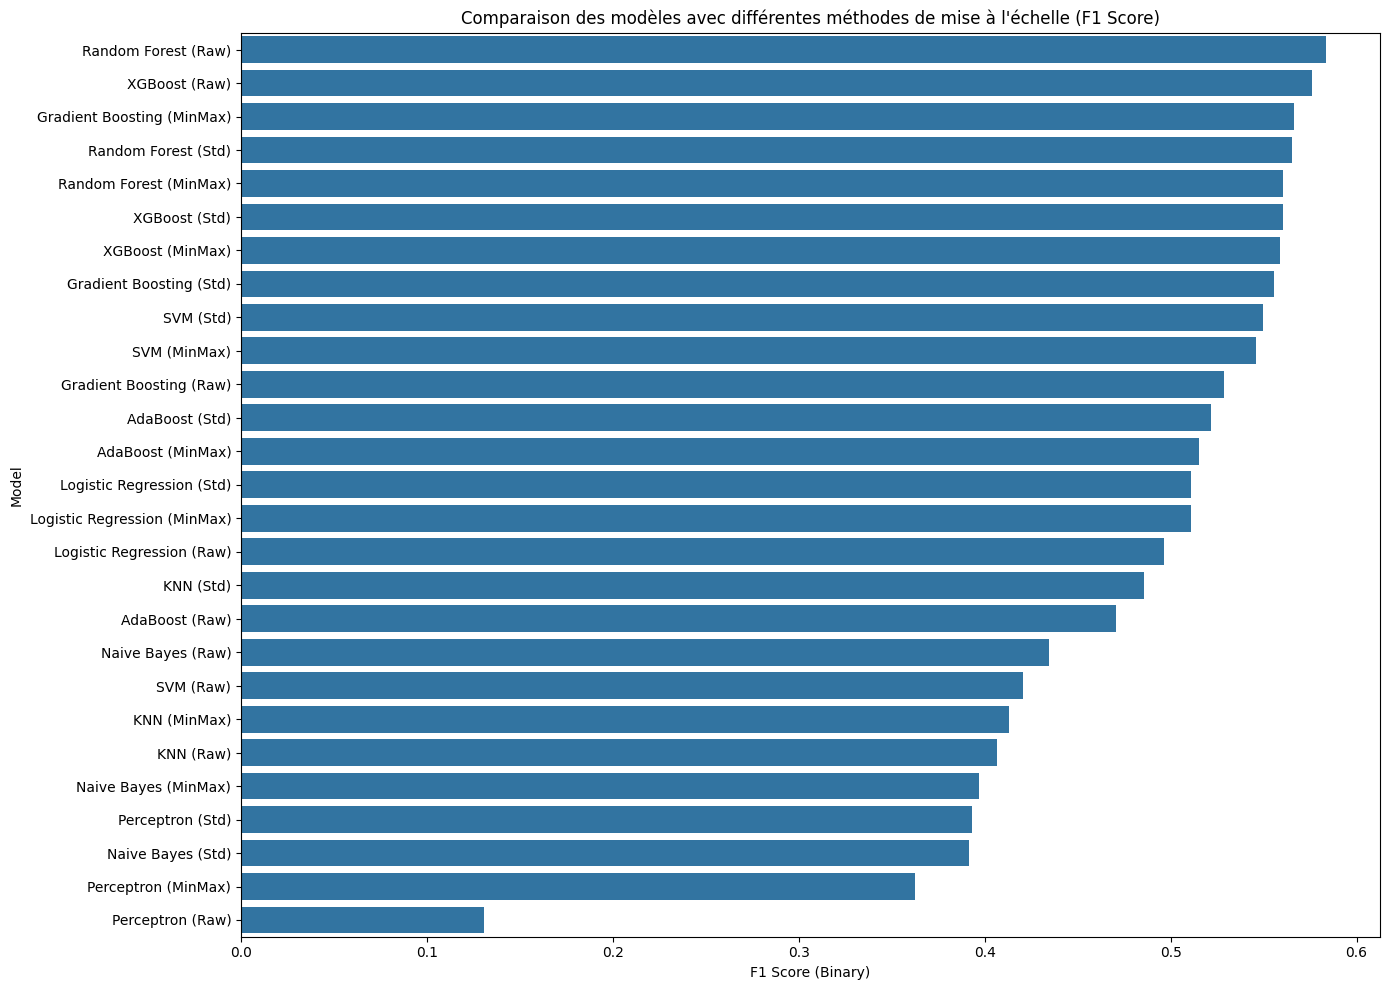


🚀 Meilleures configurations (modèle + scaling) :
                         Model  Accuracy  Precision    Recall  \
3          Random Forest (Raw)  0.893398   0.537420  0.637996   
21               XGBoost (Raw)  0.854805   0.437408  0.842155   
8   Gradient Boosting (MinMax)  0.901028   0.580933  0.552930   
4          Random Forest (Std)  0.863983   0.451412  0.755198   
5       Random Forest (MinMax)  0.861108   0.445000  0.757089   

    F1 Score (Binary)  F1 Score (Weighted)       AUC    PR AUC  
3            0.583405             0.897290  0.913493  0.541961  
21           0.575767             0.873028  0.919610  0.574932  
8            0.566586             0.899964  0.920339  0.570230  
4            0.565064             0.877932  0.911149  0.537332  
5            0.560532             0.875754  0.910836  0.538270  


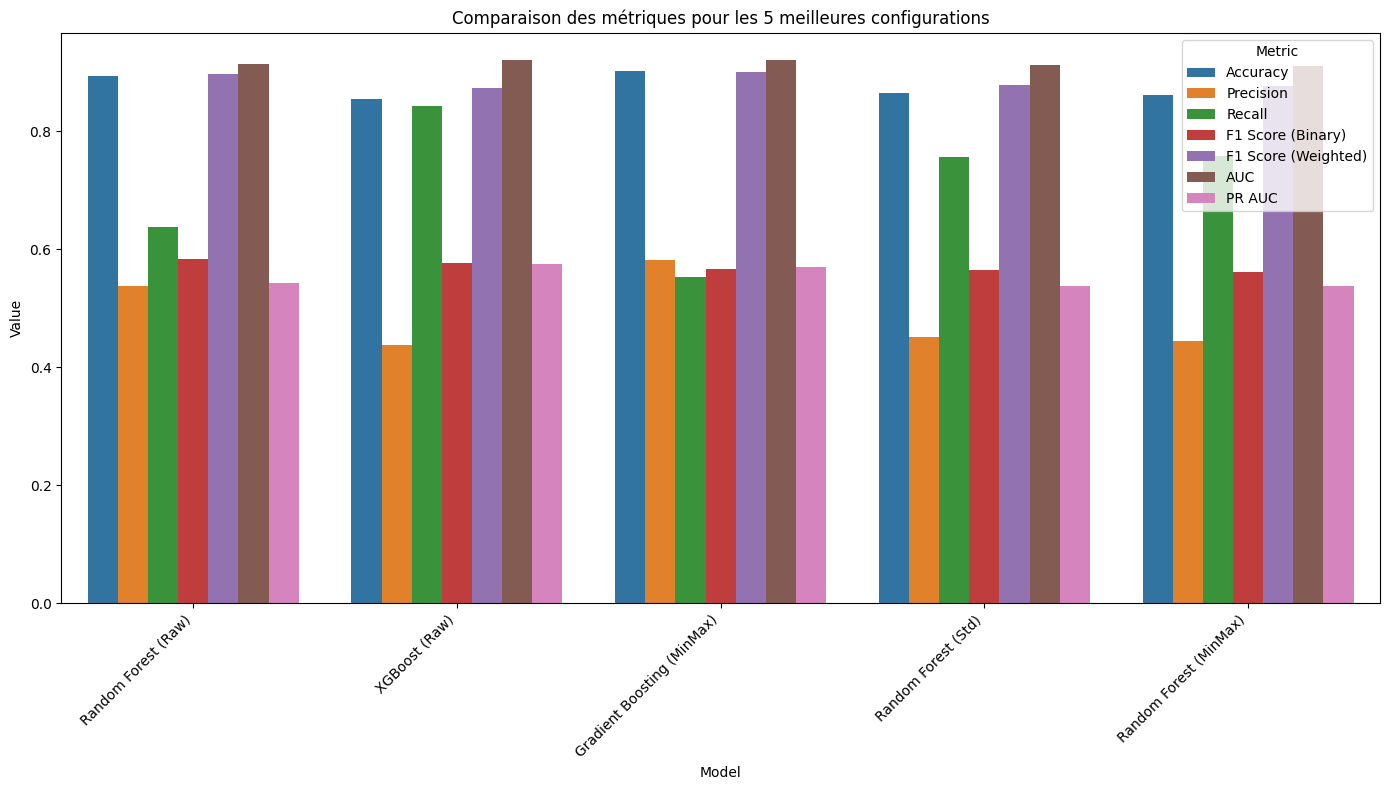

In [ ]:
X = data.drop(columns=['y'])
y = data['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

# our base models
base_models = [
    ('Logistic Regression', linear_model.LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')),
    ('Random Forest', ensemble.RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=15, min_samples_leaf=5, n_estimators=200)),
    ('Gradient Boosting', ensemble.GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=5)),
    ('SVM', svm.SVC(probability=True, random_state=42, class_weight='balanced')),
    ('Naive Bayes', naive_bayes.GaussianNB()),
    ('AdaBoost', ensemble.AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('KNN', neighbors.KNeighborsClassifier(n_neighbors=5)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=200, learning_rate=0.1, max_depth=6,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())),
    ('Perceptron', Perceptron(random_state=42, class_weight='balanced'))

]

def evaluate_model(model, X_train, X_test, y_train, y_test):
    # we aply smote on training data
    smote = SMOTE(sampling_strategy=0.5, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None


    precision, recall, _ = precision_recall_curve(y_test, y_proba) if y_proba is not None else (None, None, None)
    pr_auc = auc(recall, precision) if y_proba is not None else None

    return [
        metrics.accuracy_score(y_test, y_pred),
        metrics.precision_score(y_test, y_pred, pos_label=1),
        metrics.recall_score(y_test, y_pred, pos_label=1),
        metrics.f1_score(y_test, y_pred, pos_label=1),
        metrics.f1_score(y_test, y_pred, average="weighted"),
        metrics.roc_auc_score(y_test, y_proba) if y_proba is not None else None,
        pr_auc
    ]

def evaluate_models_with_scalings(base_models, X_train, X_test, X_train_std, X_test_std, X_train_minmax, X_test_minmax, y_train, y_test):
    results = []

    for name, model in base_models:
        raw_results = evaluate_model(model, X_train, X_test, y_train, y_test)
        results.append([f"{name} (Raw)"] + raw_results)

        # standarized data
        std_results = evaluate_model(model, X_train_std, X_test_std, y_train, y_test)
        results.append([f"{name} (Std)"] + std_results)

        # normalized data
        minmax_results = evaluate_model(model, X_train_minmax, X_test_minmax, y_train, y_test)
        results.append([f"{name} (MinMax)"] + minmax_results)

    # result dataframe
    return pd.DataFrame(results, columns=[
        "Model", "Accuracy", "Precision", "Recall", "F1 Score (Binary)", "F1 Score (Weighted)", "AUC", "PR AUC"
    ]).sort_values(by="F1 Score (Binary)", ascending=False)

# evaluation
results_df = evaluate_models_with_scalings(base_models, X_train, X_test, X_train_std, X_test_std, X_train_minmax, X_test_minmax, y_train, y_test)
print(results_df)

# Visualisation
plt.figure(figsize=(14, 10))
sns.barplot(x="F1 Score (Binary)", y="Model", data=results_df)
plt.title("Comparaison des modèles avec différentes méthodes de mise à l'échelle (F1 Score)")
plt.tight_layout()
plt.show()


best_configurations = results_df.sort_values(by="F1 Score (Binary)", ascending=False).head(5)
print("\n Meilleures configurations (modèle + scaling) :")
print(best_configurations)

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score (Binary)", "F1 Score (Weighted)", "AUC", "PR AUC"]
best_models_df = best_configurations.melt(id_vars=["Model"], value_vars=metrics_to_plot, var_name="Metric", value_name="Value")

plt.figure(figsize=(14, 8))
sns.barplot(x="Model", y="Value", hue="Metric", data=best_models_df)
plt.title("Comparaison of best metrics")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Our highest score using this strategy is from the Random Forest (Raw: Original data ) model, with the following performance metrics:

* Accuracy: 0.893398
* Precision: 0.537420
* Recall: 0.637996
* **F1 Score (Binary): 0.583405**
* F1 Score (Weighted): 0.897290
* AUC: 0.913493

The difference between this approach using SMOTE and the class_weight='balanced' approach is very small. The F1 score slightly decreased from 0.587211 to 0.583405

Based on the previous results, we decided to improve the performance of the top 2 best-performing models by tuning their hyperparameters. We used Grid Search with cross-validation on the balanced data, applying SMOTE to address class imbalance, in order to find the optimal hyperparameters. After tuning, we used the optimized models to make predictions on the test set

In [ ]:
best_models = [
    "Random Forest (Raw)",
    "XGBoost (Raw)",           # these two are top performing based on the previous results
]
# Defining hyperparameters to test
param_grids = {
    'Random Forest (Raw)': {
        'n_estimators': [300],  ## i only defined one setup to use, but i ve tested withs several this is the best for our model so far, it takes a lot of time otherwise
        'max_depth': [None],
        'min_samples_split': [2],
        'min_samples_leaf': [2],
        'bootstrap': [False]
    },
    'XGBoost (Raw)': {
        'n_estimators': [200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    }
}
def tune_and_evaluate_model(model_name, model, param_grid, X_train, X_test, y_train, y_test):

    # Apply smote in training set
    smote = SMOTE(sampling_strategy=0.25, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # GridSearchCV for  tuning
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='f1', cv=3, n_jobs=-1)
    grid_search.fit(X_train_resampled, y_train_resampled)

    # best hypermarameters
    best_params = grid_search.best_params_
    print(f"Meilleurs hyperparamètres pour {model_name}: {best_params}")

    # predictions on test set
    y_test_pred = grid_search.predict(X_test)
    y_test_proba = grid_search.predict_proba(X_test)[:, 1] if hasattr(grid_search, "predict_proba") else None

    # metrics for test set
    test_metrics = [
        metrics.accuracy_score(y_test, y_test_pred),
        metrics.precision_score(y_test, y_test_pred, pos_label=1),
        metrics.recall_score(y_test, y_test_pred, pos_label=1),
        metrics.f1_score(y_test, y_test_pred, pos_label=1),
        metrics.f1_score(y_test, y_test_pred, average="weighted"),  # Ajout du F1 Score Weighted
        metrics.roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None,
    ]


    if y_test_proba is not None:
        try:
            precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
            pr_auc = auc(recall, precision)
        except ValueError:
            print(f"Warning: Could not compute PR AUC for {model_name} (non-monotonic recall values).")
            pr_auc = None
    else:
        pr_auc = None

    test_metrics.append(pr_auc)

    return test_metrics, best_params
############################################################################################################################################
final_results = []

for model_name in best_models:

    model = next(model for name, model in base_models if model_name.startswith(name))


    param_grid = param_grids.get(model_name, {})


    if not param_grid:
        print(f"Aucune grille d'hyperparamètres définie pour {model_name}. Skipping...")
        continue


    test_metrics, best_params = tune_and_evaluate_model(
        model_name, model, param_grid, X_train_std, X_test_std, y_train, y_test
    )


    final_results.append([model_name] + test_metrics + [best_params])

# dataframe to display results
final_results_df = pd.DataFrame(final_results, columns=[
    "Model", "Test Accuracy", "Test Precision", "Test Recall", "Test F1 Score (Binary)",
    "Test F1 Score (Weighted)", "Test AUC", "Test PR AUC", "Best Params"
])


print("Résultats finaux des modèles :")
print(final_results_df)

final_results_df_filtered = final_results_df[final_results_df["Best Params"].astype(bool)]

Meilleurs hyperparamètres pour Random Forest (Raw): {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Meilleurs hyperparamètres pour XGBoost (Raw): {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Résultats finaux des modèles :
                 Model  Test Accuracy  Test Precision  Test Recall  \
0  Random Forest (Raw)       0.893177        0.537097     0.629490   
1        XGBoost (Raw)       0.871060        0.470232     0.806238   

   Test F1 Score (Binary)  Test F1 Score (Weighted)  Test AUC  Test PR AUC  \
0                0.579634                  0.896791   0.91869     0.558111   
1                0.594011                  0.884827   0.91904     0.571076   

                                         Best Params  
0  {'bootstrap': False, 'max_depth': None, 'min_s...  
1  {'learning_rate': 0.1, 'max_depth': 7, 'n_esti...  


Our method for finding the best hyperparameters slightly improved the F1 score, increasing to 0.59 with the XGBoost on raw data.

The highest score achieved is with the XGBoost (Raw) model, with the following performance metrics:

* Test Accuracy: 0.87
* Test Precision: 0.458333
* Test Recall: 0.634615
* **Test F1 Score: 0.594011**
* Test F1 Score weighted: 0.884827
* Test AUC: 0.91904
* Test PR AUC: 0.571076

The accuracy remains fairly stable, ranging from 0.87 to 0.89

##Balancing data using smote and dividing data into 3 sets

Our approach is to divide the dataset into 3 sets, training, validation and test.


                    Model  Accuracy  Precision    Recall  F1 Score  \
3           XGBoost (Raw)  0.856116   0.439941  0.841210  0.577735   
0     Random Forest (Raw)  0.890400   0.526779  0.622873  0.570810   
4           XGBoost (Std)  0.841960   0.415335  0.860113  0.560172   
5        XGBoost (MinMax)  0.838089   0.408062  0.851607  0.551745   
1     Random Forest (Std)  0.857996   0.437152  0.742911  0.550420   
2  Random Forest (MinMax)  0.858328   0.437395  0.736295  0.548785   

   F1 Score Weighted       AUC    PR AUC  
3           0.874022  0.923348  0.572597  
0           0.894310  0.913604  0.537175  
4           0.863481  0.919230  0.561003  
5           0.860312  0.917145  0.554409  
1           0.872943  0.908890  0.527484  
2           0.873008  0.908443  0.523418  


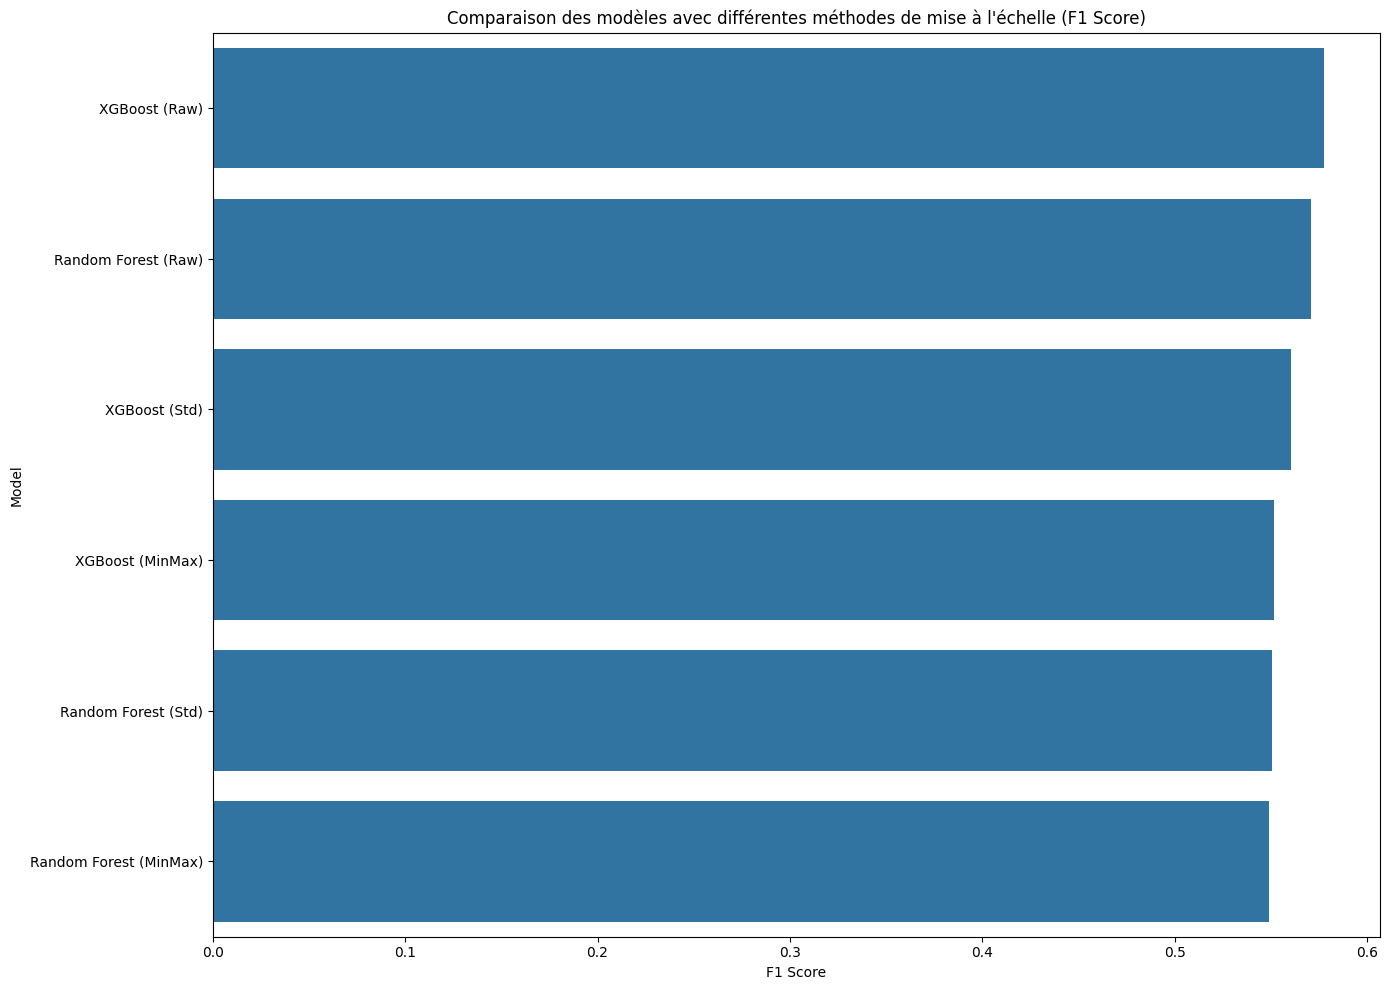


🚀 Meilleures configurations (modèle + scaling) :
                 Model  Accuracy  Precision    Recall  F1 Score  \
3        XGBoost (Raw)  0.856116   0.439941  0.841210  0.577735   
0  Random Forest (Raw)  0.890400   0.526779  0.622873  0.570810   
4        XGBoost (Std)  0.841960   0.415335  0.860113  0.560172   
5     XGBoost (MinMax)  0.838089   0.408062  0.851607  0.551745   
1  Random Forest (Std)  0.857996   0.437152  0.742911  0.550420   

   F1 Score Weighted       AUC    PR AUC  
3           0.874022  0.923348  0.572597  
0           0.894310  0.913604  0.537175  
4           0.863481  0.919230  0.561003  
5           0.860312  0.917145  0.554409  
1           0.872943  0.908890  0.527484  


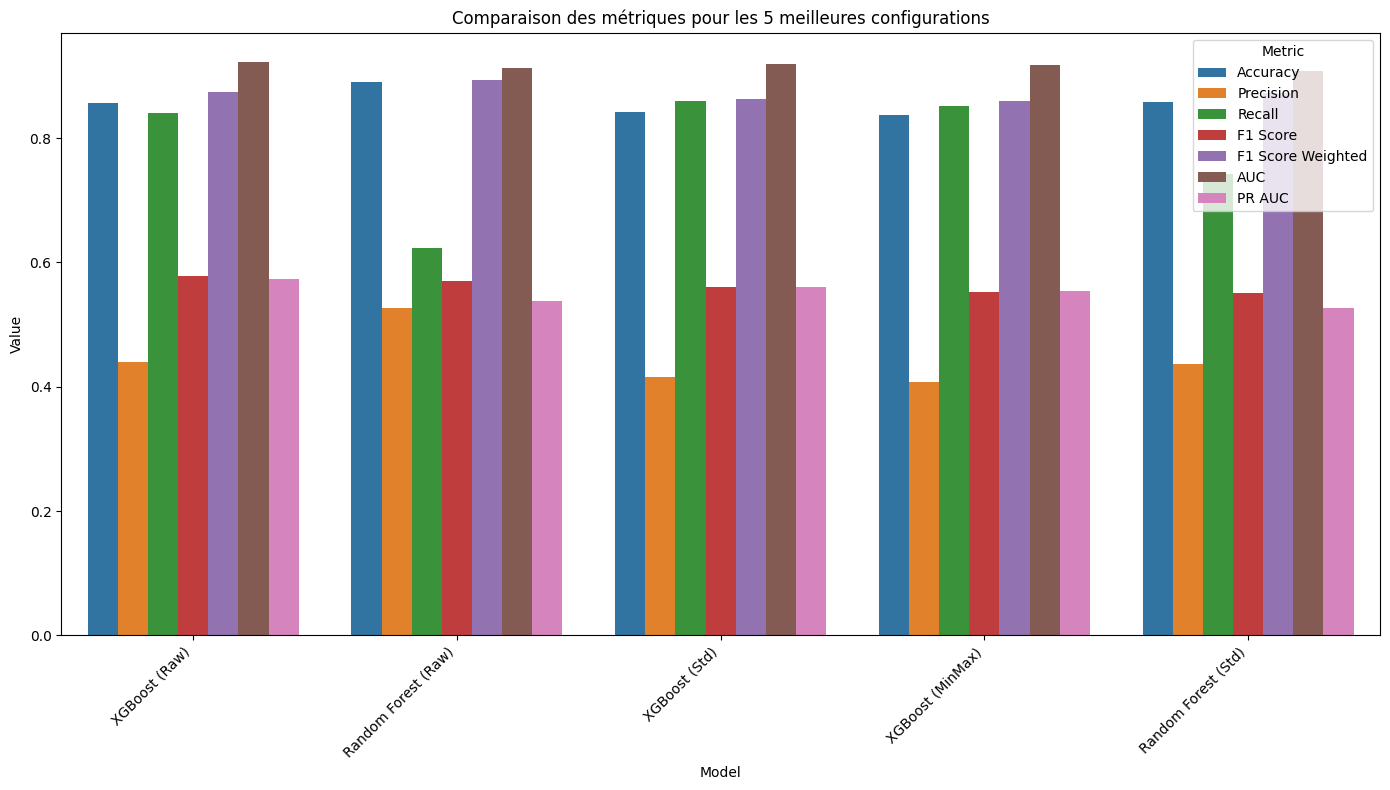

Optimisation pour XGBoost (Raw) - 27 combinaisons à tester
Meilleurs hyperparamètres pour XGBoost (Raw): {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Meilleur F1-score sur validation: 0.5913
Optimisation pour Random Forest (Raw) - 27 combinaisons à tester
Meilleurs hyperparamètres pour Random Forest (Raw): {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur F1-score sur validation: 0.5504
Aucune grille d'hyperparamètres définie pour XGBoost (Std). Skipping...
Aucune grille d'hyperparamètres définie pour XGBoost (MinMax). Skipping...
Aucune grille d'hyperparamètres définie pour Random Forest (Std). Skipping...
Résultats finaux des modèles :
                 Model  Val Accuracy  Val Precision  Val Recall  Val F1 Score  \
0        XGBoost (Raw)      0.876908       0.483483    0.760870       0.59126   
1  Random Forest (Raw)      0.857996       0.437152    0.742911       0.55042   

   Val F1 Score Weighted   Val AUC  Val PR AUC  Test Accuracy  Test Preci

In [ ]:
# Chargement des données
X = data.drop(columns=['y'])
y = data['y']

# Répartition Train (60%) - Validation (20%) - Test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Standardisation et Normalisation
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_val_std = scaler_std.transform(X_val)
X_test_std = scaler_std.transform(X_test)

X_train_minmax = scaler_minmax.fit_transform(X_train)
X_val_minmax = scaler_minmax.transform(X_val)
X_test_minmax = scaler_minmax.transform(X_test)

# Définition des modèles de base (sans SMOTE ni scaling intégré)
base_models = [

    ('Random Forest', ensemble.RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=15, min_samples_leaf=5, n_estimators=200)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=200, learning_rate=0.1, max_depth=6,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())),
]

def evaluate_model(model, X_train, X_val, y_train, y_val):
    smote = SMOTE(sampling_strategy=0.5, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None

    precision, recall, _ = precision_recall_curve(y_val, y_proba) if y_proba is not None else (None, None, None)
    pr_auc = auc(recall, precision) if y_proba is not None else None

    return [
        metrics.accuracy_score(y_val, y_pred),
        metrics.precision_score(y_val, y_pred, pos_label=1),
        metrics.recall_score(y_val, y_pred, pos_label=1),
        metrics.f1_score(y_val, y_pred, pos_label=1),
        metrics.f1_score(y_val, y_pred, average="weighted"),
        metrics.roc_auc_score(y_val, y_proba) if y_proba is not None else None,
        pr_auc
    ]

def evaluate_models_with_scalings(base_models, X_train, X_val, X_train_std, X_val_std, X_train_minmax, X_val_minmax, y_train, y_val):
    results = []

    for name, model in base_models:
        raw_results = evaluate_model(model, X_train, X_val, y_train, y_val)
        results.append([f"{name} (Raw)"] + raw_results)

        std_results = evaluate_model(model, X_train_std, X_val_std, y_train, y_val)
        results.append([f"{name} (Std)"] + std_results)

        minmax_results = evaluate_model(model, X_train_minmax, X_val_minmax, y_train, y_val)
        results.append([f"{name} (MinMax)"] + minmax_results)

    return pd.DataFrame(results, columns=[
        "Model", "Accuracy", "Precision", "Recall", "F1 Score", "F1 Score Weighted", "AUC", "PR AUC"
    ]).sort_values(by="F1 Score", ascending=False)

results_df = evaluate_models_with_scalings(base_models, X_train, X_val, X_train_std, X_val_std, X_train_minmax, X_val_minmax, y_train, y_val)
print(results_df)

plt.figure(figsize=(14, 10))
sns.barplot(x="F1 Score", y="Model", data=results_df)
plt.title("Comparaison des modèles avec différentes méthodes de mise à l'échelle (F1 Score)")
plt.tight_layout()
plt.savefig("model_comparison_f1_score.png")
plt.show()

best_configurations = results_df.sort_values(by="F1 Score", ascending=False).head(5)
print("\n Meilleures configurations (modèle + scaling) :")
print(best_configurations)

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "F1 Score Weighted", "AUC", "PR AUC"]
best_models_df = best_configurations.melt(id_vars=["Model"], value_vars=metrics_to_plot, var_name="Metric", value_name="Value")

plt.figure(figsize=(14, 8))
sns.barplot(x="Model", y="Value", hue="Metric", data=best_models_df)
plt.title("Comparaison des métriques pour les 5 meilleures configurations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

best_models = best_configurations['Model'].tolist()

param_grids = {
    'Random Forest (Raw)': {
        'n_estimators': [100, 200, 250],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5, 10]
    },
    'XGBoost (std)': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'XGBoost (Raw)': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
}

from sklearn.base import clone
from sklearn.model_selection import ParameterGrid

def tune_and_evaluate_model(model_name, model, param_grid, X_train, X_val, X_test, y_train, y_val, y_test):

    smote = SMOTE(sampling_strategy=0.5, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    best_score = 0
    best_params = {}
    best_model = None

    param_combinations = list(ParameterGrid(param_grid))

    print(f"Optimisation pour {model_name} - {len(param_combinations)} combinaisons à tester")

    for params in param_combinations:
        # configure model with parameter
        model_copy = clone(model)
        model_copy.set_params(**params)

        # traiin model on reblanced data
        model_copy.fit(X_train_resampled, y_train_resampled)

        # evaluate on validation set
        y_val_pred = model_copy.predict(X_val)
        f1 = metrics.f1_score(y_val, y_val_pred, pos_label=1)

        # if we have a higher F1 score we take that score
        if f1 > best_score:
            best_score = f1
            best_params = params
            best_model = model_copy

    print(f"Meilleurs hyperparamètres pour {model_name}: {best_params}")
    print(f"Meilleur F1-score sur validation: {best_score:.4f}")

    # if nothing works
    if best_model is None:
        print(f"Erreur: Impossible de trouver un bon modèle pour {model_name}")
        return [None] * 7, [None] * 7, {}

    y_val_pred = best_model.predict(X_val)
    y_val_proba = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else None

    val_metrics = [
        metrics.accuracy_score(y_val, y_val_pred),
        metrics.precision_score(y_val, y_val_pred, pos_label=1),
        metrics.recall_score(y_val, y_val_pred, pos_label=1),
        metrics.f1_score(y_val, y_val_pred, pos_label=1),
        metrics.f1_score(y_val, y_val_pred, average="weighted"),
        metrics.roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else None,
    ]


    if y_val_proba is not None:
        try:
            precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
            pr_auc = auc(recall, precision)
        except ValueError:
            print(f"Warning: Could not compute PR AUC for {model_name} (non-monotonic recall values).")
            pr_auc = None
    else:
        pr_auc = None

    val_metrics.append(pr_auc)

    # predictions on test set
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

    # metrics for test set
    test_metrics = [
        metrics.accuracy_score(y_test, y_test_pred),
        metrics.precision_score(y_test, y_test_pred, pos_label=1),
        metrics.recall_score(y_test, y_test_pred, pos_label=1),
        metrics.f1_score(y_test, y_test_pred, pos_label=1),
        metrics.f1_score(y_test, y_test_pred, average="weighted"),
        metrics.roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None,
    ]

    # Calcul de l'AUC Precision-Recall pour l'ensemble de test
    if y_test_proba is not None:
        try:
            precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
            pr_auc = auc(recall, precision)
        except ValueError:
            print(f"Warning: Could not compute PR AUC for {model_name} (non-monotonic recall values).")
            pr_auc = None
    else:
        pr_auc = None

    test_metrics.append(pr_auc)

    return val_metrics, test_metrics, best_params


final_results = []

for model_name in best_models:
    model = next(model for name, model in base_models if model_name.startswith(name))

    # Récupérer la grille d'hyperparamètres
    param_grid = param_grids.get(model_name, {})

    # Si la grille d'hyperparamètres est vide, passer à l'itération suivante
    if not param_grid:
        print(f"Aucune grille d'hyperparamètres définie pour {model_name}. Skipping...")
        continue

    val_metrics, test_metrics, best_params = tune_and_evaluate_model(
        model_name, model, param_grid, X_train_std, X_val_std, X_test_std, y_train, y_val, y_test
    )

    final_results.append([model_name] + val_metrics + test_metrics + [best_params])

final_results_df = pd.DataFrame(final_results, columns=[
    "Model",
    "Val Accuracy", "Val Precision", "Val Recall", "Val F1 Score", "Val F1 Score Weighted", "Val AUC", "Val PR AUC",
    "Test Accuracy", "Test Precision", "Test Recall", "Test F1 Score", "Test F1 Score Weighted", "Test AUC", "Test PR AUC",
    "Best Params"
])

print("Résultats finaux des modèles :")
print(final_results_df)

final_results_df_filtered = final_results_df[final_results_df["Best Params"].astype(bool)]

# Random Sampling (Over-sampling and Under-sampling)

This section evaluates machine learning models using random over-sampling and under-sampling to address class imbalance. Performance is assessed across different scaling methods and key metrics like Accuracy, F1 Score, and AUC.

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

                                   Model  Accuracy  Precision    Recall  \
16     Gradient Boosting (MinMax + Over)  0.882769   0.499343  0.718336   
12        Gradient Boosting (Raw + Over)  0.882659   0.499014  0.717391   
14        Gradient Boosting (Std + Over)  0.882659   0.499014  0.717391   
17    Gradient Boosting (MinMax + Under)  0.871489   0.470286  0.777883   
13       Gradient Boosting (Raw + Under)  0.871489   0.470286  0.777883   
15       Gradient Boosting (Std + Under)  0.871267   0.469749  0.777883   
6             Random Forest (Raw + Over)  0.852798   0.432392  0.825142   
10         Random Forest (MinMax + Over)  0.852687   0.432178  0.825142   
8             Random Forest (Std + Over)  0.852356   0.431537  0.825142   
22                   SVM (MinMax + Over)  0.840411   0.409069  0.818526   
20                      SVM (Std + Over)  0.835435   0.402978  0.844045   
7            Random Forest (Raw + Under)  0.828688   0.392842  0.850662   
9            Random Fores

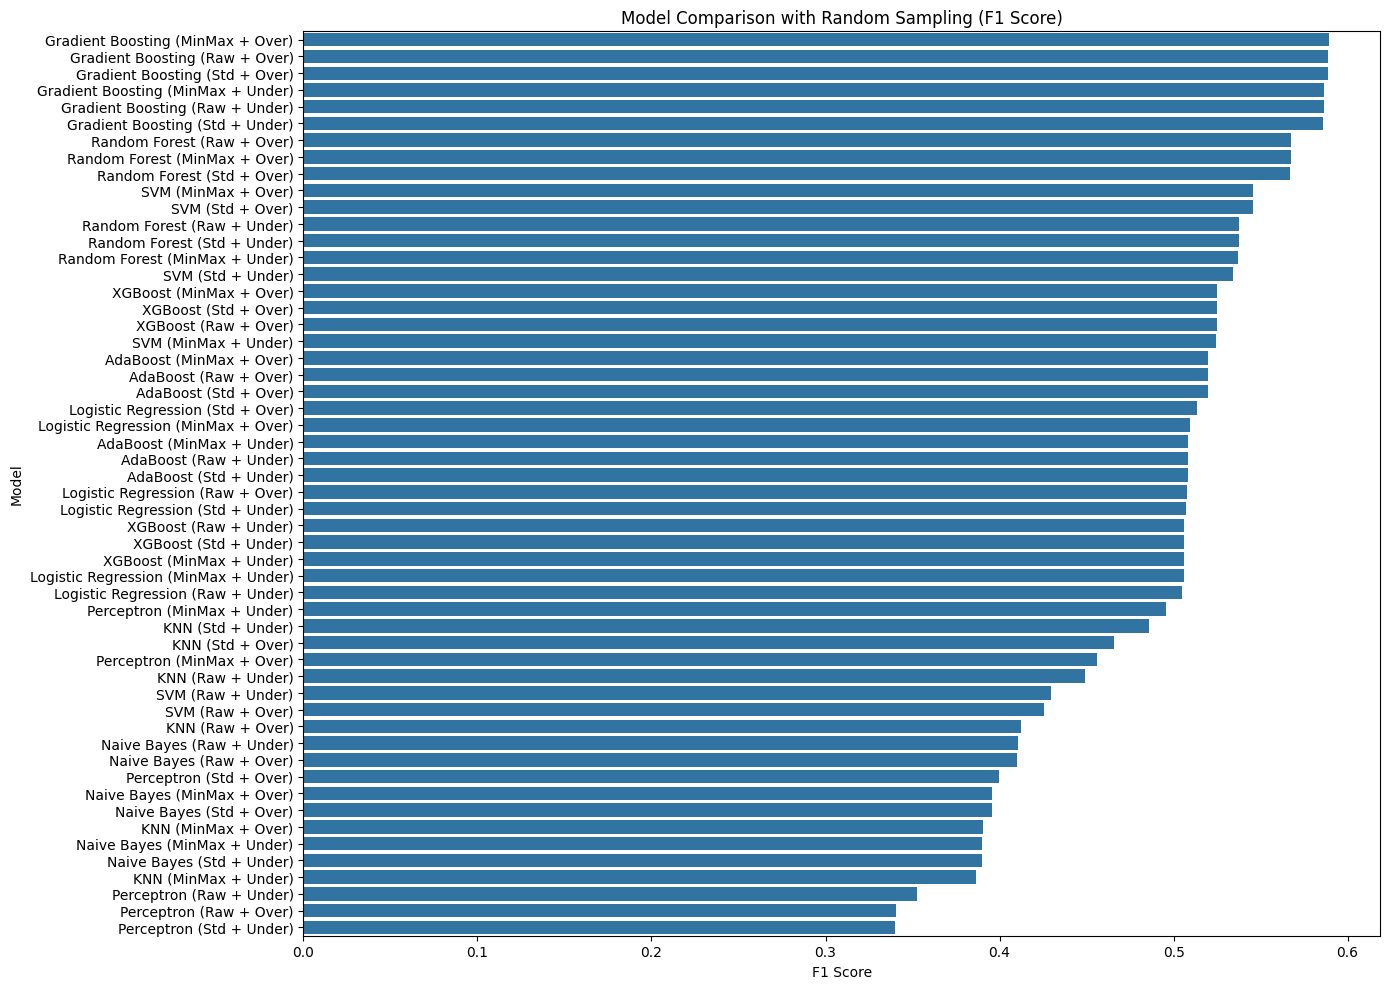


 Best configurations with Random Sampling (model + scaling):
                                 Model  Accuracy  Precision    Recall  \
16   Gradient Boosting (MinMax + Over)  0.882769   0.499343  0.718336   
12      Gradient Boosting (Raw + Over)  0.882659   0.499014  0.717391   
14      Gradient Boosting (Std + Over)  0.882659   0.499014  0.717391   
17  Gradient Boosting (MinMax + Under)  0.871489   0.470286  0.777883   
13     Gradient Boosting (Raw + Under)  0.871489   0.470286  0.777883   

    F1 Score  F1 Score Weighted       AUC    PR AUC  
16  0.589147           0.891557  0.922286  0.564525  
12  0.588600           0.891440  0.922139  0.564295  
14  0.588600           0.891440  0.922134  0.564144  
17  0.586182           0.884413  0.921936  0.552246  
13  0.586182           0.884413  0.921962  0.552072  


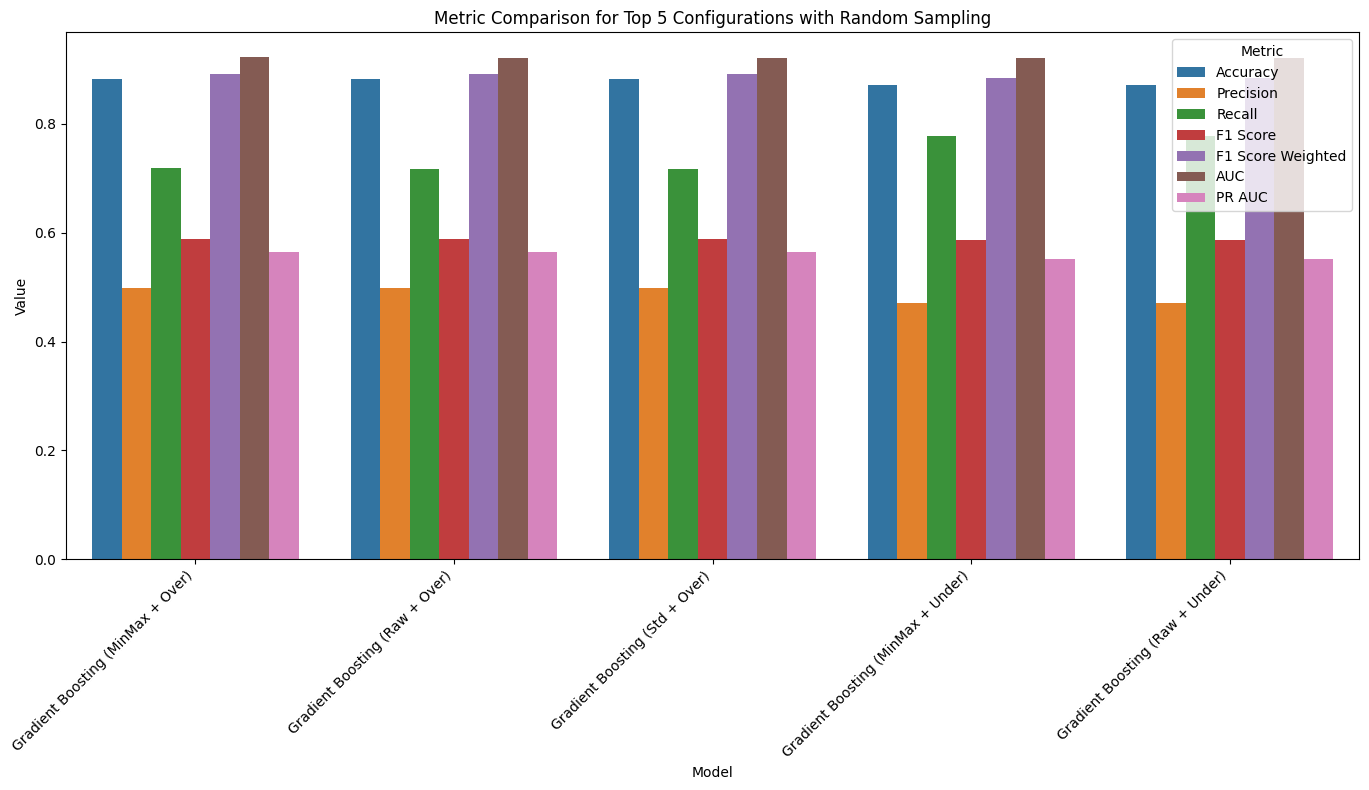

In [ ]:
# Chargement des données
X = data.drop(columns=['y'])
y = data['y']

# Répartition Train (60%) - Validation (20%) - Test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Standardisation et Normalisation
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_val_std = scaler_std.transform(X_val)
X_test_std = scaler_std.transform(X_test)

X_train_minmax = scaler_minmax.fit_transform(X_train)
X_val_minmax = scaler_minmax.transform(X_val)
X_test_minmax = scaler_minmax.transform(X_test)

# Définition des modèles de base (sans SMOTE ni scaling intégré)
base_models = [
    ('Logistic Regression', linear_model.LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')),
    ('Random Forest', ensemble.RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=15, min_samples_leaf=5, n_estimators=200)),
    ('Gradient Boosting', ensemble.GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=5)),
    ('SVM', svm.SVC(probability=True, random_state=42, class_weight='balanced')),
    ('Naive Bayes', naive_bayes.GaussianNB()),
    ('AdaBoost', ensemble.AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('KNN', neighbors.KNeighborsClassifier(n_neighbors=5)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=200, learning_rate=0.1, max_depth=6,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())),
    ('Perceptron', Perceptron(random_state=42, class_weight='balanced'))
]

#################################################################################################################################################################################
def evaluate_model_with_random_sampling(model, X_train, X_val, y_train, y_val, sampling_strategy='over'):
    """
    Trains and evaluates a model using Random Sampling (under-sampling or over-sampling).
    """
    if sampling_strategy == 'over':
        sampler = RandomOverSampler(sampling_strategy=0.5, random_state=42)
    elif sampling_strategy == 'under':
        sampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
    else:
        raise ValueError("sampling_strategy must be 'over' or 'under'.")

    X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)
    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None

    precision, recall, _ = metrics.precision_recall_curve(y_val, y_proba) if y_proba is not None else (None, None, None)
    pr_auc = metrics.auc(recall, precision) if y_proba is not None else None

    return [
        metrics.accuracy_score(y_val, y_pred),
        metrics.precision_score(y_val, y_pred, pos_label=1),
        metrics.recall_score(y_val, y_pred, pos_label=1),
        metrics.f1_score(y_val, y_pred, pos_label=1),
        metrics.f1_score(y_val, y_pred, average="weighted"),
        metrics.roc_auc_score(y_val, y_proba) if y_proba is not None else None,
        pr_auc
    ]

def evaluate_models_with_scalings_and_random_sampling(base_models, X_train, X_val, X_train_std, X_val_std, X_train_minmax, X_val_minmax, y_train, y_val):
    results = []

    for name, model in base_models:
        for data_name, X_tr, X_v in zip(
            ["Raw", "Std", "MinMax"],
            [X_train, X_train_std, X_train_minmax],
            [X_val, X_val_std, X_val_minmax]
        ):
            for strategy in ['over', 'under']:
                res = evaluate_model_with_random_sampling(model, X_tr, X_v, y_train, y_val, sampling_strategy=strategy)
                results.append([f"{name} ({data_name} + {strategy.capitalize()})"] + res)

    return pd.DataFrame(results, columns=[
        "Model", "Accuracy", "Precision", "Recall", "F1 Score", "F1 Score Weighted", "AUC", "PR AUC"
    ]).sort_values(by="F1 Score", ascending=False)

results_df_random = evaluate_models_with_scalings_and_random_sampling(base_models, X_train, X_val, X_train_std, X_val_std, X_train_minmax, X_val_minmax, y_train, y_val)
print(results_df_random)

plt.figure(figsize=(14, 10))
sns.barplot(x="F1 Score", y="Model", data=results_df_random)
plt.title("Model Comparison with Random Sampling (F1 Score)")
plt.tight_layout()
plt.show()

best_configurations_random = results_df_random.sort_values(by="F1 Score", ascending=False).head(5)
print("\n Best configurations with Random Sampling (model + scaling):")
print(best_configurations_random)

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "F1 Score Weighted", "AUC", "PR AUC"]
best_models_random_df = best_configurations_random.melt(id_vars=["Model"], value_vars=metrics_to_plot, var_name="Metric", value_name="Value")

plt.figure(figsize=(14, 8))
sns.barplot(x="Model", y="Value", hue="Metric", data=best_models_random_df)
plt.title("Metric Comparison for Top 5 Configurations with Random Sampling")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### **Analysis Results**

We trained multiple models on our dataset, and the best-performing model is **Gradient Boosting**. Below are the key metrics for this model:

- **F1-score**: **0.58**  
- **Weighted F1-score**: **0.891557**  
- **Recall**: **0.718**  
- **Precision**: **0.499343**  
- **AUC**: **0.922286**  
- **PR AUC**: **0.564525**  

This model was trained on data preprocessed with **OverSampling** and **UnderSampling**, followed by normalization and standardisation. It stands out as the best-performing model among those tested.

---


##### **Precision Affects the F1-Score**


In our case, the relatively **low precision (0.499343)** reduces the F1-score, even though the recall is high. This happens because precision penalizes false positives, and a lower precision value drags down the harmonic mean.

---

In [ ]:
!pip install optuna
import optuna

# **Hyperparameter Optimization with Optuna**

This framework automates the process of selecting the best machine learning model for binary classification tasks. It evaluates multiple algorithms, optimizes hyperparameters using Optuna, and handles imbalanced datasets through preprocessing and sampling strategies. Performance is measured using the F1 score, with detailed visualizations and reports provided for each model.

In [ ]:

X = data.drop(columns=['y'])
y = data['y']

# Split data into Train (60%), Validation (20%), and Test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Standardization and Normalization
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_val_std = scaler_std.transform(X_val)
X_test_std = scaler_std.transform(X_test)

X_train_minmax = scaler_minmax.fit_transform(X_train)
X_val_minmax = scaler_minmax.transform(X_val)
X_test_minmax = scaler_minmax.transform(X_test)


In [ ]:
base_models = [
    ('Logistic Regression', linear_model.LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')),
    ('Random Forest', ensemble.RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=15, min_samples_leaf=5, n_estimators=200)),
    ('Naive Bayes', naive_bayes.GaussianNB()),
    ('AdaBoost', ensemble.AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('KNN', neighbors.KNeighborsClassifier(n_neighbors=5)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=200, learning_rate=0.1, max_depth=6, scale_pos_weight=1)),
    ('Perceptron', Perceptron(random_state=42, class_weight='balanced'))
]

In [ ]:
from sklearn.base import clone
def plot_learning_curve_simple(model, X_train, y_train, X_test, y_test, title):

    train_sizes = np.linspace(0.1, 1.0, 10)
    train_sizes_abs = [int(train_size * len(X_train)) for train_size in train_sizes]

    train_scores = []
    test_scores = []

    for size in train_sizes_abs:
        indices = np.random.choice(len(X_train), size=size, replace=False)
        X_subset = X_train.iloc[indices] if hasattr(X_train, 'iloc') else X_train[indices]
        y_subset = y_train.iloc[indices] if hasattr(y_train, 'iloc') else y_train[indices]

        model_clone = clone(model)
        model_clone.fit(X_subset, y_subset)

        y_train_pred = model_clone.predict(X_subset)
        y_test_pred = model_clone.predict(X_test)

        train_f1 = f1_score(y_subset, y_train_pred)
        test_f1 = f1_score(y_test, y_test_pred)

        train_scores.append(train_f1)
        test_scores.append(test_f1)

    final_model = clone(model)
    final_model.fit(X_train, y_train)
    final_test_score = f1_score(y_test, final_model.predict(X_test))

    plt.figure(figsize=(12, 7))
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Nombre d'exemples d'entraînement", fontsize=12)
    plt.ylabel("Score F1", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.plot(train_sizes_abs, train_scores, 'o-', color="r",
             label="Score d'entraînement", linewidth=2, markersize=8)

    # Tracer les scores de test
    plt.plot(train_sizes_abs, test_scores, 'o-', color="b",
             label="Score de test", linewidth=2, markersize=8)

    plt.axhline(y=final_test_score, color='b', linestyle='--', linewidth=2.5,
               label=f'Score final sur test: {final_test_score:.4f}')

    plt.legend(loc="lower right", fontsize=10)

    textstr = f"Métriques du modèle:\n"
    textstr += f"- Score final sur test: {final_test_score:.4f}\n"
    textstr += f"- Score d'entraînement final: {train_scores[-1]:.4f}"

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.text(0.02, 0.03, textstr, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='bottom', bbox=props)

    plt.tight_layout()
    plt.show()

    return {
        'train_final': train_scores[-1],
        'test_final': final_test_score,
        'train_sizes': train_sizes_abs,
        'train_scores': train_scores,
        'test_scores': test_scores
    }

In [ ]:
def optimize_model(X_train, y_train, X_test, y_test, preprocessing='none', sampling_strategy='none', n_trials=20):

    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    if preprocessing == 'normalize':
        scaler = MinMaxScaler()
        X_train_processed = scaler.fit_transform(X_train)
        X_test_processed = scaler.transform(X_test)
        print(f"Data normalized with MinMaxScaler")
    elif preprocessing == 'standardize':
        scaler = StandardScaler()
        X_train_processed = scaler.fit_transform(X_train)
        X_test_processed = scaler.transform(X_test)
        print(f"Data standardized with StandardScaler")
    else:
        print(f"Original data without preprocessing")

    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    def objective(trial, model_name):
        if model_name == 'KNN':
            model = neighbors.KNeighborsClassifier(
                n_neighbors=trial.suggest_int('n_neighbors', 3, 50),
                weights=trial.suggest_categorical('weights', ['uniform', 'distance'])
            )
        elif model_name == 'Perceptron':
            model = Perceptron(
                random_state=42,
                alpha=trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
                max_iter=trial.suggest_int('max_iter', 500, 3000),
                class_weight='balanced'
            )
        elif model_name == 'SVM':
            model = svm.SVC(
                probability=True,
                random_state=42,
                C=trial.suggest_float('C', 1e-3, 10, log=True),
                kernel=trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly']),
                gamma=trial.suggest_categorical('gamma', ['scale', 'auto']),
                class_weight='balanced'
            )
        elif model_name == 'Random Forest':
            model = ensemble.RandomForestClassifier(
                random_state=42,
                n_estimators=trial.suggest_int('n_estimators', 50, 300),
                max_depth=trial.suggest_int('max_depth', 5, 30),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced'
            )
        elif model_name == 'XGBoost':
            model = XGBClassifier(
                random_state=42,
                eval_metric='logloss',
                n_estimators=trial.suggest_int('n_estimators', 50, 300),
                max_depth=trial.suggest_int('max_depth', 3, 15),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
                subsample=trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
                scale_pos_weight=pos_weight
            )
        elif model_name == 'Logistic Regression':
            model = linear_model.LogisticRegression(
                max_iter=2000,
                random_state=42,
                C=trial.suggest_float('C', 1e-5, 1e2, log=True),
                solver=trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga']),
                class_weight='balanced'
            )
        elif model_name == 'Gradient Boosting':
            model = ensemble.GradientBoostingClassifier(
                random_state=42,
                n_estimators=trial.suggest_int('n_estimators', 50, 300),
                max_depth=trial.suggest_int('max_depth', 3, 10),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
                subsample=trial.suggest_float('subsample', 0.5, 1.0)
            )
        elif model_name == 'Naive Bayes':
            model = naive_bayes.GaussianNB(
                var_smoothing=trial.suggest_float('var_smoothing', 1e-10, 1e-8, log=True)
            )
        elif model_name == 'AdaBoost':
            model = ensemble.AdaBoostClassifier(
                random_state=42,
                n_estimators=trial.suggest_int('n_estimators', 50, 200),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 1.0)
            )
        else:
            raise ValueError(f"Unknown model: {model_name}")

        X_resampled = X_train_processed
        y_resampled = y_train

        if sampling_strategy == 'over':
            sampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train_processed, y_train)
        elif sampling_strategy == 'under':
            sampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train_processed, y_train)

        model.fit(X_resampled, y_resampled)

        y_pred = model.predict(X_test_processed)
        return f1_score(y_test, y_pred, pos_label=1)

    best_models = {}
    best_params = {}
    test_scores = {}

    for model_name, _ in base_models:
        if model_name in best_models:
            continue

        print(f"Optimizing hyperparameters for {model_name} (preprocessing: {preprocessing}, sampling: {sampling_strategy})...")
        study = optuna.create_study(direction='maximize')
        study.optimize(lambda trial: objective(trial, model_name), n_trials=n_trials)

        best_params[model_name] = study.best_params
        test_scores[model_name] = study.best_value

        print(f"Best hyperparameters for {model_name}: {best_params[model_name]}")
        print(f"Best F1-score on test data: {test_scores[model_name]:.4f}")

        params = best_params[model_name]
        if model_name == 'KNN':
            model = neighbors.KNeighborsClassifier(
                n_neighbors=params['n_neighbors'],
                weights=params.get('weights', 'uniform')
            )
        elif model_name == 'Perceptron':
            model = Perceptron(
                random_state=42,
                alpha=params['alpha'],
                max_iter=params['max_iter'],
                class_weight='balanced'
            )
        elif model_name == 'SVM':
            model = svm.SVC(
                probability=True,
                random_state=42,
                C=params['C'],
                kernel=params['kernel'],
                gamma=params['gamma'],
                class_weight='balanced'
            )
        elif model_name == 'Random Forest':
            model = ensemble.RandomForestClassifier(
                random_state=42,
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                min_samples_leaf=params['min_samples_leaf'],
                class_weight='balanced'
            )
        elif model_name == 'XGBoost':
            model = XGBClassifier(
                random_state=42,
                eval_metric='logloss',
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                learning_rate=params['learning_rate'],
                subsample=params.get('subsample', 0.8),
                colsample_bytree=params.get('colsample_bytree', 0.8),
                scale_pos_weight=pos_weight
            )
        elif model_name == 'Logistic Regression':
            model = linear_model.LogisticRegression(
                max_iter=2000,
                random_state=42,
                C=params['C'],
                solver=params['solver'],
                class_weight='balanced'
            )
        elif model_name == 'Gradient Boosting':
            model = ensemble.GradientBoostingClassifier(
                random_state=42,
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                learning_rate=params['learning_rate'],
                subsample=params.get('subsample', 0.8)
            )
        elif model_name == 'Naive Bayes':
            model = naive_bayes.GaussianNB(
                var_smoothing=params.get('var_smoothing', 1e-9)
            )
        elif model_name == 'AdaBoost':
            model = ensemble.AdaBoostClassifier(
                random_state=42,
                n_estimators=params['n_estimators'],
                learning_rate=params['learning_rate']
            )

        X_resampled = X_train_processed
        y_resampled = y_train

        if sampling_strategy == 'over':
            sampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train_processed, y_train)
        elif sampling_strategy == 'under':
            sampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
            X_resampled, y_resampled = sampler.fit_resample(X_train_processed, y_train)

        model.fit(X_resampled, y_resampled)
        best_models[model_name] = model

        title = f"Learning Curve - {model_name} (F1 Score)\n(preprocessing: {preprocessing}, sampling: {sampling_strategy})"
        title = f"Learning Curve - {model_name} (F1 Score)\n(preprocessing: {preprocessing}, sampling: {sampling_strategy})"
        plot_learning_curve_simple(
            model=model,
            X_train=X_resampled,
            y_train=y_resampled,
            X_test=X_test_processed,
            y_test=y_test,
            title=title
        )
        y_pred = model.predict(X_test_processed)
        print(f"\nClassification report for {model_name}:")
        print(classification_report(y_test, y_pred))

    best_model_name = max(test_scores, key=test_scores.get)
    print(f"\n Best model for {preprocessing}/{sampling_strategy}: {best_model_name} with F1 score of {test_scores[best_model_name]:.4f}")

    plot_model_comparison(best_models, X_test_processed, y_test, preprocessing, sampling_strategy)

    return best_models, best_params, test_scores


In [ ]:
def find_best_model_overall(X_train, y_train, X_test, y_test, n_trials=20):
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)


    preprocessing_strategies = ['normalize', 'standardize']
    sampling_strategies = ['over', 'under']

    all_results = {}

    for preprocessing in preprocessing_strategies:
        for sampling in sampling_strategies:
            print(f"\n{'='*80}\nRunning with preprocessing: {preprocessing}, sampling: {sampling}\n{'='*80}")

            best_models, best_params, test_scores = optimize_model(
                X_train, y_train, X_test, y_test,
                preprocessing=preprocessing,
                sampling_strategy=sampling,
                n_trials=n_trials
            )

            best_model_name = max(test_scores, key=test_scores.get)
            best_score = test_scores[best_model_name]

            config_key = f"{preprocessing}_{sampling}"
            all_results[config_key] = {
                'model_name': best_model_name,
                'model': best_models[best_model_name],
                'params': best_params[best_model_name],
                'score': best_score
            }

    best_config = max(all_results, key=lambda k: all_results[k]['score'])
    overall_best_model = all_results[best_config]['model']
    overall_best_model_name = all_results[best_config]['model_name']
    overall_best_params = all_results[best_config]['params']
    overall_best_score = all_results[best_config]['score']
    preprocessing_used, sampling_used = best_config.split('_')

    print(f"\n{'='*80}")
    print(f" BEST OVERALL MODEL ")
    print(f"{'='*80}")
    print(f"Model: {overall_best_model_name}")
    print(f"Preprocessing: {preprocessing_used}")
    print(f"Sampling strategy: {sampling_used}")
    print(f"F1 Score: {overall_best_score:.4f}")
    print(f"Hyperparameters: {overall_best_params}")
    print(f"{'='*80}")

    return overall_best_model, overall_best_params, overall_best_score



In [ ]:
def plot_model_comparison(best_models, X_test, y_test, preprocessing, sampling):

    model_names = list(best_models.keys())
    f1_scores = []
    f1_scores_weighted = []

    for name, model in best_models.items():
        y_pred = model.predict(X_test)
        score = f1_score(y_test, y_pred, pos_label=1)
        score_weighted = f1_score(y_test, y_pred, average="weighted")
        f1_scores.append(score)
        f1_scores_weighted.append(score_weighted)
        print(f'Model: {name}\nF1 Score (Binary): {score:.4f}\nF1 Score (Weighted): {score_weighted:.4f}\n')


    plt.figure(figsize=(14, 7))
    bars = plt.bar(model_names, f1_scores, color='skyblue', label='F1 Score (Binary)')
    bars_weighted = plt.bar(model_names, f1_scores_weighted, color='orange', alpha=0.7, label='F1 Score (Weighted)')


    for bar, score, score_weighted in zip(bars, f1_scores, f1_scores_weighted):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.4f}', ha='center', va='bottom')

    for bar, score_weighted in zip(bars_weighted, f1_scores_weighted):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score_weighted:.4f}', ha='center', va='bottom', color='black')

    plt.ylim(0, max(max(f1_scores), max(f1_scores_weighted)) + 0.1)  # Adjust y scale
    plt.xlabel('Models')
    plt.ylabel('F1 Score')
    plt.title(f'Model Comparison (Preprocessing: {preprocessing}, Sampling: {sampling})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()


[I 2025-03-07 21:59:40,343] A new study created in memory with name: no-name-8e5390f3-065b-4090-943d-209b0858b39e



Running with preprocessing: normalize, sampling: over
Data normalized with MinMaxScaler
Optimizing hyperparameters for Logistic Regression (preprocessing: normalize, sampling: over)...


[I 2025-03-07 21:59:42,220] Trial 0 finished with value: 0.5132192846034215 and parameters: {'C': 1.2974115636576977, 'solver': 'liblinear'}. Best is trial 0 with value: 0.5132192846034215.
[I 2025-03-07 21:59:42,843] Trial 1 finished with value: 0.47668393782383417 and parameters: {'C': 0.022973333384082584, 'solver': 'liblinear'}. Best is trial 0 with value: 0.5132192846034215.
[I 2025-03-07 21:59:44,728] Trial 2 finished with value: 0.5144634525660964 and parameters: {'C': 1.7695326026024847, 'solver': 'liblinear'}. Best is trial 2 with value: 0.5144634525660964.
[I 2025-03-07 21:59:46,986] Trial 3 finished with value: 0.5163297045101088 and parameters: {'C': 84.66818255056081, 'solver': 'liblinear'}. Best is trial 3 with value: 0.5163297045101088.
[I 2025-03-07 21:59:49,457] Trial 4 finished with value: 0.28753861997940267 and parameters: {'C': 0.00012764860061574904, 'solver': 'saga'}. Best is trial 3 with value: 0.5163297045101088.
[I 2025-03-07 21:59:49,780] Trial 5 finished wit

Best hyperparameters for Logistic Regression: {'C': 50.18957877055428, 'solver': 'lbfgs'}
Best F1-score on test data: 0.5171


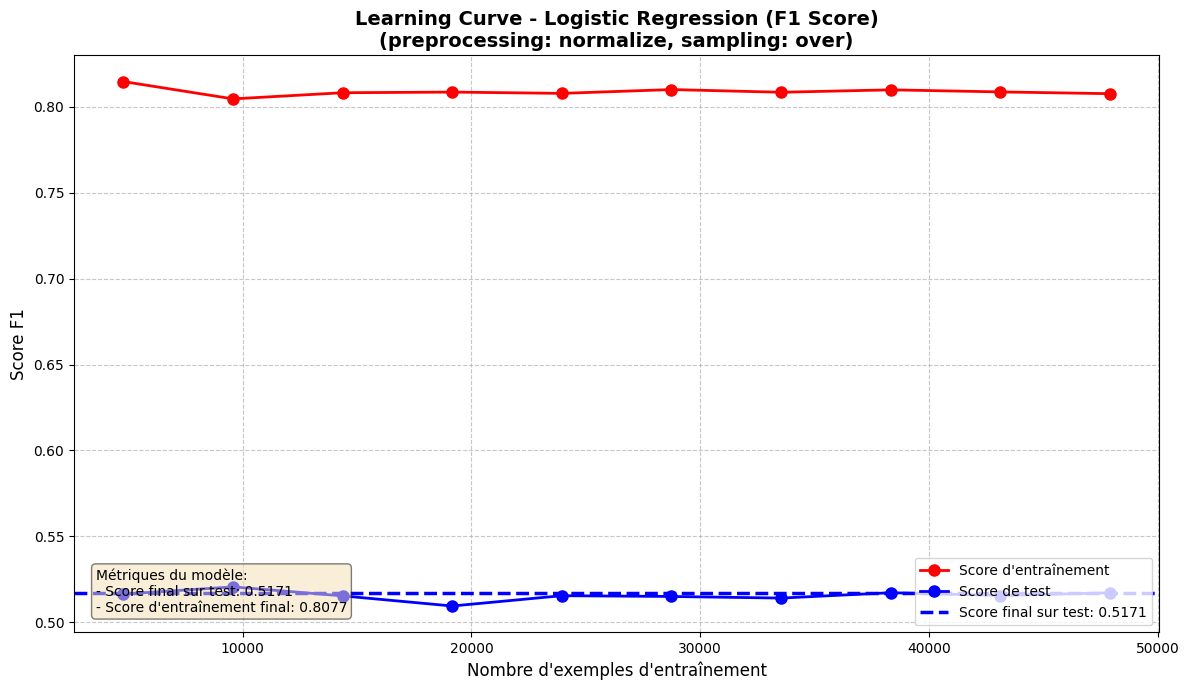

[I 2025-03-07 22:00:28,490] A new study created in memory with name: no-name-cfaec212-708c-4cbe-a370-99dd74cabf6a



Classification report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      7985
           1       0.39      0.79      0.52      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.81      0.71      9043
weighted avg       0.90      0.83      0.85      9043

Optimizing hyperparameters for Random Forest (preprocessing: normalize, sampling: over)...


[I 2025-03-07 22:00:31,208] Trial 0 finished with value: 0.5574481263549086 and parameters: {'n_estimators': 59, 'max_depth': 12, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.5574481263549086.
[I 2025-03-07 22:00:34,377] Trial 1 finished with value: 0.5884389061959155 and parameters: {'n_estimators': 60, 'max_depth': 19, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.5884389061959155.
[I 2025-03-07 22:00:40,975] Trial 2 finished with value: 0.5977912361952262 and parameters: {'n_estimators': 108, 'max_depth': 18, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.5977912361952262.
[I 2025-03-07 22:00:43,788] Trial 3 finished with value: 0.5744888023369036 and parameters: {'n_estimators': 55, 'max_depth': 18, 'min_samples_leaf': 10}. Best is trial 2 with value: 0.5977912361952262.
[I 2025-03-07 22:00:59,671] Trial 4 finished with value: 0.5871304347826087 and parameters: {'n_estimators': 296, 'max_depth': 16, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.59779

Best hyperparameters for Random Forest: {'n_estimators': 120, 'max_depth': 23, 'min_samples_leaf': 4}
Best F1-score on test data: 0.6045


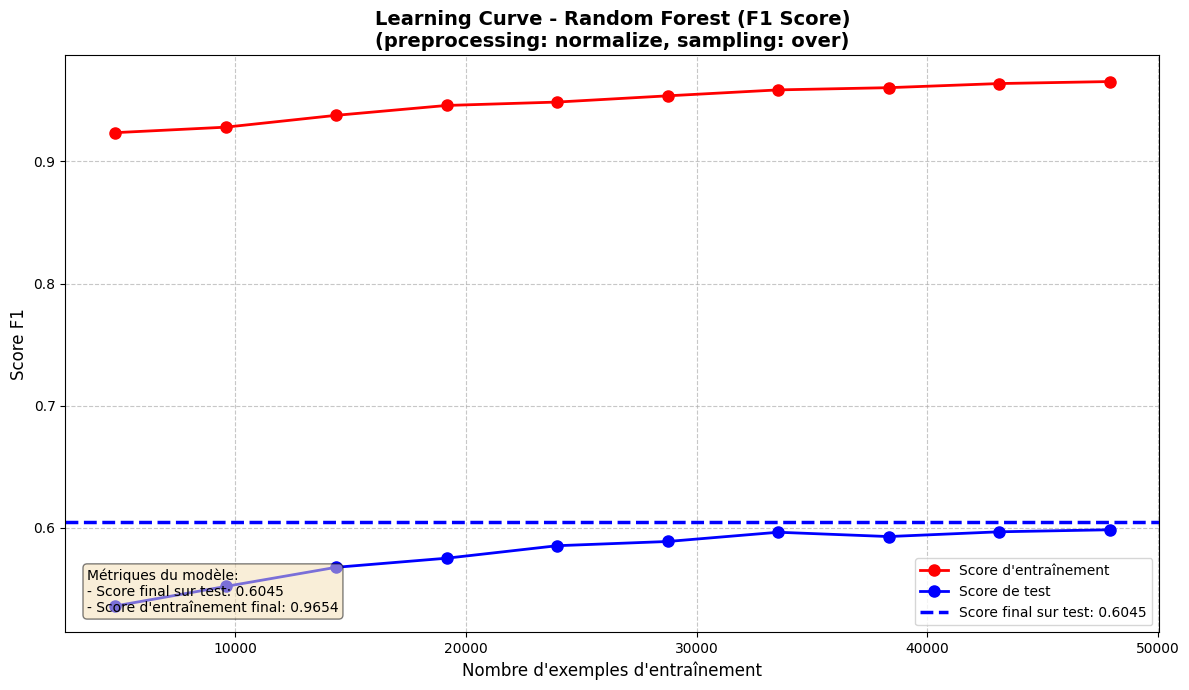

[I 2025-03-07 22:04:10,417] A new study created in memory with name: no-name-814bfc13-ebc2-42a4-b306-61b08155ace8
[I 2025-03-07 22:04:10,499] Trial 0 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 4.962688714562971e-10}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:04:10,575] Trial 1 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 1.1277605791654227e-10}. Best is trial 0 with value: 0.4140495867768595.



Classification report for Random Forest:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      7985
           1       0.50      0.76      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.83      0.77      9043
weighted avg       0.91      0.88      0.89      9043

Optimizing hyperparameters for Naive Bayes (preprocessing: normalize, sampling: over)...


[I 2025-03-07 22:04:10,659] Trial 2 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 7.602106111613425e-10}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:04:10,736] Trial 3 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 5.063173581476386e-09}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:04:10,816] Trial 4 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 3.235541163513927e-10}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:04:10,900] Trial 5 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 7.311064263043246e-10}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:04:10,977] Trial 6 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 1.2647352550885451e-09}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:04:11,051] Trial 7 finished with value: 0.4140495867768595 and parameter

Best hyperparameters for Naive Bayes: {'var_smoothing': 4.962688714562971e-10}
Best F1-score on test data: 0.4140


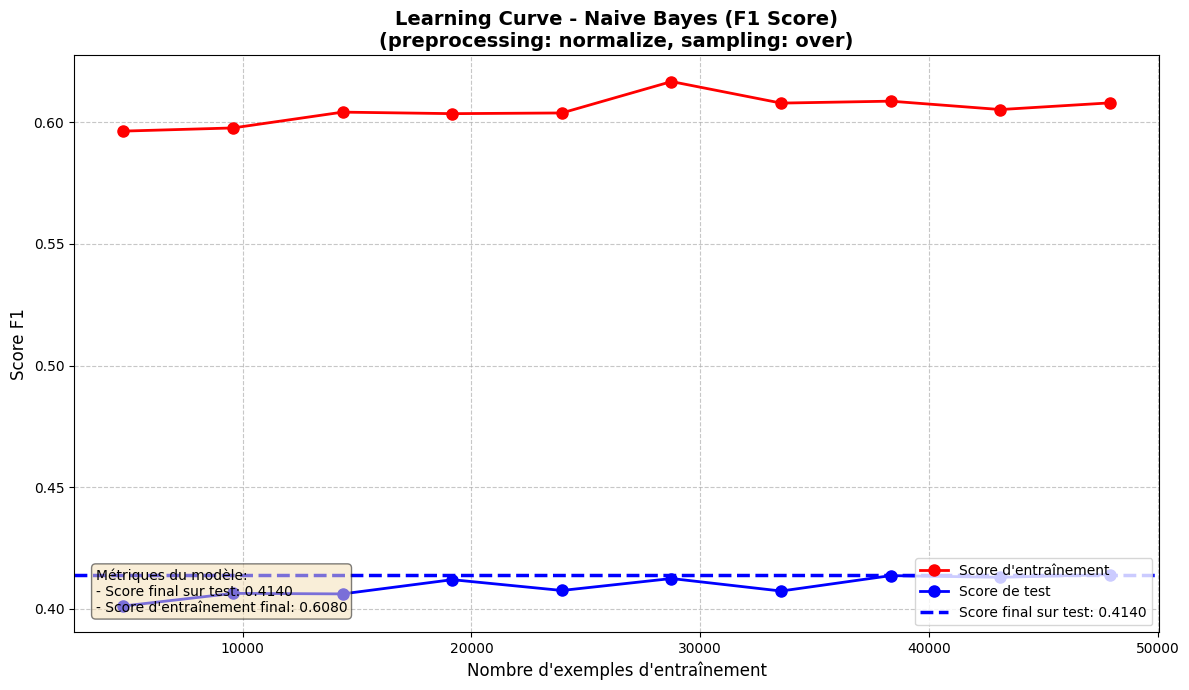

[I 2025-03-07 22:04:13,102] A new study created in memory with name: no-name-2643f8fc-a237-487e-9235-0518bdba37c6



Classification report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      7985
           1       0.37      0.47      0.41      1058

    accuracy                           0.84      9043
   macro avg       0.65      0.68      0.66      9043
weighted avg       0.86      0.84      0.85      9043

Optimizing hyperparameters for AdaBoost (preprocessing: normalize, sampling: over)...


[I 2025-03-07 22:04:15,905] Trial 0 finished with value: 0.48169668797210924 and parameters: {'n_estimators': 53, 'learning_rate': 0.5742923008595853}. Best is trial 0 with value: 0.48169668797210924.
[I 2025-03-07 22:04:26,601] Trial 1 finished with value: 0.5024716487350974 and parameters: {'n_estimators': 174, 'learning_rate': 0.38457211094756444}. Best is trial 1 with value: 0.5024716487350974.
[I 2025-03-07 22:04:37,495] Trial 2 finished with value: 0.5068007096392667 and parameters: {'n_estimators': 159, 'learning_rate': 0.8929169711870076}. Best is trial 2 with value: 0.5068007096392667.
[I 2025-03-07 22:04:43,063] Trial 3 finished with value: 0.4700902934537246 and parameters: {'n_estimators': 93, 'learning_rate': 0.14693112773763733}. Best is trial 2 with value: 0.5068007096392667.
[I 2025-03-07 22:04:53,867] Trial 4 finished with value: 0.4724498445888669 and parameters: {'n_estimators': 164, 'learning_rate': 0.10760532681836989}. Best is trial 2 with value: 0.506800709639266

Best hyperparameters for AdaBoost: {'n_estimators': 93, 'learning_rate': 0.9692181404272924}
Best F1-score on test data: 0.5108


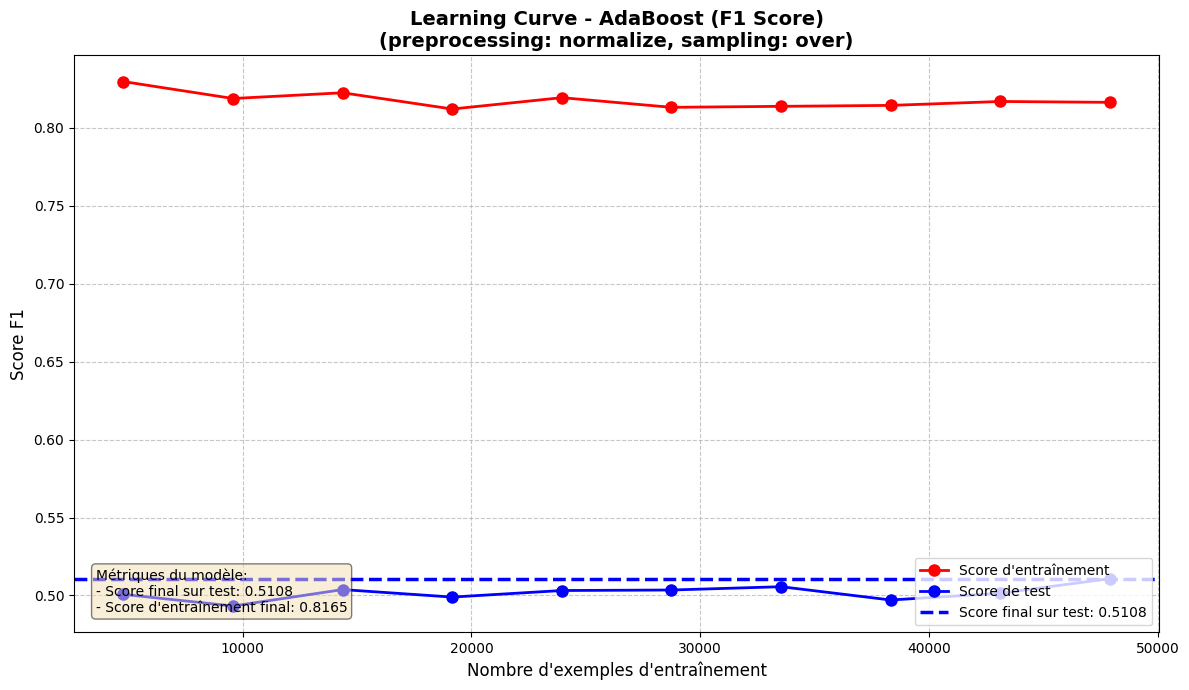

[I 2025-03-07 22:07:50,408] A new study created in memory with name: no-name-db848b11-a05d-4da4-ab30-4ec8c0c51d24



Classification report for AdaBoost:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      7985
           1       0.37      0.81      0.51      1058

    accuracy                           0.82      9043
   macro avg       0.67      0.82      0.70      9043
weighted avg       0.90      0.82      0.84      9043

Optimizing hyperparameters for KNN (preprocessing: normalize, sampling: over)...


[I 2025-03-07 22:07:53,879] Trial 0 finished with value: 0.3941378235110695 and parameters: {'n_neighbors': 41, 'weights': 'distance'}. Best is trial 0 with value: 0.3941378235110695.
[I 2025-03-07 22:07:58,233] Trial 1 finished with value: 0.3748894783377542 and parameters: {'n_neighbors': 48, 'weights': 'uniform'}. Best is trial 0 with value: 0.3941378235110695.
[I 2025-03-07 22:08:02,341] Trial 2 finished with value: 0.396875 and parameters: {'n_neighbors': 34, 'weights': 'distance'}. Best is trial 2 with value: 0.396875.
[I 2025-03-07 22:08:05,696] Trial 3 finished with value: 0.3992502343017807 and parameters: {'n_neighbors': 24, 'weights': 'distance'}. Best is trial 3 with value: 0.3992502343017807.
[I 2025-03-07 22:08:09,014] Trial 4 finished with value: 0.37747920665387075 and parameters: {'n_neighbors': 9, 'weights': 'distance'}. Best is trial 3 with value: 0.3992502343017807.
[I 2025-03-07 22:08:14,011] Trial 5 finished with value: 0.38707037643207853 and parameters: {'n_neig

Best hyperparameters for KNN: {'n_neighbors': 25, 'weights': 'distance'}
Best F1-score on test data: 0.4006


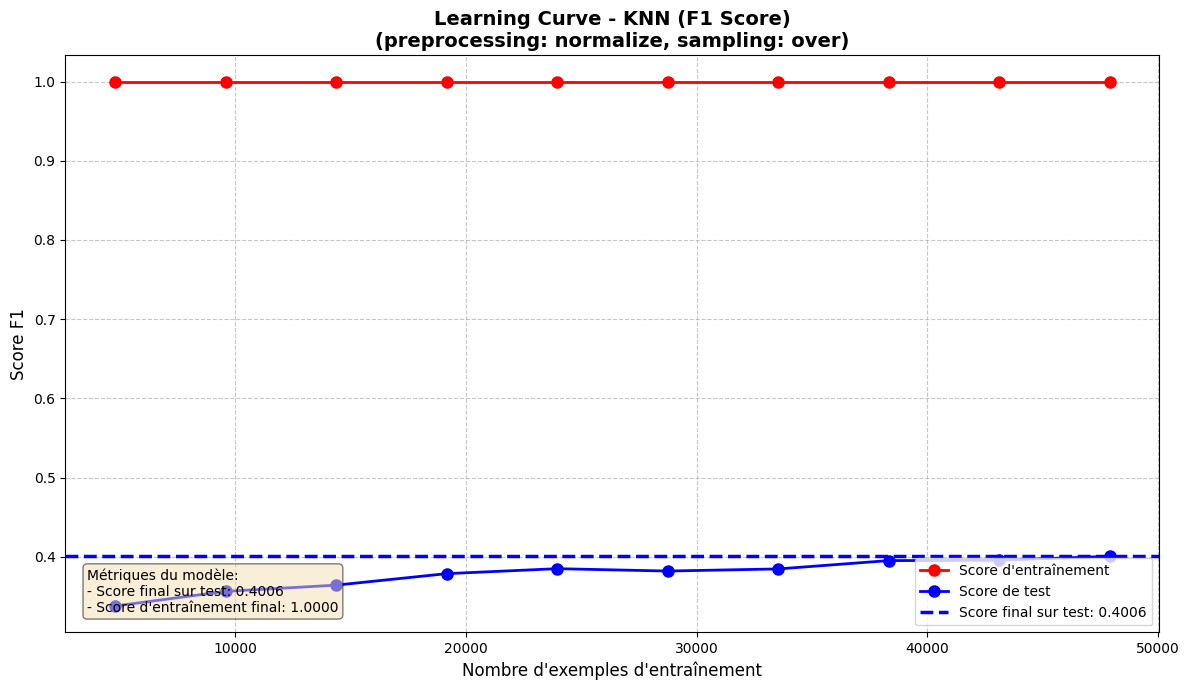

[I 2025-03-07 22:10:51,940] A new study created in memory with name: no-name-d9326977-1ff3-4aa3-9ea0-6cdea840902e



Classification report for KNN:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      7985
           1       0.30      0.61      0.40      1058

    accuracy                           0.79      9043
   macro avg       0.62      0.71      0.64      9043
weighted avg       0.86      0.79      0.82      9043

Optimizing hyperparameters for XGBoost (preprocessing: normalize, sampling: over)...


[I 2025-03-07 22:10:54,905] Trial 0 finished with value: 0.5833625833625834 and parameters: {'n_estimators': 72, 'max_depth': 12, 'learning_rate': 0.1396348889551471, 'subsample': 0.9284894412705651, 'colsample_bytree': 0.8028371039853381}. Best is trial 0 with value: 0.5833625833625834.
[I 2025-03-07 22:10:56,443] Trial 1 finished with value: 0.5285472018089316 and parameters: {'n_estimators': 267, 'max_depth': 5, 'learning_rate': 0.1944100913700866, 'subsample': 0.7569826958311161, 'colsample_bytree': 0.904883379957366}. Best is trial 0 with value: 0.5833625833625834.
[I 2025-03-07 22:10:59,829] Trial 2 finished with value: 0.5748344370860927 and parameters: {'n_estimators': 231, 'max_depth': 14, 'learning_rate': 0.2615338179586282, 'subsample': 0.9018374882109162, 'colsample_bytree': 0.7701013184700205}. Best is trial 0 with value: 0.5833625833625834.
[I 2025-03-07 22:11:00,607] Trial 3 finished with value: 0.4435201401050788 and parameters: {'n_estimators': 124, 'max_depth': 4, 'le

Best hyperparameters for XGBoost: {'n_estimators': 139, 'max_depth': 14, 'learning_rate': 0.06481641143648546, 'subsample': 0.5096760460273781, 'colsample_bytree': 0.6732480499424125}
Best F1-score on test data: 0.5998


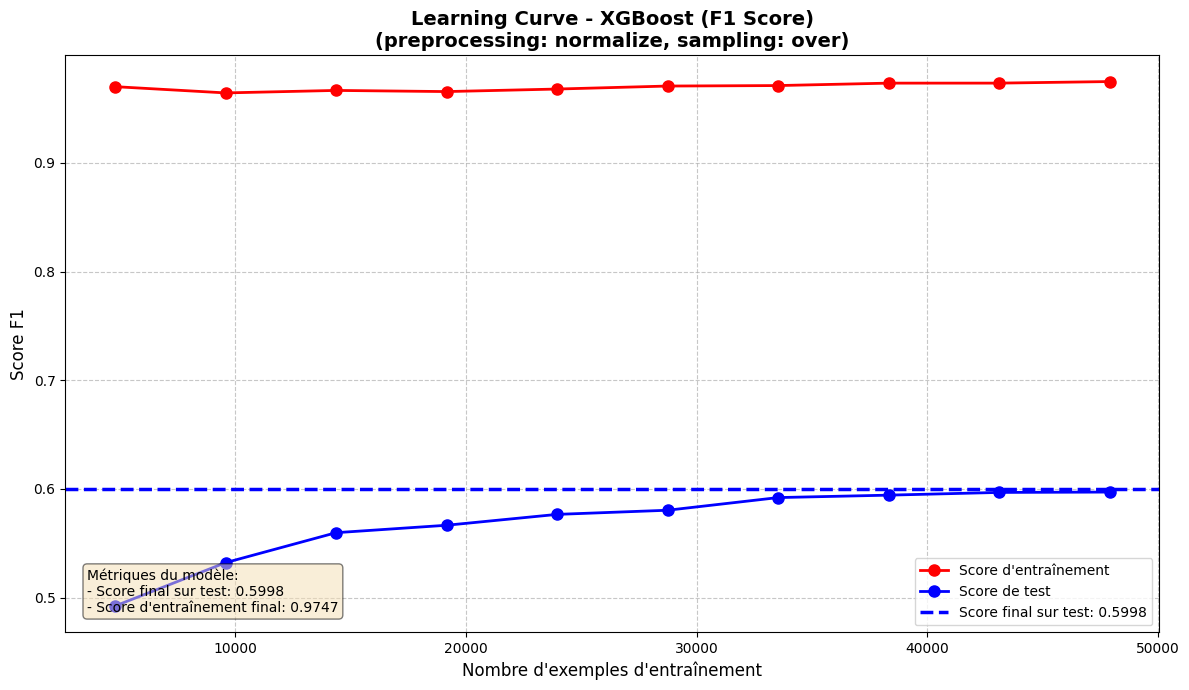

[I 2025-03-07 22:12:26,509] A new study created in memory with name: no-name-a086fa31-be72-4970-831d-e6087b4ca670



Classification report for XGBoost:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      7985
           1       0.48      0.80      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.84      0.76      9043
weighted avg       0.91      0.88      0.89      9043

Optimizing hyperparameters for Perceptron (preprocessing: normalize, sampling: over)...


[I 2025-03-07 22:12:26,729] Trial 0 finished with value: 0.43672939649578196 and parameters: {'alpha': 0.0003910594174234397, 'max_iter': 1656}. Best is trial 0 with value: 0.43672939649578196.
[I 2025-03-07 22:12:26,973] Trial 1 finished with value: 0.43672939649578196 and parameters: {'alpha': 8.887684161616136e-05, 'max_iter': 1858}. Best is trial 0 with value: 0.43672939649578196.
[I 2025-03-07 22:12:27,225] Trial 2 finished with value: 0.43672939649578196 and parameters: {'alpha': 0.002136623876779511, 'max_iter': 974}. Best is trial 0 with value: 0.43672939649578196.
[I 2025-03-07 22:12:27,456] Trial 3 finished with value: 0.43672939649578196 and parameters: {'alpha': 1.4415111901187327e-05, 'max_iter': 2354}. Best is trial 0 with value: 0.43672939649578196.
[I 2025-03-07 22:12:27,648] Trial 4 finished with value: 0.43672939649578196 and parameters: {'alpha': 0.0010238604925216395, 'max_iter': 1714}. Best is trial 0 with value: 0.43672939649578196.
[I 2025-03-07 22:12:27,825] Tri

Best hyperparameters for Perceptron: {'alpha': 0.0003910594174234397, 'max_iter': 1656}
Best F1-score on test data: 0.4367


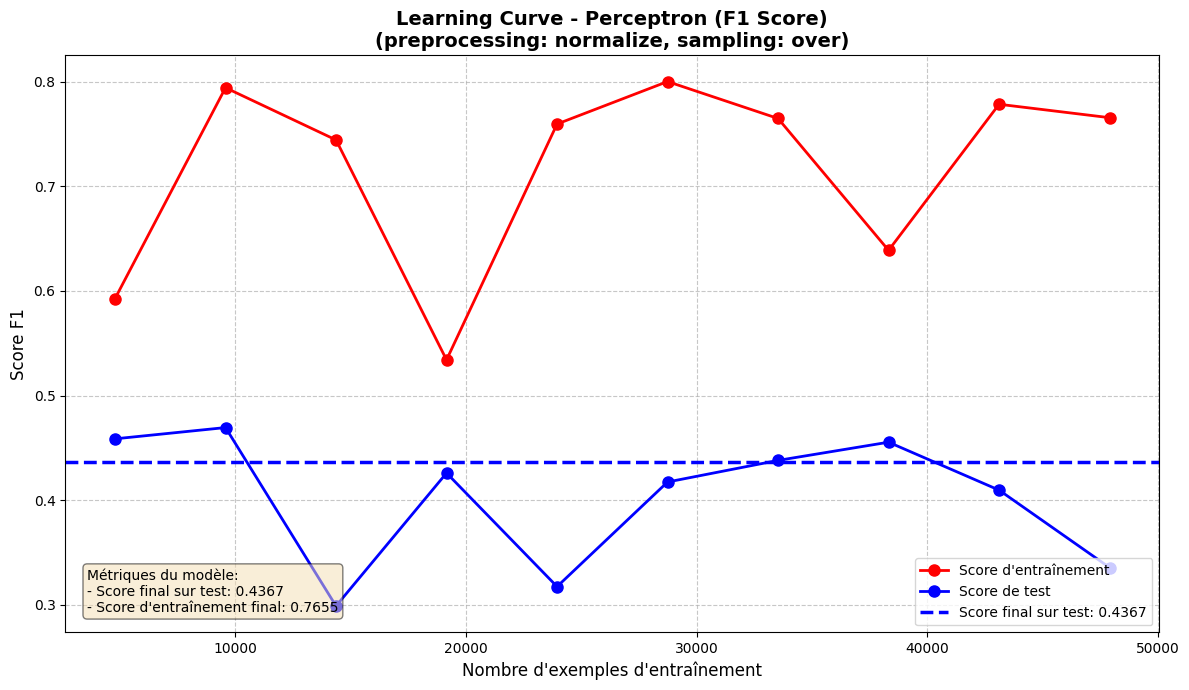


Classification report for Perceptron:
              precision    recall  f1-score   support

           0       0.95      0.83      0.88      7985
           1       0.33      0.64      0.44      1058

    accuracy                           0.81      9043
   macro avg       0.64      0.73      0.66      9043
weighted avg       0.87      0.81      0.83      9043


 Best model for normalize/over: Random Forest with F1 score of 0.6045
Model: Logistic Regression
F1 Score (Binary): 0.5171
F1 Score (Weighted): 0.8514

Model: Random Forest
F1 Score (Binary): 0.6045
F1 Score (Weighted): 0.8932

Model: Naive Bayes
F1 Score (Binary): 0.4140
F1 Score (Weighted): 0.8515

Model: AdaBoost
F1 Score (Binary): 0.5108
F1 Score (Weighted): 0.8440

Model: KNN
F1 Score (Binary): 0.4006
F1 Score (Weighted): 0.8159

Model: XGBoost
F1 Score (Binary): 0.5998
F1 Score (Weighted): 0.8881

Model: Perceptron
F1 Score (Binary): 0.4367
F1 Score (Weighted): 0.8319



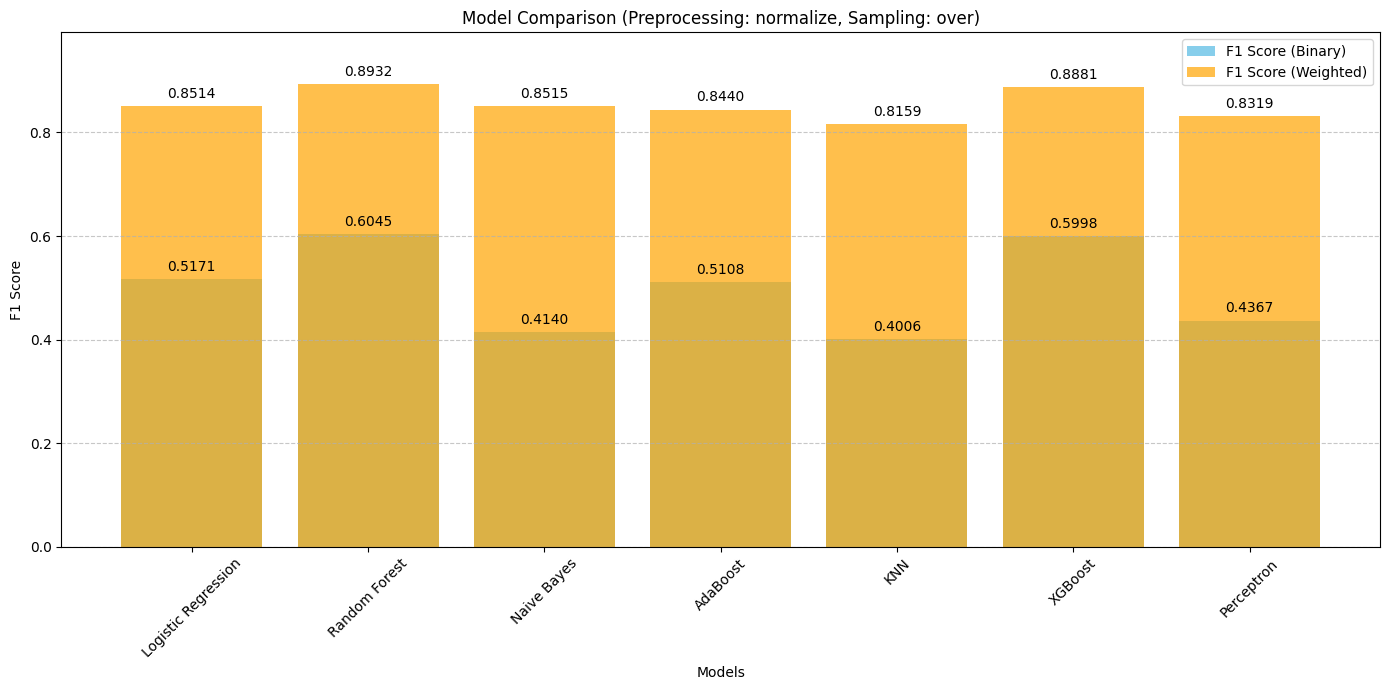

[I 2025-03-07 22:12:38,642] A new study created in memory with name: no-name-a763485d-a36e-40c8-83b2-e8a1e026677f
[I 2025-03-07 22:12:38,686] Trial 0 finished with value: 0.4204640760413755 and parameters: {'C': 0.05441421417584547, 'solver': 'liblinear'}. Best is trial 0 with value: 0.4204640760413755.
[I 2025-03-07 22:12:38,793] Trial 1 finished with value: 0.5155472636815921 and parameters: {'C': 7.954384096475094, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.5155472636815921.



Running with preprocessing: normalize, sampling: under
Data normalized with MinMaxScaler
Optimizing hyperparameters for Logistic Regression (preprocessing: normalize, sampling: under)...


[I 2025-03-07 22:12:39,211] Trial 2 finished with value: 0.5139454716389846 and parameters: {'C': 3.021902127339169, 'solver': 'saga'}. Best is trial 1 with value: 0.5155472636815921.
[I 2025-03-07 22:12:39,382] Trial 3 finished with value: 0.28654605947182366 and parameters: {'C': 0.0007756531539889146, 'solver': 'saga'}. Best is trial 1 with value: 0.5155472636815921.
[I 2025-03-07 22:12:39,468] Trial 4 finished with value: 0.5166718603926457 and parameters: {'C': 23.676006580131748, 'solver': 'liblinear'}. Best is trial 4 with value: 0.5166718603926457.
[I 2025-03-07 22:12:39,670] Trial 5 finished with value: 0.5156054931335831 and parameters: {'C': 38.54155257582523, 'solver': 'lbfgs'}. Best is trial 4 with value: 0.5166718603926457.
[I 2025-03-07 22:12:39,735] Trial 6 finished with value: 0.3547430830039526 and parameters: {'C': 0.016599693975806656, 'solver': 'lbfgs'}. Best is trial 4 with value: 0.5166718603926457.
[I 2025-03-07 22:12:39,795] Trial 7 finished with value: 0.29535

Best hyperparameters for Logistic Regression: {'C': 97.86600936918651, 'solver': 'liblinear'}
Best F1-score on test data: 0.5173


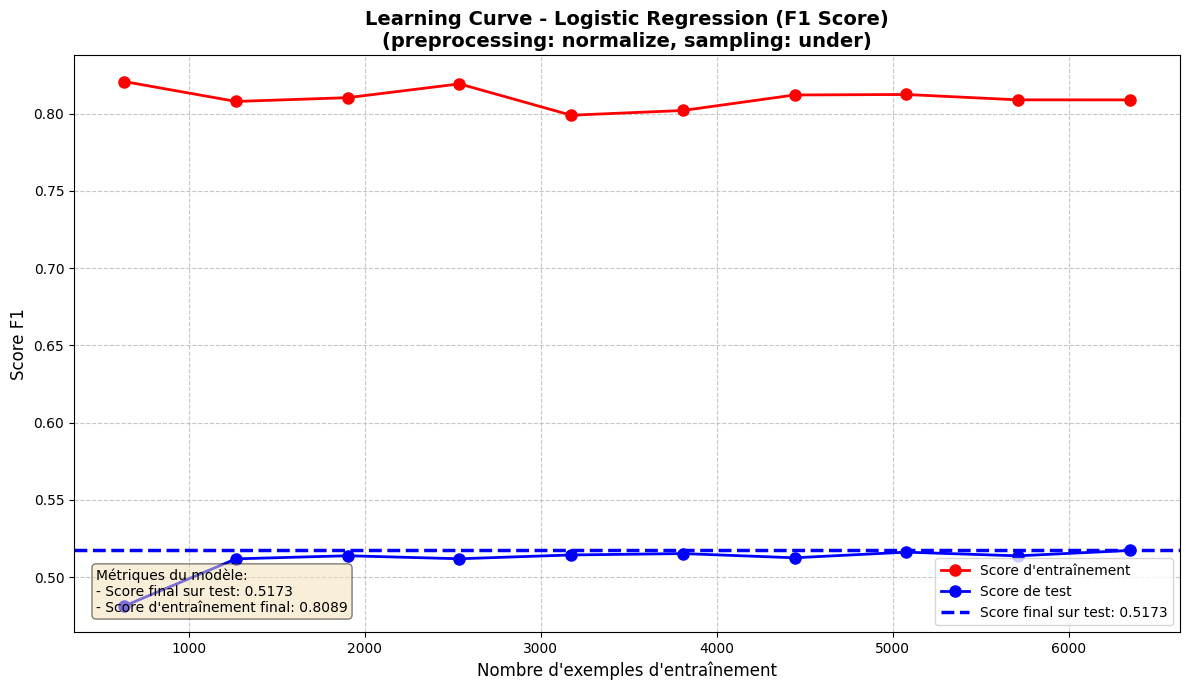

[I 2025-03-07 22:12:43,858] A new study created in memory with name: no-name-6255feed-935f-4efe-8e2f-7e6aea21b904



Classification report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      7985
           1       0.39      0.78      0.52      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.81      0.71      9043
weighted avg       0.90      0.83      0.85      9043

Optimizing hyperparameters for Random Forest (preprocessing: normalize, sampling: under)...


[I 2025-03-07 22:12:45,365] Trial 0 finished with value: 0.5361775727875469 and parameters: {'n_estimators': 176, 'max_depth': 12, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.5361775727875469.
[I 2025-03-07 22:12:47,960] Trial 1 finished with value: 0.546037296037296 and parameters: {'n_estimators': 224, 'max_depth': 23, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.546037296037296.
[I 2025-03-07 22:12:50,959] Trial 2 finished with value: 0.5284621920135939 and parameters: {'n_estimators': 252, 'max_depth': 18, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.546037296037296.
[I 2025-03-07 22:12:51,948] Trial 3 finished with value: 0.5089903181189488 and parameters: {'n_estimators': 187, 'max_depth': 6, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.546037296037296.
[I 2025-03-07 22:12:52,976] Trial 4 finished with value: 0.5219842164599775 and parameters: {'n_estimators': 133, 'max_depth': 13, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.54603729

Best hyperparameters for Random Forest: {'n_estimators': 224, 'max_depth': 23, 'min_samples_leaf': 1}
Best F1-score on test data: 0.5460


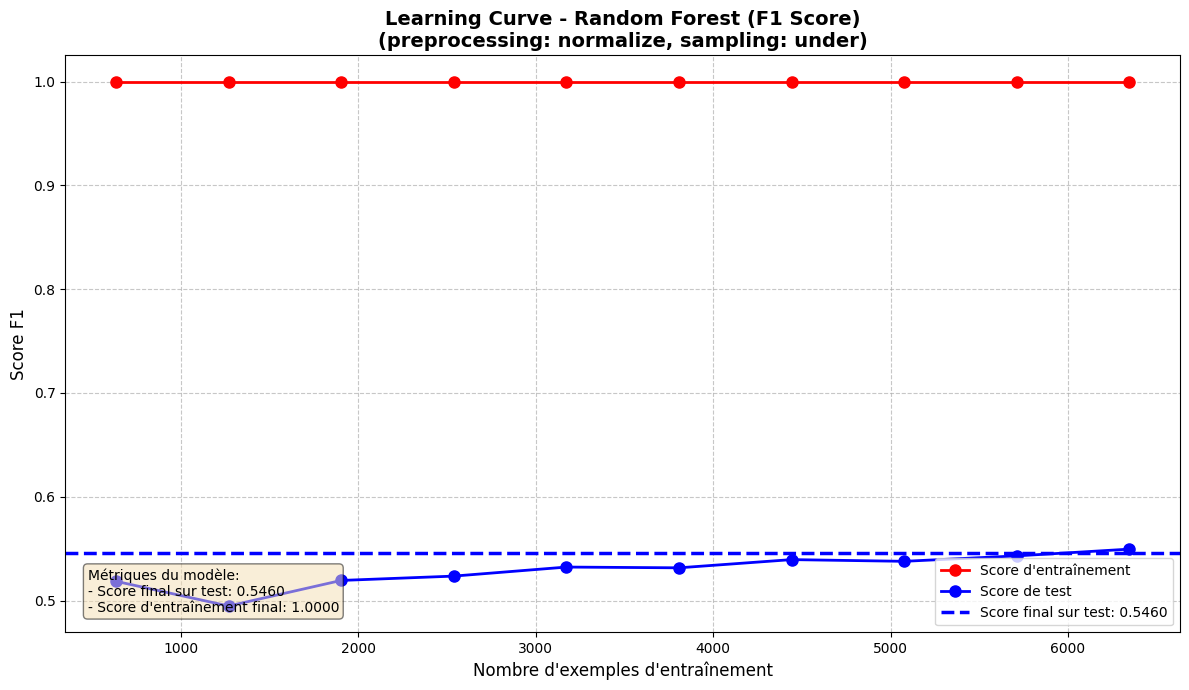

[I 2025-03-07 22:13:51,369] A new study created in memory with name: no-name-7426bc86-4aea-46cc-9e37-e9d0700e4d85
[I 2025-03-07 22:13:51,401] Trial 0 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 1.8623959220621444e-09}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:13:51,433] Trial 1 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 1.2338040727728612e-10}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:13:51,476] Trial 2 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 1.6219942287458086e-10}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:13:51,511] Trial 3 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 4.697609021695973e-10}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:13:51,541] Trial 4 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 8.217867888592612e-09}. Best is tria


Classification report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      7985
           1       0.39      0.89      0.55      1058

    accuracy                           0.83      9043
   macro avg       0.69      0.85      0.72      9043
weighted avg       0.91      0.83      0.85      9043

Optimizing hyperparameters for Naive Bayes (preprocessing: normalize, sampling: under)...


[I 2025-03-07 22:13:51,577] Trial 5 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 7.977670021146721e-09}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:13:51,608] Trial 6 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 2.7027698950145218e-09}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:13:51,639] Trial 7 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 5.892959882913045e-10}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:13:51,670] Trial 8 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 6.283607426440605e-09}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:13:51,700] Trial 9 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 6.838140762273959e-09}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:13:51,739] Trial 10 finished with value: 0.41349206349206347 a

Best hyperparameters for Naive Bayes: {'var_smoothing': 1.8623959220621444e-09}
Best F1-score on test data: 0.4135


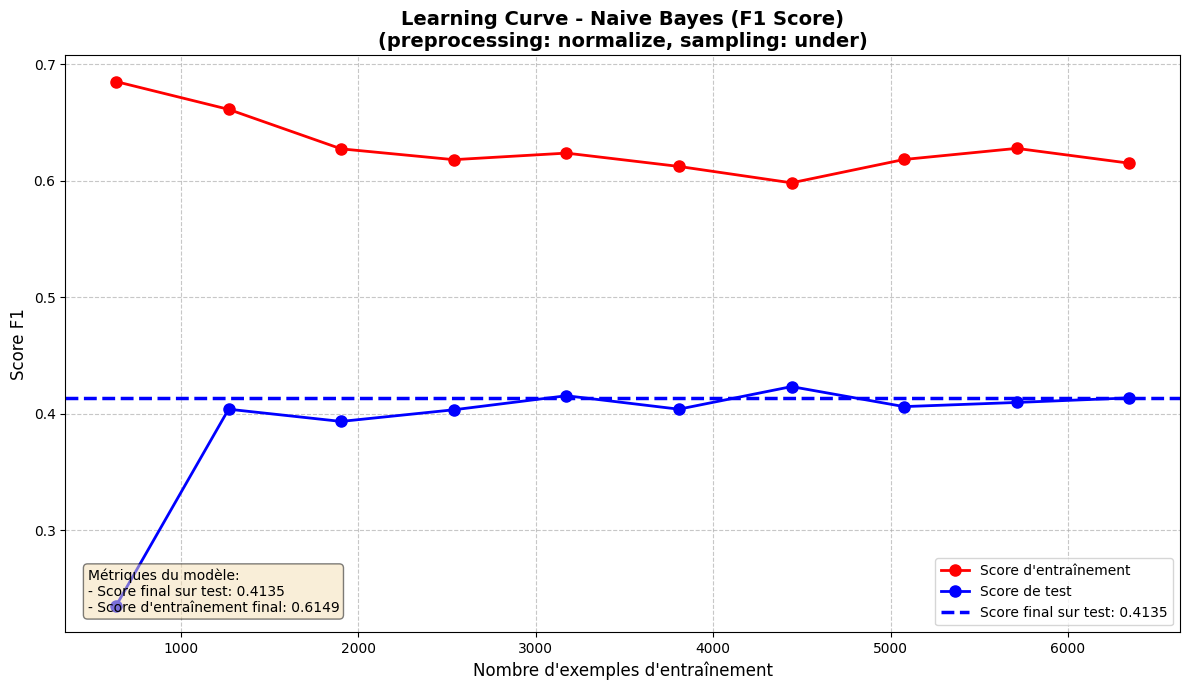

[I 2025-03-07 22:13:52,863] A new study created in memory with name: no-name-ac631854-3a42-4f38-a0f1-6a5182189350



Classification report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      7985
           1       0.36      0.49      0.41      1058

    accuracy                           0.84      9043
   macro avg       0.64      0.69      0.66      9043
weighted avg       0.86      0.84      0.85      9043

Optimizing hyperparameters for AdaBoost (preprocessing: normalize, sampling: under)...


[I 2025-03-07 22:13:54,235] Trial 0 finished with value: 0.49707943925233644 and parameters: {'n_estimators': 104, 'learning_rate': 0.6874454483105731}. Best is trial 0 with value: 0.49707943925233644.
[I 2025-03-07 22:13:55,944] Trial 1 finished with value: 0.49942062572421786 and parameters: {'n_estimators': 161, 'learning_rate': 0.7173832358847089}. Best is trial 1 with value: 0.49942062572421786.
[I 2025-03-07 22:13:56,382] Trial 2 finished with value: 0.47719104230024884 and parameters: {'n_estimators': 52, 'learning_rate': 0.5425340815540528}. Best is trial 1 with value: 0.49942062572421786.
[I 2025-03-07 22:13:57,811] Trial 3 finished with value: 0.5096985974336019 and parameters: {'n_estimators': 156, 'learning_rate': 0.6027869583174454}. Best is trial 3 with value: 0.5096985974336019.
[I 2025-03-07 22:13:58,831] Trial 4 finished with value: 0.4913818288051417 and parameters: {'n_estimators': 111, 'learning_rate': 0.19540866050048428}. Best is trial 3 with value: 0.509698597433

Best hyperparameters for AdaBoost: {'n_estimators': 200, 'learning_rate': 0.9889395630947829}
Best F1-score on test data: 0.5283


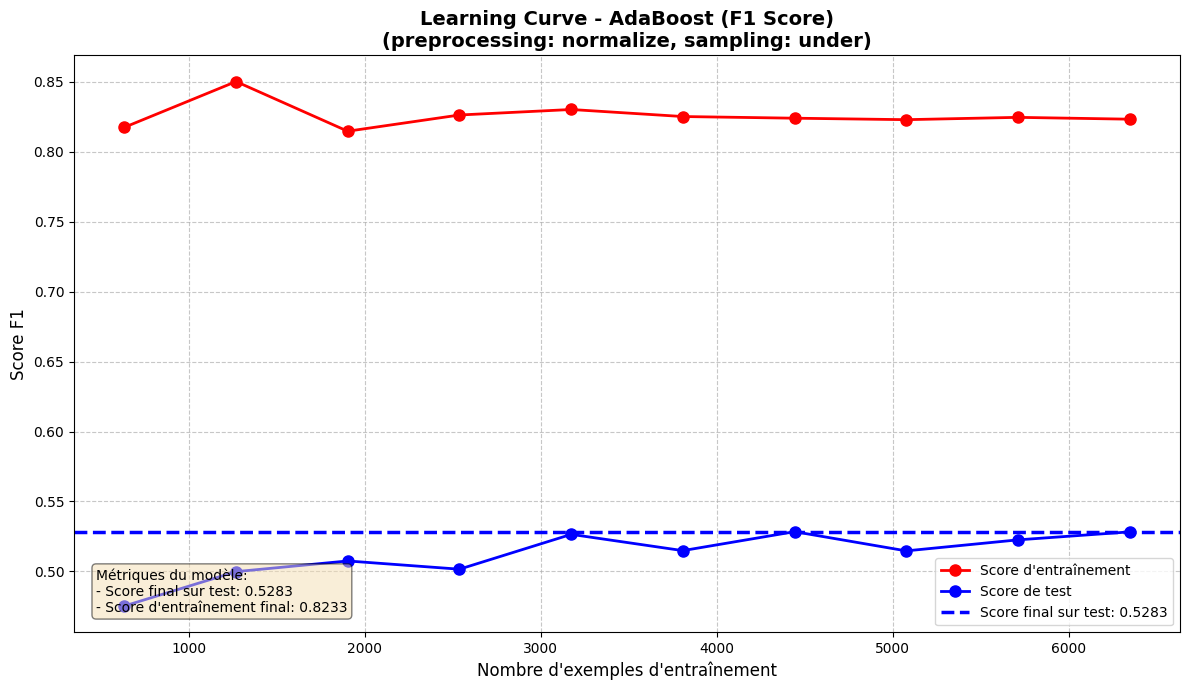

[I 2025-03-07 22:14:39,948] A new study created in memory with name: no-name-8ef73fd6-1a51-4977-956e-411037b1c07c



Classification report for AdaBoost:
              precision    recall  f1-score   support

           0       0.97      0.83      0.89      7985
           1       0.39      0.83      0.53      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.83      0.71      9043
weighted avg       0.90      0.83      0.85      9043

Optimizing hyperparameters for KNN (preprocessing: normalize, sampling: under)...


[I 2025-03-07 22:14:40,990] Trial 0 finished with value: 0.34787410270568747 and parameters: {'n_neighbors': 43, 'weights': 'uniform'}. Best is trial 0 with value: 0.34787410270568747.
[I 2025-03-07 22:14:41,942] Trial 1 finished with value: 0.35463071512309496 and parameters: {'n_neighbors': 24, 'weights': 'uniform'}. Best is trial 1 with value: 0.35463071512309496.
[I 2025-03-07 22:14:42,438] Trial 2 finished with value: 0.3595263724434876 and parameters: {'n_neighbors': 17, 'weights': 'distance'}. Best is trial 2 with value: 0.3595263724434876.
[I 2025-03-07 22:14:42,962] Trial 3 finished with value: 0.3626609442060086 and parameters: {'n_neighbors': 16, 'weights': 'distance'}. Best is trial 3 with value: 0.3626609442060086.
[I 2025-03-07 22:14:43,551] Trial 4 finished with value: 0.36115748469671677 and parameters: {'n_neighbors': 32, 'weights': 'distance'}. Best is trial 3 with value: 0.3626609442060086.
[I 2025-03-07 22:14:44,223] Trial 5 finished with value: 0.3616901408450704 a

Best hyperparameters for KNN: {'n_neighbors': 14, 'weights': 'distance'}
Best F1-score on test data: 0.3663


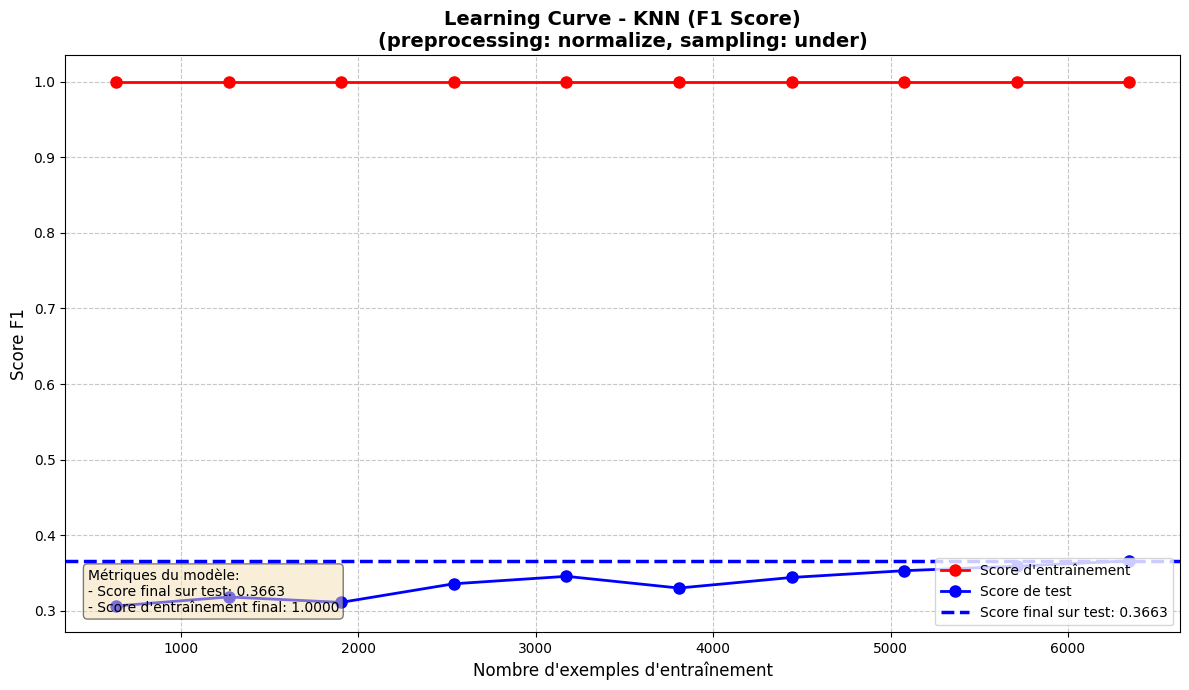

[I 2025-03-07 22:15:00,773] A new study created in memory with name: no-name-84af4194-05b6-45a5-bbb4-892585c172d8



Classification report for KNN:
              precision    recall  f1-score   support

           0       0.94      0.75      0.84      7985
           1       0.26      0.65      0.37      1058

    accuracy                           0.74      9043
   macro avg       0.60      0.70      0.60      9043
weighted avg       0.86      0.74      0.78      9043

Optimizing hyperparameters for XGBoost (preprocessing: normalize, sampling: under)...


[I 2025-03-07 22:15:01,130] Trial 0 finished with value: 0.38661432043372596 and parameters: {'n_estimators': 209, 'max_depth': 5, 'learning_rate': 0.040527642453737016, 'subsample': 0.977555385140956, 'colsample_bytree': 0.6722700336338703}. Best is trial 0 with value: 0.38661432043372596.
[I 2025-03-07 22:15:01,946] Trial 1 finished with value: 0.5212620027434842 and parameters: {'n_estimators': 289, 'max_depth': 9, 'learning_rate': 0.22298830326370797, 'subsample': 0.7500194904676803, 'colsample_bytree': 0.6967436791425079}. Best is trial 1 with value: 0.5212620027434842.
[I 2025-03-07 22:15:02,310] Trial 2 finished with value: 0.3502691790040377 and parameters: {'n_estimators': 194, 'max_depth': 5, 'learning_rate': 0.020347105116413508, 'subsample': 0.7527873423529157, 'colsample_bytree': 0.8035068772580801}. Best is trial 1 with value: 0.5212620027434842.
[I 2025-03-07 22:15:02,497] Trial 3 finished with value: 0.4536497984773847 and parameters: {'n_estimators': 63, 'max_depth': 6

Best hyperparameters for XGBoost: {'n_estimators': 257, 'max_depth': 9, 'learning_rate': 0.16984116650282863, 'subsample': 0.7023388567922919, 'colsample_bytree': 0.8231171953864284}
Best F1-score on test data: 0.5226


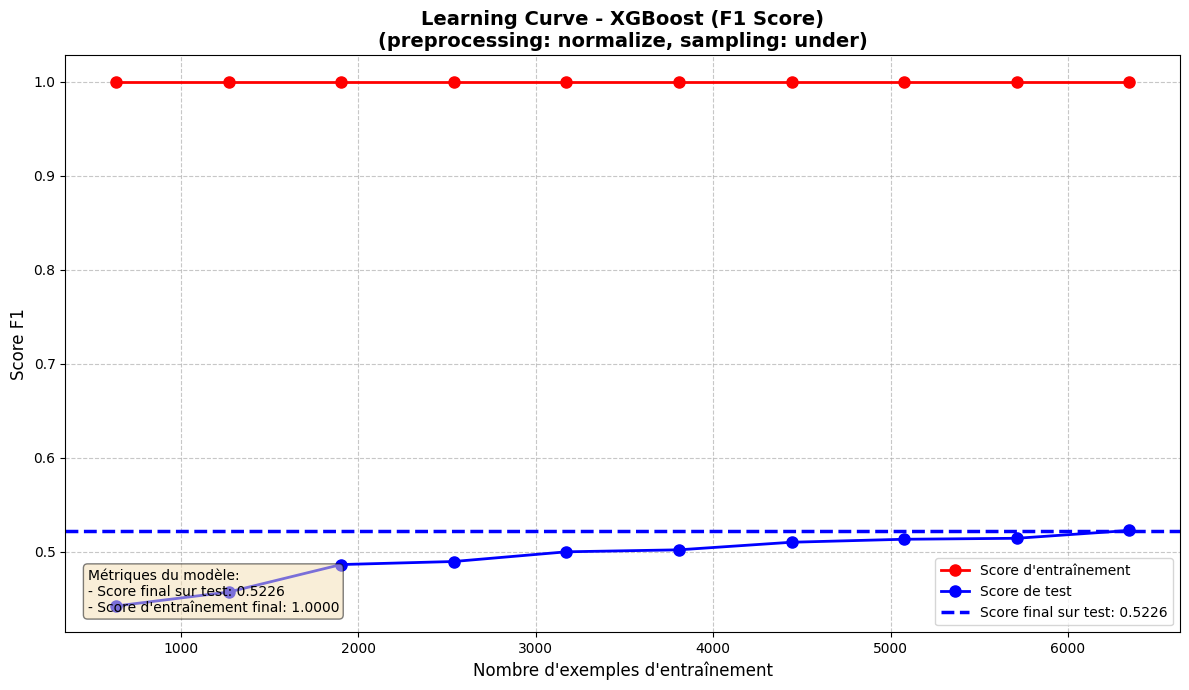

[I 2025-03-07 22:15:27,181] A new study created in memory with name: no-name-ca033afe-2fac-4762-af34-314daff1891f
[I 2025-03-07 22:15:27,226] Trial 0 finished with value: 0.4131313131313131 and parameters: {'alpha': 0.06480326351566704, 'max_iter': 831}. Best is trial 0 with value: 0.4131313131313131.
[I 2025-03-07 22:15:27,267] Trial 1 finished with value: 0.4131313131313131 and parameters: {'alpha': 0.005570145347332361, 'max_iter': 1312}. Best is trial 0 with value: 0.4131313131313131.
[I 2025-03-07 22:15:27,312] Trial 2 finished with value: 0.4131313131313131 and parameters: {'alpha': 0.008255833510361838, 'max_iter': 575}. Best is trial 0 with value: 0.4131313131313131.
[I 2025-03-07 22:15:27,357] Trial 3 finished with value: 0.4131313131313131 and parameters: {'alpha': 0.03532054710515508, 'max_iter': 2708}. Best is trial 0 with value: 0.4131313131313131.



Classification report for XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      7985
           1       0.37      0.91      0.52      1058

    accuracy                           0.80      9043
   macro avg       0.68      0.85      0.70      9043
weighted avg       0.91      0.80      0.84      9043

Optimizing hyperparameters for Perceptron (preprocessing: normalize, sampling: under)...


[I 2025-03-07 22:15:27,442] Trial 4 finished with value: 0.4131313131313131 and parameters: {'alpha': 0.008822562540634307, 'max_iter': 2381}. Best is trial 0 with value: 0.4131313131313131.
[I 2025-03-07 22:15:27,510] Trial 5 finished with value: 0.4131313131313131 and parameters: {'alpha': 0.016688380249813464, 'max_iter': 954}. Best is trial 0 with value: 0.4131313131313131.
[I 2025-03-07 22:15:27,569] Trial 6 finished with value: 0.4131313131313131 and parameters: {'alpha': 0.05252824760238555, 'max_iter': 2681}. Best is trial 0 with value: 0.4131313131313131.
[I 2025-03-07 22:15:27,630] Trial 7 finished with value: 0.4131313131313131 and parameters: {'alpha': 0.023952765748558685, 'max_iter': 1815}. Best is trial 0 with value: 0.4131313131313131.
[I 2025-03-07 22:15:27,694] Trial 8 finished with value: 0.4131313131313131 and parameters: {'alpha': 0.005032116171210202, 'max_iter': 726}. Best is trial 0 with value: 0.4131313131313131.
[I 2025-03-07 22:15:27,758] Trial 9 finished wit

Best hyperparameters for Perceptron: {'alpha': 0.06480326351566704, 'max_iter': 831}
Best F1-score on test data: 0.4131


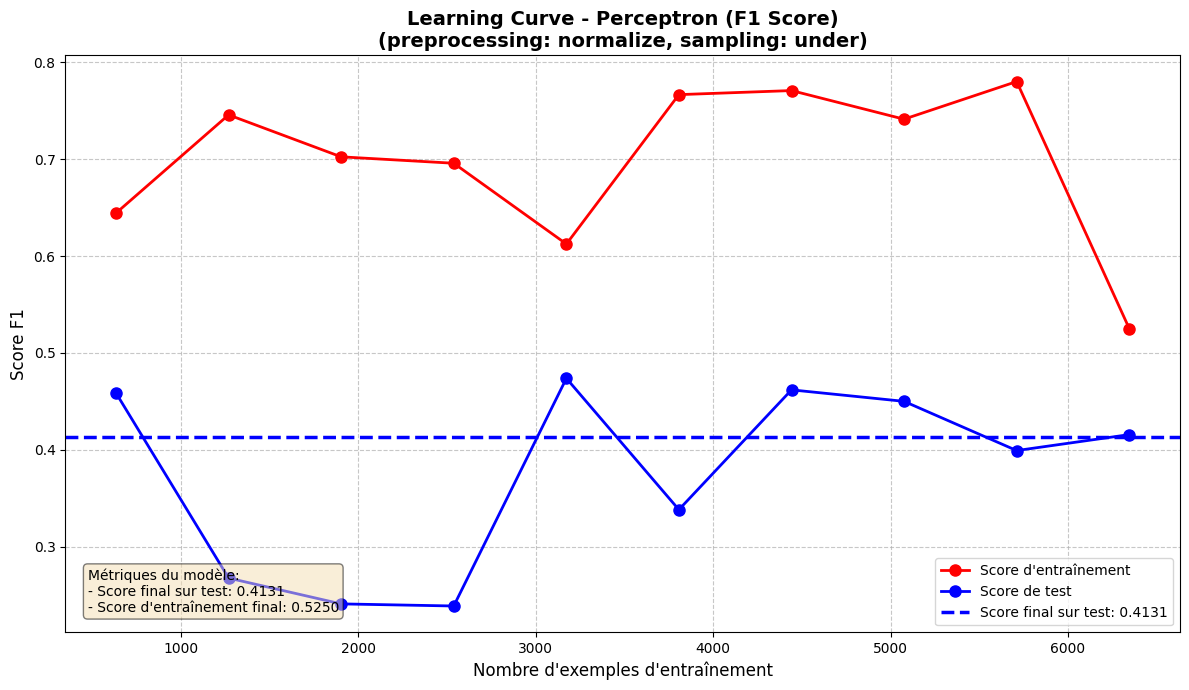


Classification report for Perceptron:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7985
           1       0.44      0.39      0.41      1058

    accuracy                           0.87      9043
   macro avg       0.68      0.66      0.67      9043
weighted avg       0.86      0.87      0.87      9043


 Best model for normalize/under: Random Forest with F1 score of 0.5460
Model: Logistic Regression
F1 Score (Binary): 0.5173
F1 Score (Weighted): 0.8517

Model: Random Forest
F1 Score (Binary): 0.5460
F1 Score (Weighted): 0.8530

Model: Naive Bayes
F1 Score (Binary): 0.4135
F1 Score (Weighted): 0.8475

Model: AdaBoost
F1 Score (Binary): 0.5283
F1 Score (Weighted): 0.8510

Model: KNN
F1 Score (Binary): 0.3663
F1 Score (Weighted): 0.7802

Model: XGBoost
F1 Score (Binary): 0.5226
F1 Score (Weighted): 0.8357

Model: Perceptron
F1 Score (Binary): 0.4131
F1 Score (Weighted): 0.8676



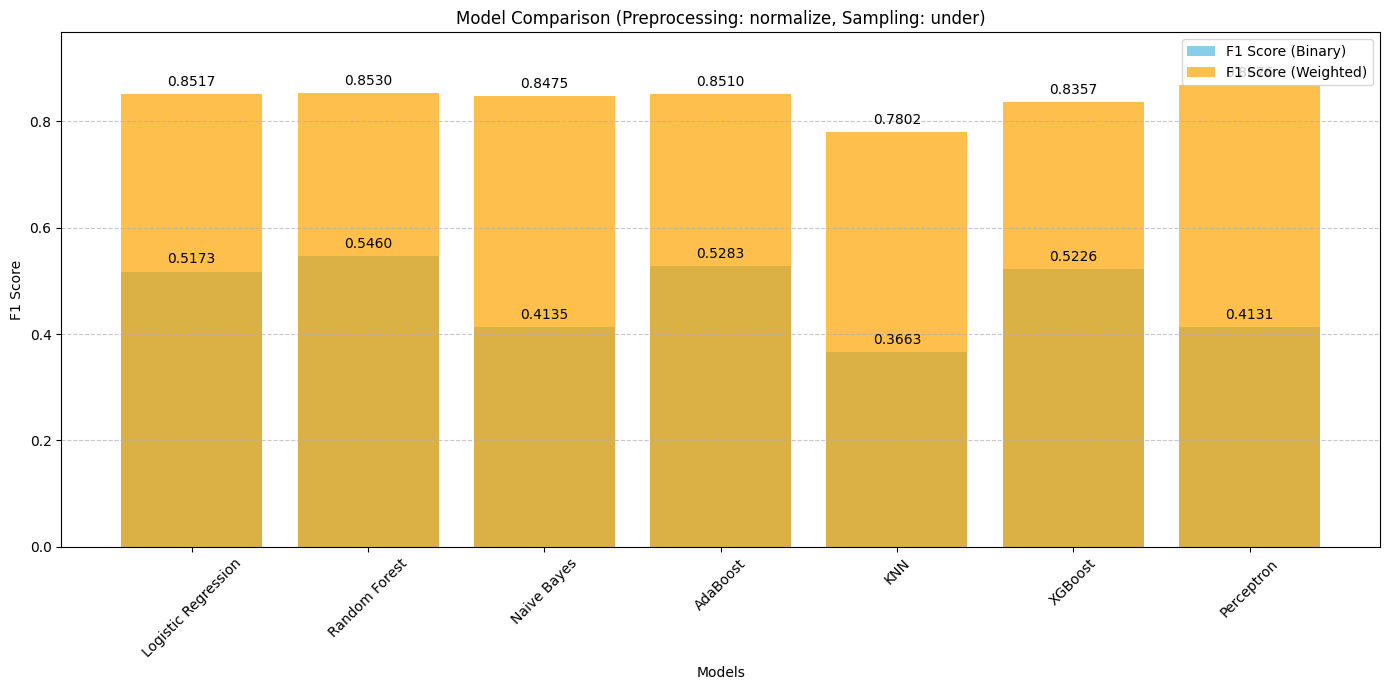

[I 2025-03-07 22:15:30,845] A new study created in memory with name: no-name-d0e31021-8119-4442-8c21-6380e650cf27



Running with preprocessing: standardize, sampling: over
Data standardized with StandardScaler
Optimizing hyperparameters for Logistic Regression (preprocessing: standardize, sampling: over)...


[I 2025-03-07 22:15:31,400] Trial 0 finished with value: 0.5161691542288557 and parameters: {'C': 0.015983105173649904, 'solver': 'liblinear'}. Best is trial 0 with value: 0.5161691542288557.
[I 2025-03-07 22:15:31,688] Trial 1 finished with value: 0.5160486132751636 and parameters: {'C': 0.017485449731686344, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.5161691542288557.
[I 2025-03-07 22:15:31,893] Trial 2 finished with value: 0.5160246034315312 and parameters: {'C': 0.00014286916613985847, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.5161691542288557.
[I 2025-03-07 22:15:32,162] Trial 3 finished with value: 0.5157076205287714 and parameters: {'C': 0.9678907200751796, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.5161691542288557.
[I 2025-03-07 22:15:32,440] Trial 4 finished with value: 0.4265750286368843 and parameters: {'C': 1.8287798889490297e-05, 'solver': 'liblinear'}. Best is trial 0 with value: 0.5161691542288557.
[I 2025-03-07 22:15:35,197] Trial 5 finished with 

Best hyperparameters for Logistic Regression: {'C': 0.5229403581339354, 'solver': 'saga'}
Best F1-score on test data: 0.5165


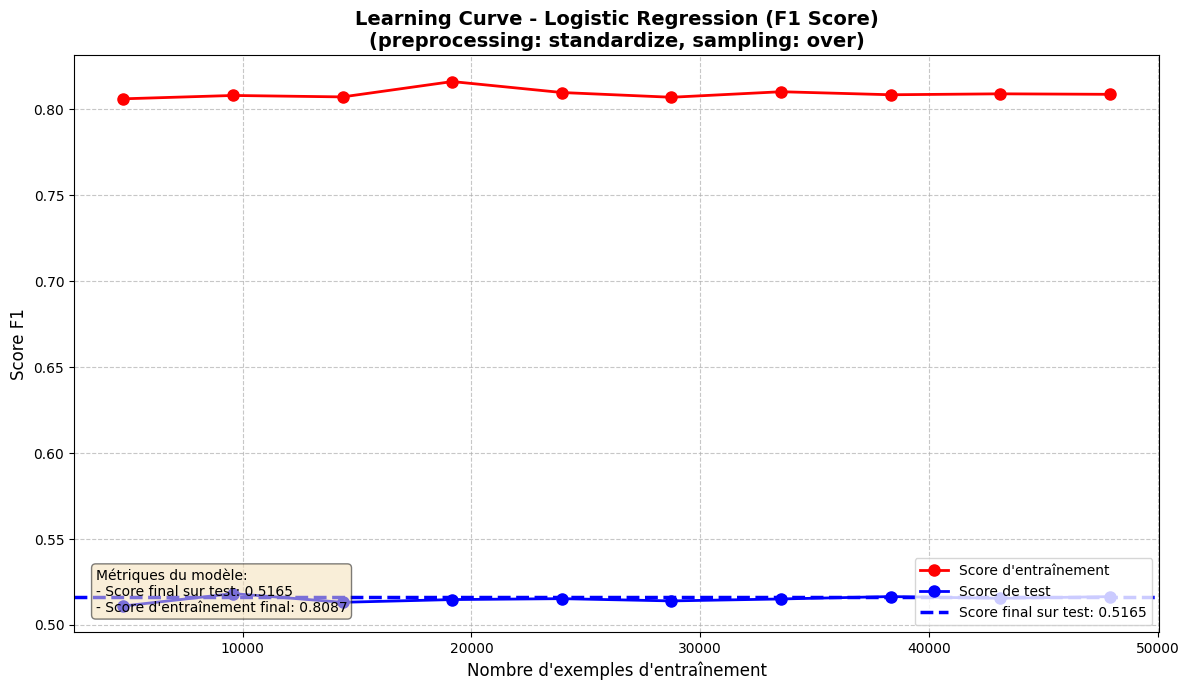

[I 2025-03-07 22:16:31,100] A new study created in memory with name: no-name-676174be-5759-4fec-b556-3e1dd9d9277f



Classification report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      7985
           1       0.38      0.78      0.52      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.81      0.71      9043
weighted avg       0.90      0.83      0.85      9043

Optimizing hyperparameters for Random Forest (preprocessing: standardize, sampling: over)...


[I 2025-03-07 22:16:46,148] Trial 0 finished with value: 0.5847485847485847 and parameters: {'n_estimators': 275, 'max_depth': 29, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.5847485847485847.
[I 2025-03-07 22:16:53,687] Trial 1 finished with value: 0.49986342529363564 and parameters: {'n_estimators': 283, 'max_depth': 5, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.5847485847485847.
[I 2025-03-07 22:17:03,295] Trial 2 finished with value: 0.5843373493975904 and parameters: {'n_estimators': 183, 'max_depth': 24, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.5847485847485847.
[I 2025-03-07 22:17:15,681] Trial 3 finished with value: 0.5666136724960255 and parameters: {'n_estimators': 266, 'max_depth': 12, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.5847485847485847.
[I 2025-03-07 22:17:22,277] Trial 4 finished with value: 0.5843230403800475 and parameters: {'n_estimators': 108, 'max_depth': 19, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.5

Best hyperparameters for Random Forest: {'n_estimators': 209, 'max_depth': 24, 'min_samples_leaf': 3}
Best F1-score on test data: 0.6027


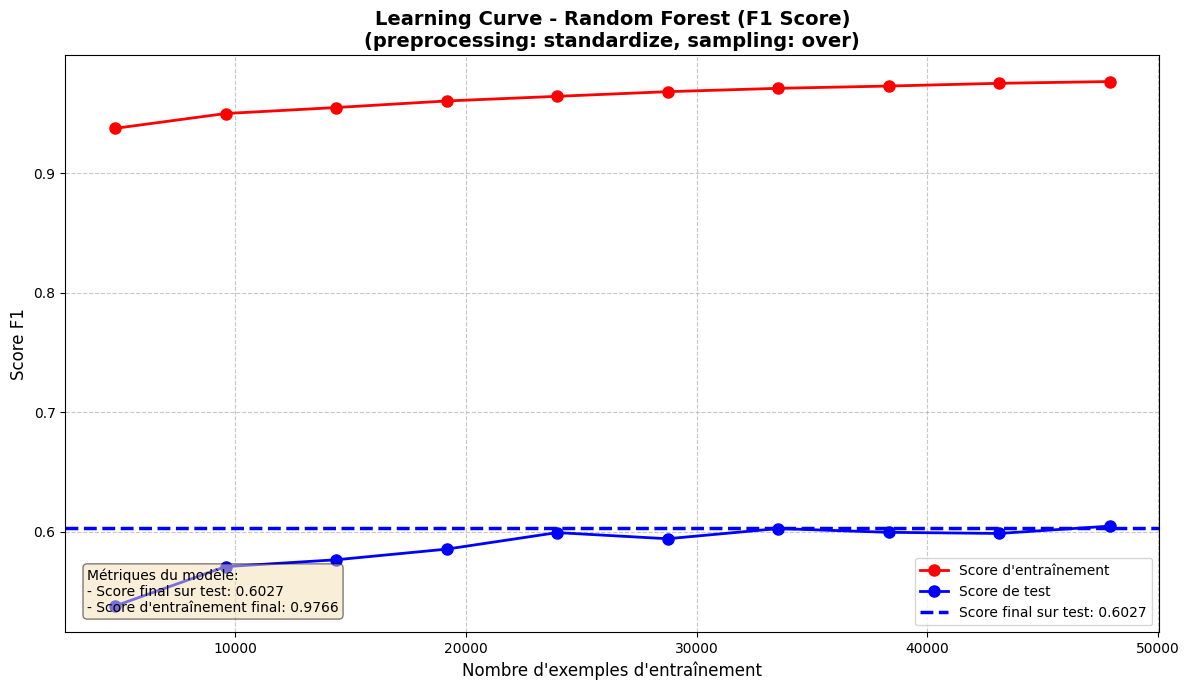

[I 2025-03-07 22:22:04,028] A new study created in memory with name: no-name-f6729827-48a0-43f1-a4cd-01da12e87d96
[I 2025-03-07 22:22:04,109] Trial 0 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 4.736809328615706e-10}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:22:04,186] Trial 1 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 1.2749228256307009e-09}. Best is trial 0 with value: 0.4140495867768595.



Classification report for Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93      7985
           1       0.51      0.73      0.60      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.82      0.77      9043
weighted avg       0.91      0.89      0.90      9043

Optimizing hyperparameters for Naive Bayes (preprocessing: standardize, sampling: over)...


[I 2025-03-07 22:22:04,270] Trial 2 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 5.468102006448449e-10}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:22:04,347] Trial 3 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 7.1859085396376574e-09}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:22:04,424] Trial 4 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 2.55486810588814e-09}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:22:04,501] Trial 5 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 4.194404322898086e-10}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:22:04,578] Trial 6 finished with value: 0.4140495867768595 and parameters: {'var_smoothing': 1.1141949575547741e-09}. Best is trial 0 with value: 0.4140495867768595.
[I 2025-03-07 22:22:04,656] Trial 7 finished with value: 0.4140495867768595 and parameter

Best hyperparameters for Naive Bayes: {'var_smoothing': 4.736809328615706e-10}
Best F1-score on test data: 0.4140


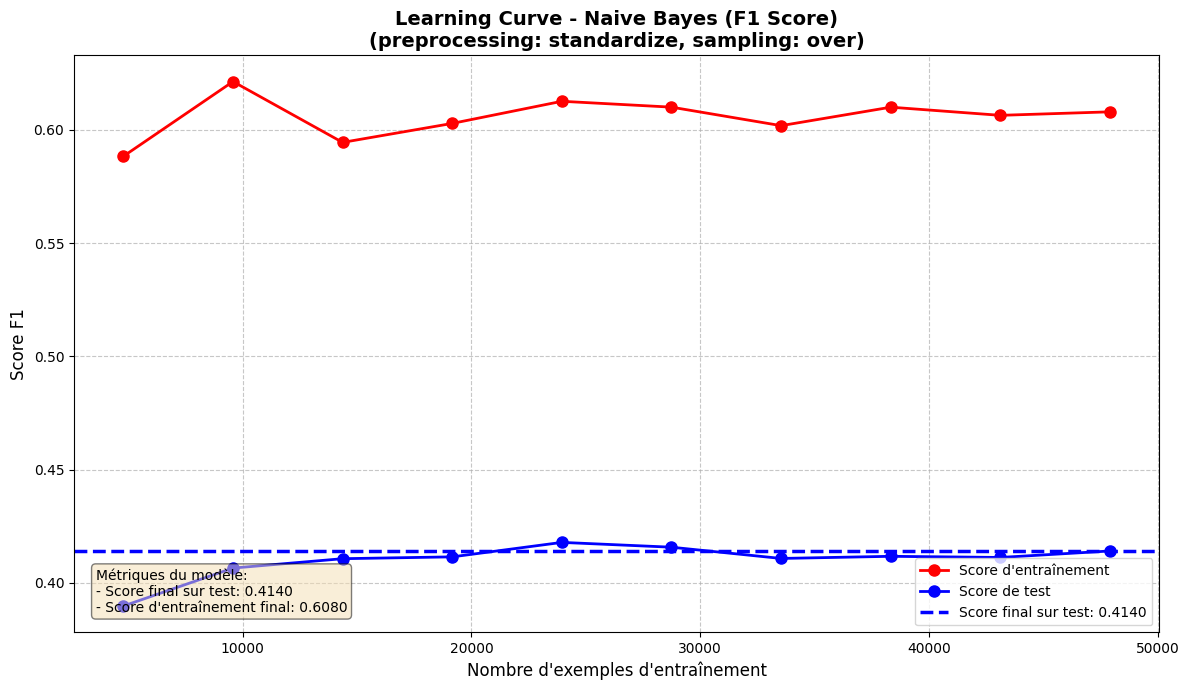

[I 2025-03-07 22:22:06,978] A new study created in memory with name: no-name-59f690bd-e964-4ed1-ab3f-e7c92bad2aa7



Classification report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      7985
           1       0.37      0.47      0.41      1058

    accuracy                           0.84      9043
   macro avg       0.65      0.68      0.66      9043
weighted avg       0.86      0.84      0.85      9043

Optimizing hyperparameters for AdaBoost (preprocessing: standardize, sampling: over)...


[I 2025-03-07 22:22:12,246] Trial 0 finished with value: 0.4885540423065778 and parameters: {'n_estimators': 87, 'learning_rate': 0.7979301062469908}. Best is trial 0 with value: 0.4885540423065778.
[I 2025-03-07 22:22:20,832] Trial 1 finished with value: 0.498981077147016 and parameters: {'n_estimators': 138, 'learning_rate': 0.33363130823799503}. Best is trial 1 with value: 0.498981077147016.
[I 2025-03-07 22:22:26,463] Trial 2 finished with value: 0.4710860366713681 and parameters: {'n_estimators': 91, 'learning_rate': 0.16809546831399663}. Best is trial 1 with value: 0.498981077147016.
[I 2025-03-07 22:22:31,517] Trial 3 finished with value: 0.4857225266801269 and parameters: {'n_estimators': 76, 'learning_rate': 0.5685633245249202}. Best is trial 1 with value: 0.498981077147016.
[I 2025-03-07 22:22:37,602] Trial 4 finished with value: 0.49577628896009324 and parameters: {'n_estimators': 113, 'learning_rate': 0.32644950282868457}. Best is trial 1 with value: 0.498981077147016.
[I 2

Best hyperparameters for AdaBoost: {'n_estimators': 190, 'learning_rate': 0.9966441560045197}
Best F1-score on test data: 0.5208


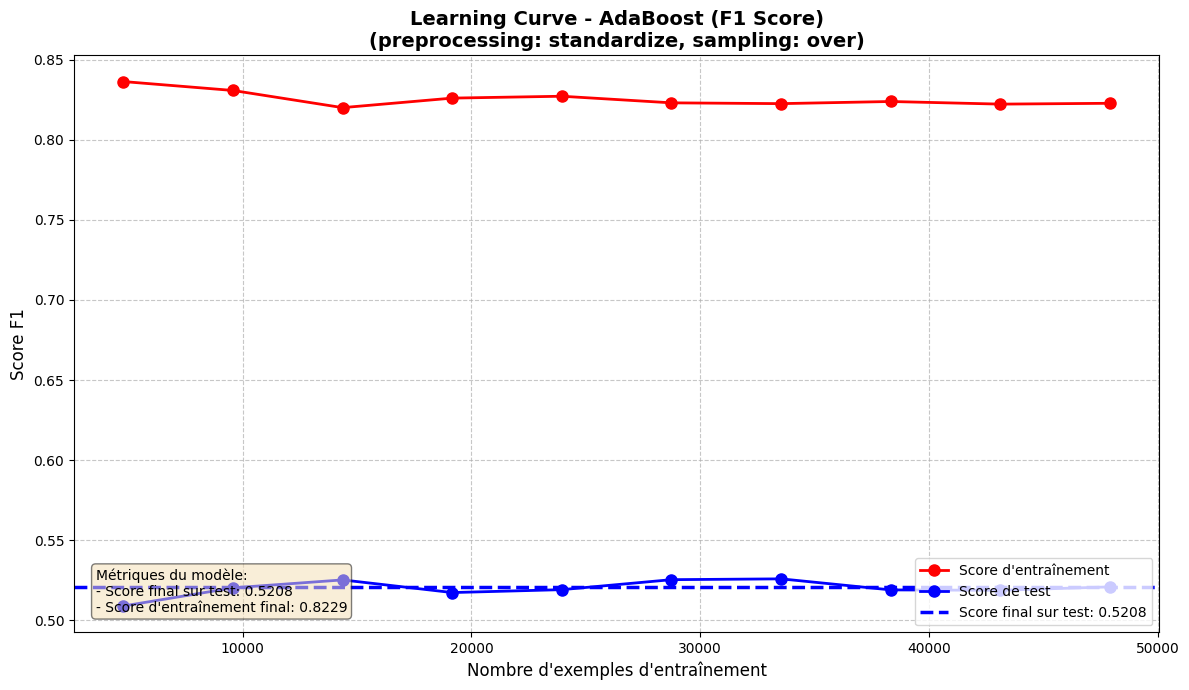

[I 2025-03-07 22:26:39,673] A new study created in memory with name: no-name-bf797204-61a3-44db-98e4-2879eab4b47b



Classification report for AdaBoost:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      7985
           1       0.38      0.82      0.52      1058

    accuracy                           0.82      9043
   macro avg       0.68      0.82      0.71      9043
weighted avg       0.90      0.82      0.85      9043

Optimizing hyperparameters for KNN (preprocessing: standardize, sampling: over)...


[I 2025-03-07 22:26:43,020] Trial 0 finished with value: 0.4752092723760464 and parameters: {'n_neighbors': 20, 'weights': 'distance'}. Best is trial 0 with value: 0.4752092723760464.
[I 2025-03-07 22:26:46,415] Trial 1 finished with value: 0.4922380336351876 and parameters: {'n_neighbors': 41, 'weights': 'distance'}. Best is trial 1 with value: 0.4922380336351876.
[I 2025-03-07 22:26:51,298] Trial 2 finished with value: 0.44090630740967546 and parameters: {'n_neighbors': 9, 'weights': 'uniform'}. Best is trial 1 with value: 0.4922380336351876.
[I 2025-03-07 22:26:54,542] Trial 3 finished with value: 0.4576899320568252 and parameters: {'n_neighbors': 15, 'weights': 'distance'}. Best is trial 1 with value: 0.4922380336351876.
[I 2025-03-07 22:26:57,949] Trial 4 finished with value: 0.4941022280471822 and parameters: {'n_neighbors': 49, 'weights': 'distance'}. Best is trial 4 with value: 0.4941022280471822.
[I 2025-03-07 22:27:01,483] Trial 5 finished with value: 0.49397982427595183 and 

Best hyperparameters for KNN: {'n_neighbors': 50, 'weights': 'distance'}
Best F1-score on test data: 0.4943


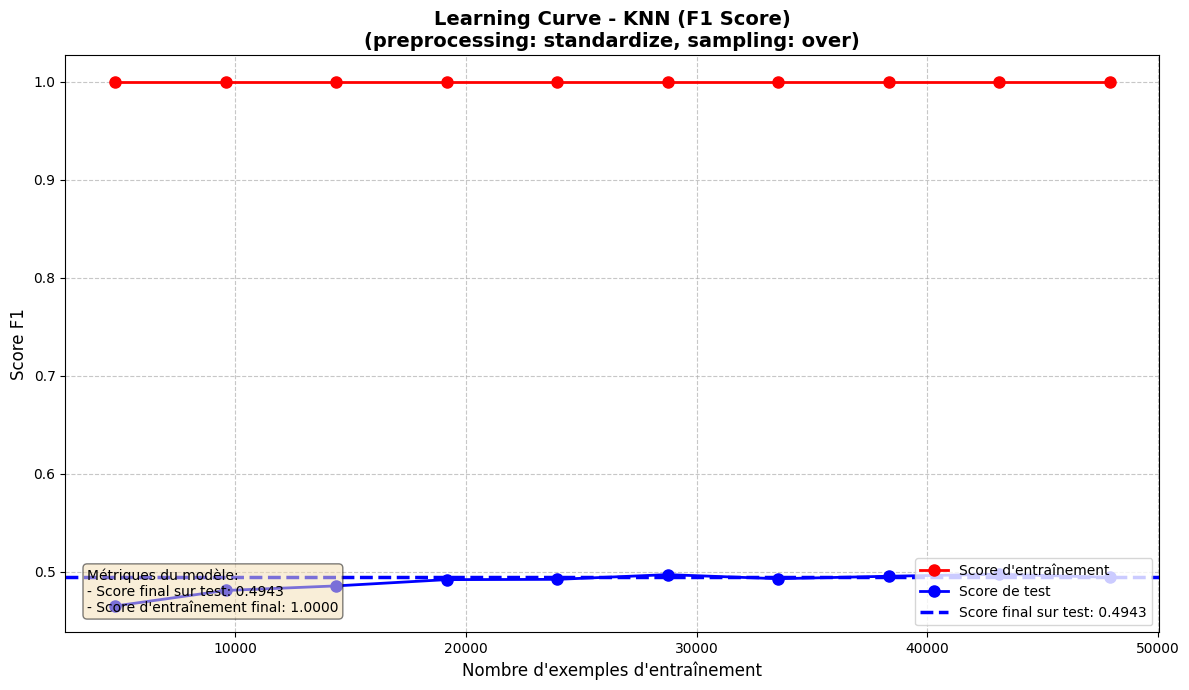

[I 2025-03-07 22:29:46,067] A new study created in memory with name: no-name-f440aa75-2a05-46b2-b82d-9b55fd84b7f3



Classification report for KNN:
              precision    recall  f1-score   support

           0       0.96      0.84      0.90      7985
           1       0.38      0.71      0.49      1058

    accuracy                           0.83      9043
   macro avg       0.67      0.78      0.70      9043
weighted avg       0.89      0.83      0.85      9043

Optimizing hyperparameters for XGBoost (preprocessing: standardize, sampling: over)...


[I 2025-03-07 22:29:46,532] Trial 0 finished with value: 0.3925659017637019 and parameters: {'n_estimators': 67, 'max_depth': 3, 'learning_rate': 0.25720580289423506, 'subsample': 0.5422953435216062, 'colsample_bytree': 0.8721652937448056}. Best is trial 0 with value: 0.3925659017637019.
[I 2025-03-07 22:29:47,001] Trial 1 finished with value: 0.34316795780451625 and parameters: {'n_estimators': 71, 'max_depth': 3, 'learning_rate': 0.12606346427890655, 'subsample': 0.8282854352621863, 'colsample_bytree': 0.6040558915244383}. Best is trial 0 with value: 0.3925659017637019.
[I 2025-03-07 22:29:48,538] Trial 2 finished with value: 0.5854025583145221 and parameters: {'n_estimators': 72, 'max_depth': 13, 'learning_rate': 0.16294027880485987, 'subsample': 0.850437643811012, 'colsample_bytree': 0.7437021379577167}. Best is trial 2 with value: 0.5854025583145221.
[I 2025-03-07 22:29:49,508] Trial 3 finished with value: 0.5731884057971014 and parameters: {'n_estimators': 56, 'max_depth': 11, 'l

Best hyperparameters for XGBoost: {'n_estimators': 137, 'max_depth': 13, 'learning_rate': 0.09264421072470089, 'subsample': 0.769525155499516, 'colsample_bytree': 0.7041784524804588}
Best F1-score on test data: 0.6014


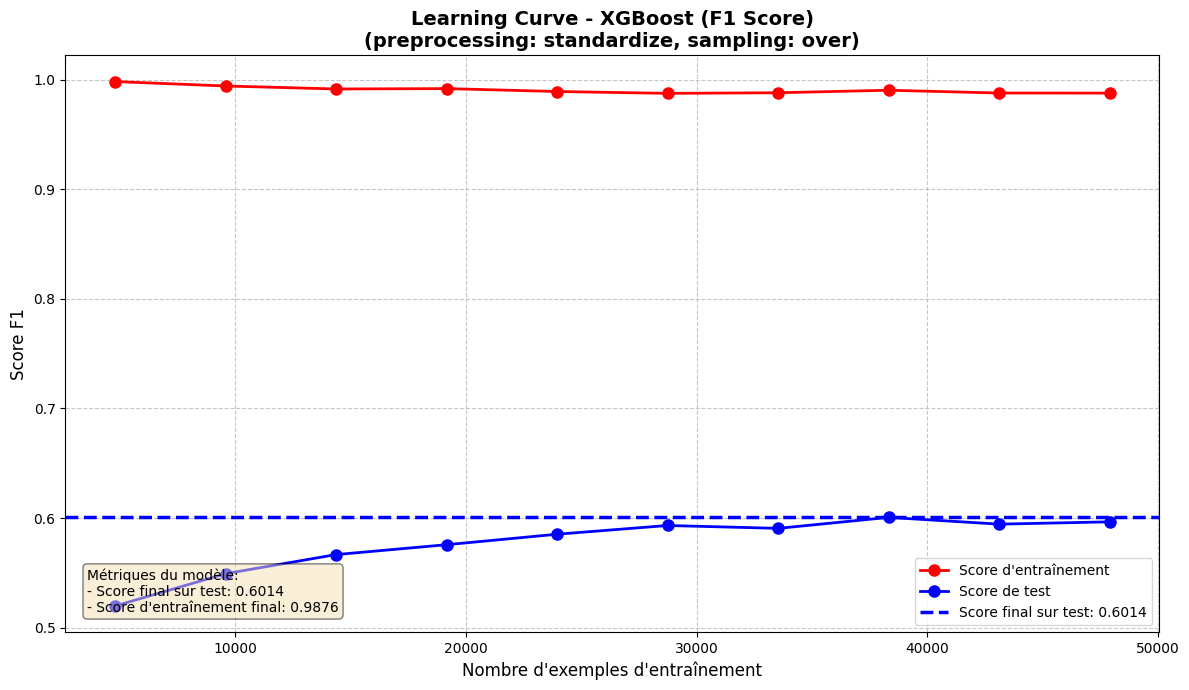

[I 2025-03-07 22:31:13,194] A new study created in memory with name: no-name-3c4e363f-1e39-4eb0-b515-ae63138fd698



Classification report for XGBoost:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7985
           1       0.50      0.75      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.83      0.77      9043
weighted avg       0.91      0.88      0.89      9043

Optimizing hyperparameters for Perceptron (preprocessing: standardize, sampling: over)...


[I 2025-03-07 22:31:13,608] Trial 0 finished with value: 0.3609172482552343 and parameters: {'alpha': 7.376882138478251e-05, 'max_iter': 1861}. Best is trial 0 with value: 0.3609172482552343.
[I 2025-03-07 22:31:14,027] Trial 1 finished with value: 0.3609172482552343 and parameters: {'alpha': 0.07859528628220508, 'max_iter': 2757}. Best is trial 0 with value: 0.3609172482552343.
[I 2025-03-07 22:31:14,457] Trial 2 finished with value: 0.3609172482552343 and parameters: {'alpha': 0.057890261140338475, 'max_iter': 2845}. Best is trial 0 with value: 0.3609172482552343.
[I 2025-03-07 22:31:14,873] Trial 3 finished with value: 0.3609172482552343 and parameters: {'alpha': 1.0135023381869932e-05, 'max_iter': 1197}. Best is trial 0 with value: 0.3609172482552343.
[I 2025-03-07 22:31:15,303] Trial 4 finished with value: 0.3609172482552343 and parameters: {'alpha': 2.5608925231569206e-05, 'max_iter': 2235}. Best is trial 0 with value: 0.3609172482552343.
[I 2025-03-07 22:31:15,756] Trial 5 finis

Best hyperparameters for Perceptron: {'alpha': 7.376882138478251e-05, 'max_iter': 1861}
Best F1-score on test data: 0.3609


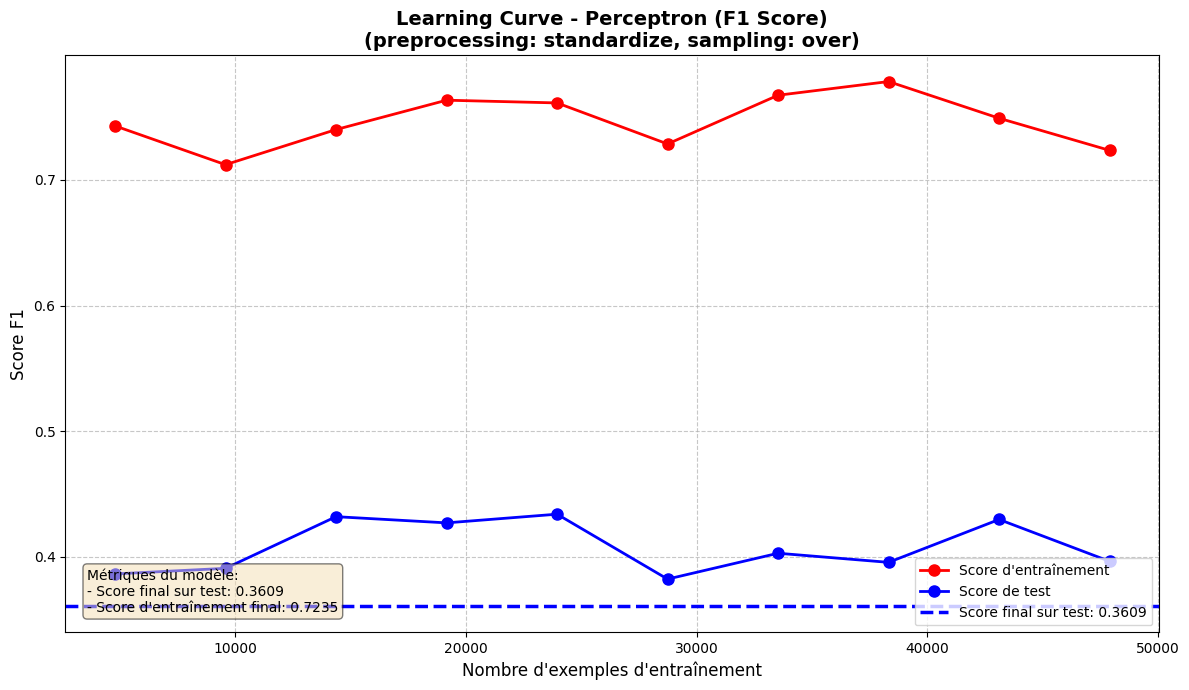


Classification report for Perceptron:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      7985
           1       0.28      0.51      0.36      1058

    accuracy                           0.79      9043
   macro avg       0.60      0.67      0.62      9043
weighted avg       0.85      0.79      0.81      9043


 Best model for standardize/over: Random Forest with F1 score of 0.6027
Model: Logistic Regression
F1 Score (Binary): 0.5165
F1 Score (Weighted): 0.8512

Model: Random Forest
F1 Score (Binary): 0.6027
F1 Score (Weighted): 0.8953

Model: Naive Bayes
F1 Score (Binary): 0.4140
F1 Score (Weighted): 0.8515

Model: AdaBoost
F1 Score (Binary): 0.5208
F1 Score (Weighted): 0.8482

Model: KNN
F1 Score (Binary): 0.4943
F1 Score (Weighted): 0.8502

Model: XGBoost
F1 Score (Binary): 0.6014
F1 Score (Weighted): 0.8931

Model: Perceptron
F1 Score (Binary): 0.3609
F1 Score (Weighted): 0.8126



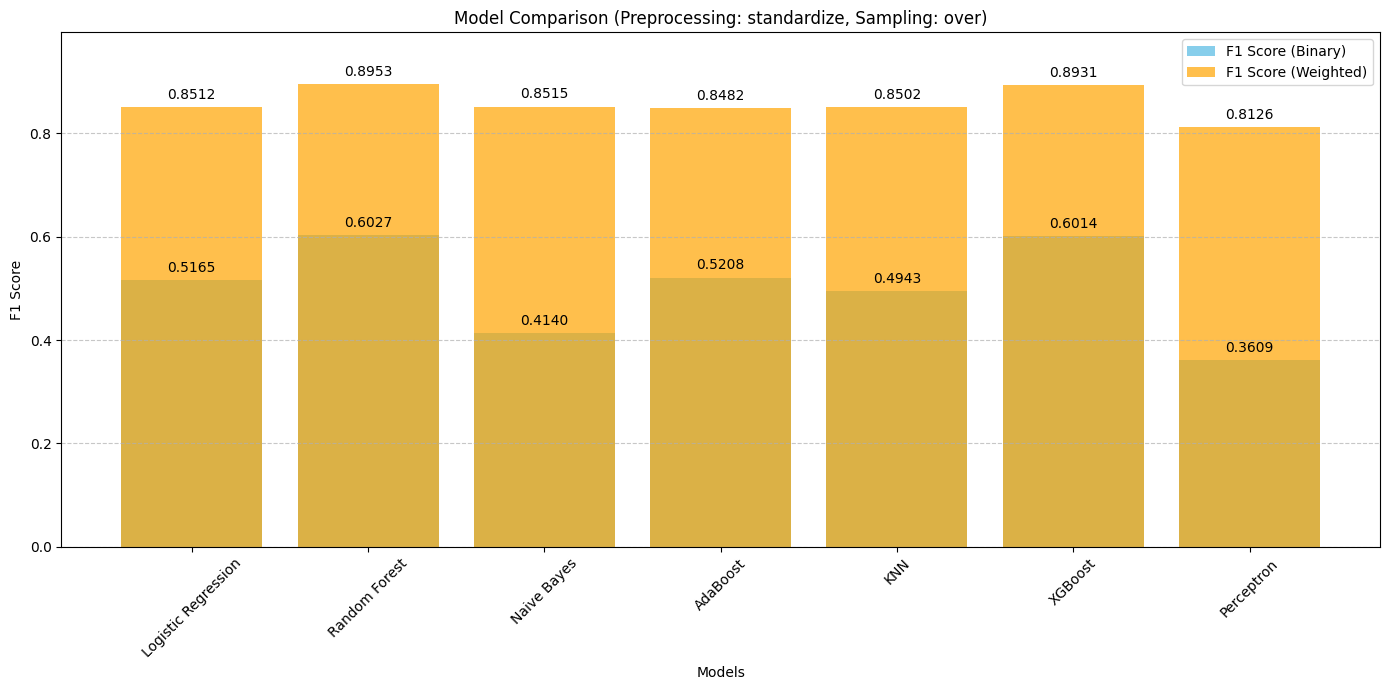

[I 2025-03-07 22:31:26,034] A new study created in memory with name: no-name-2605c53a-bb1a-4874-82ba-28e1a34b5b2f
[I 2025-03-07 22:31:26,113] Trial 0 finished with value: 0.5170152981579769 and parameters: {'C': 0.9519355639165527, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.5170152981579769.
[I 2025-03-07 22:31:26,165] Trial 1 finished with value: 0.4844789356984479 and parameters: {'C': 0.0010053923960567164, 'solver': 'liblinear'}. Best is trial 0 with value: 0.5170152981579769.



Running with preprocessing: standardize, sampling: under
Data standardized with StandardScaler
Optimizing hyperparameters for Logistic Regression (preprocessing: standardize, sampling: under)...


[I 2025-03-07 22:31:26,537] Trial 2 finished with value: 0.5171767645221736 and parameters: {'C': 4.928911544032981, 'solver': 'saga'}. Best is trial 2 with value: 0.5171767645221736.
[I 2025-03-07 22:31:26,660] Trial 3 finished with value: 0.5168539325842697 and parameters: {'C': 0.3503935140076838, 'solver': 'liblinear'}. Best is trial 2 with value: 0.5171767645221736.
[I 2025-03-07 22:31:26,992] Trial 4 finished with value: 0.5182160804020101 and parameters: {'C': 0.024276746709652554, 'solver': 'saga'}. Best is trial 4 with value: 0.5182160804020101.
[I 2025-03-07 22:31:27,105] Trial 5 finished with value: 0.5176397127692788 and parameters: {'C': 3.8699554701138057, 'solver': 'lbfgs'}. Best is trial 4 with value: 0.5182160804020101.
[I 2025-03-07 22:31:27,222] Trial 6 finished with value: 0.5191703331238215 and parameters: {'C': 0.02071229090006559, 'solver': 'lbfgs'}. Best is trial 6 with value: 0.5191703331238215.
[I 2025-03-07 22:31:27,342] Trial 7 finished with value: 0.4975355

Best hyperparameters for Logistic Regression: {'C': 0.012128996278662239, 'solver': 'saga'}
Best F1-score on test data: 0.5205


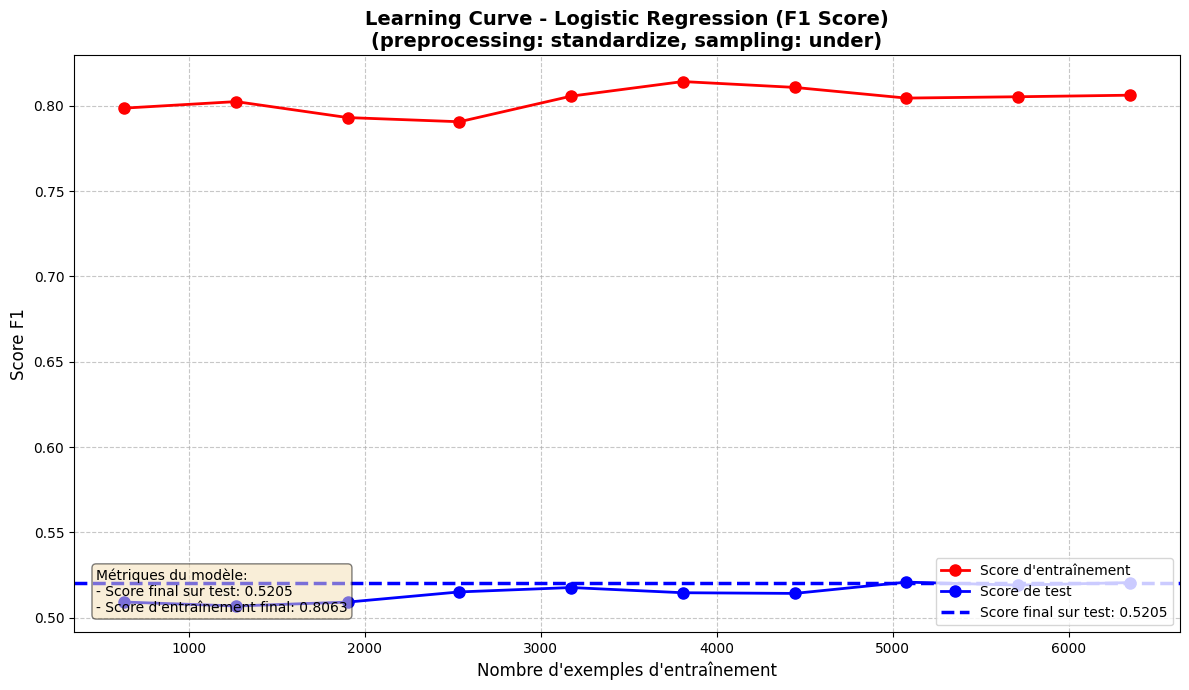

[I 2025-03-07 22:31:31,855] A new study created in memory with name: no-name-20477cbb-6700-4489-ac95-3fe5d19a0969



Classification report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7985
           1       0.39      0.78      0.52      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.81      0.71      9043
weighted avg       0.90      0.83      0.85      9043

Optimizing hyperparameters for Random Forest (preprocessing: standardize, sampling: under)...


[I 2025-03-07 22:31:33,709] Trial 0 finished with value: 0.5264647608264931 and parameters: {'n_estimators': 218, 'max_depth': 12, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.5264647608264931.
[I 2025-03-07 22:31:34,555] Trial 1 finished with value: 0.5186862967157417 and parameters: {'n_estimators': 144, 'max_depth': 7, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.5264647608264931.
[I 2025-03-07 22:31:35,187] Trial 2 finished with value: 0.5291607396870555 and parameters: {'n_estimators': 68, 'max_depth': 16, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.5291607396870555.
[I 2025-03-07 22:31:37,726] Trial 3 finished with value: 0.5403529071449233 and parameters: {'n_estimators': 239, 'max_depth': 25, 'min_samples_leaf': 2}. Best is trial 3 with value: 0.5403529071449233.
[I 2025-03-07 22:31:39,141] Trial 4 finished with value: 0.5269733106189665 and parameters: {'n_estimators': 193, 'max_depth': 10, 'min_samples_leaf': 4}. Best is trial 3 with value: 0.5403

Best hyperparameters for Random Forest: {'n_estimators': 253, 'max_depth': 22, 'min_samples_leaf': 1}
Best F1-score on test data: 0.5484


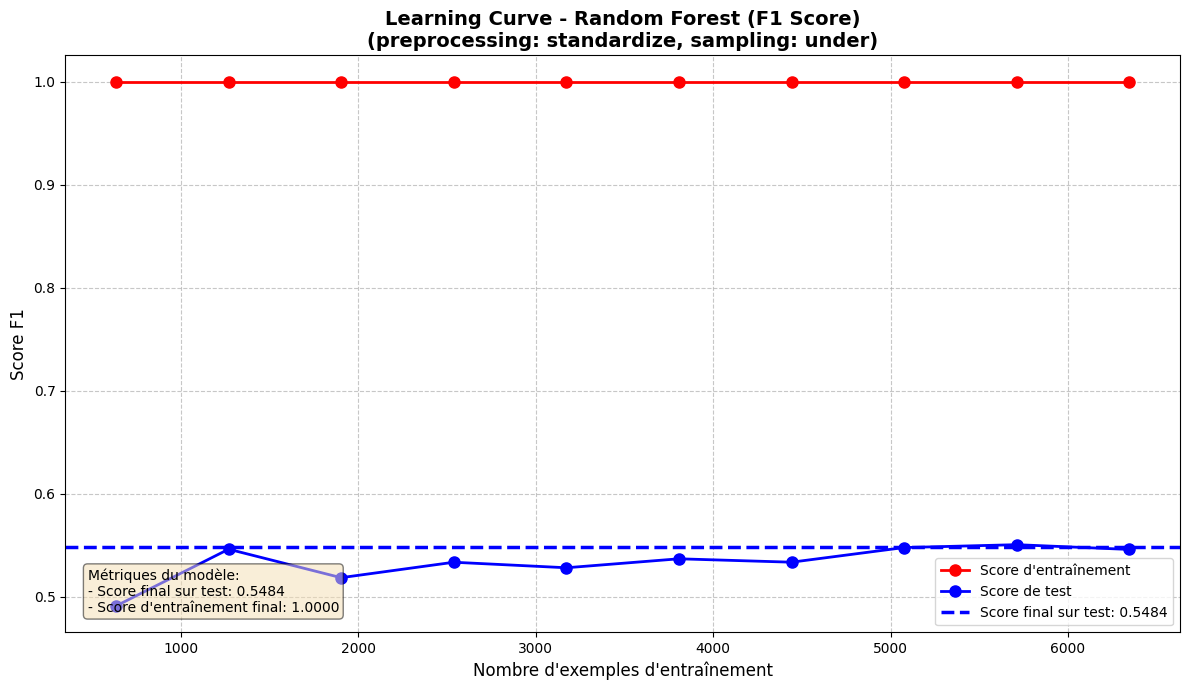

[I 2025-03-07 22:32:42,491] A new study created in memory with name: no-name-2c732847-c038-41cf-a05f-c1bff2eb9833
[I 2025-03-07 22:32:42,524] Trial 0 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 8.31515894587123e-10}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:32:42,555] Trial 1 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 3.78038794523502e-09}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:32:42,586] Trial 2 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 1.465543421236008e-09}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:32:42,621] Trial 3 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 1.5402647011219043e-10}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:32:42,650] Trial 4 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 7.149837562829759e-09}. Best is trial 0 


Classification report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      7985
           1       0.40      0.89      0.55      1058

    accuracy                           0.83      9043
   macro avg       0.69      0.86      0.72      9043
weighted avg       0.91      0.83      0.85      9043

Optimizing hyperparameters for Naive Bayes (preprocessing: standardize, sampling: under)...


[I 2025-03-07 22:32:42,681] Trial 5 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 1.2432383227956452e-09}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:32:42,719] Trial 6 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 1.8690534867893964e-09}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:32:42,754] Trial 7 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 2.3137718156167585e-10}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:32:42,786] Trial 8 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 1.0373647971488313e-10}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:32:42,817] Trial 9 finished with value: 0.41349206349206347 and parameters: {'var_smoothing': 6.926111439974745e-10}. Best is trial 0 with value: 0.41349206349206347.
[I 2025-03-07 22:32:42,866] Trial 10 finished with value: 0.4134920634920634

Best hyperparameters for Naive Bayes: {'var_smoothing': 8.31515894587123e-10}
Best F1-score on test data: 0.4135


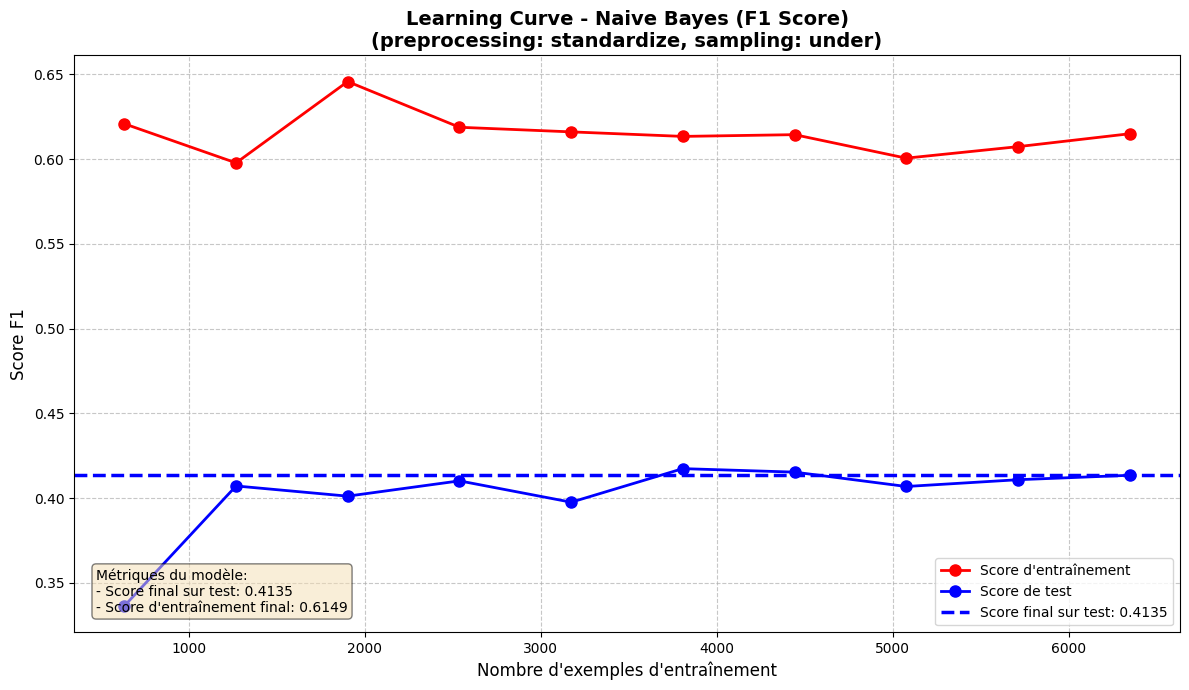

[I 2025-03-07 22:32:44,207] A new study created in memory with name: no-name-adaabe4d-6895-4da1-9ed7-a433f3266206



Classification report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      7985
           1       0.36      0.49      0.41      1058

    accuracy                           0.84      9043
   macro avg       0.64      0.69      0.66      9043
weighted avg       0.86      0.84      0.85      9043

Optimizing hyperparameters for AdaBoost (preprocessing: standardize, sampling: under)...


[I 2025-03-07 22:32:46,072] Trial 0 finished with value: 0.4989834446703456 and parameters: {'n_estimators': 137, 'learning_rate': 0.3058506620627937}. Best is trial 0 with value: 0.4989834446703456.
[I 2025-03-07 22:32:47,178] Trial 1 finished with value: 0.3793020457280385 and parameters: {'n_estimators': 70, 'learning_rate': 0.02608292208784143}. Best is trial 0 with value: 0.4989834446703456.
[I 2025-03-07 22:32:49,111] Trial 2 finished with value: 0.4623334239869459 and parameters: {'n_estimators': 118, 'learning_rate': 0.08712758644551037}. Best is trial 0 with value: 0.4989834446703456.
[I 2025-03-07 22:32:50,528] Trial 3 finished with value: 0.511710643344204 and parameters: {'n_estimators': 173, 'learning_rate': 0.4746830415970206}. Best is trial 3 with value: 0.511710643344204.
[I 2025-03-07 22:32:52,185] Trial 4 finished with value: 0.5036390101892285 and parameters: {'n_estimators': 190, 'learning_rate': 0.31084032476236617}. Best is trial 3 with value: 0.511710643344204.
[

Best hyperparameters for AdaBoost: {'n_estimators': 151, 'learning_rate': 0.9557250605855426}
Best F1-score on test data: 0.5286


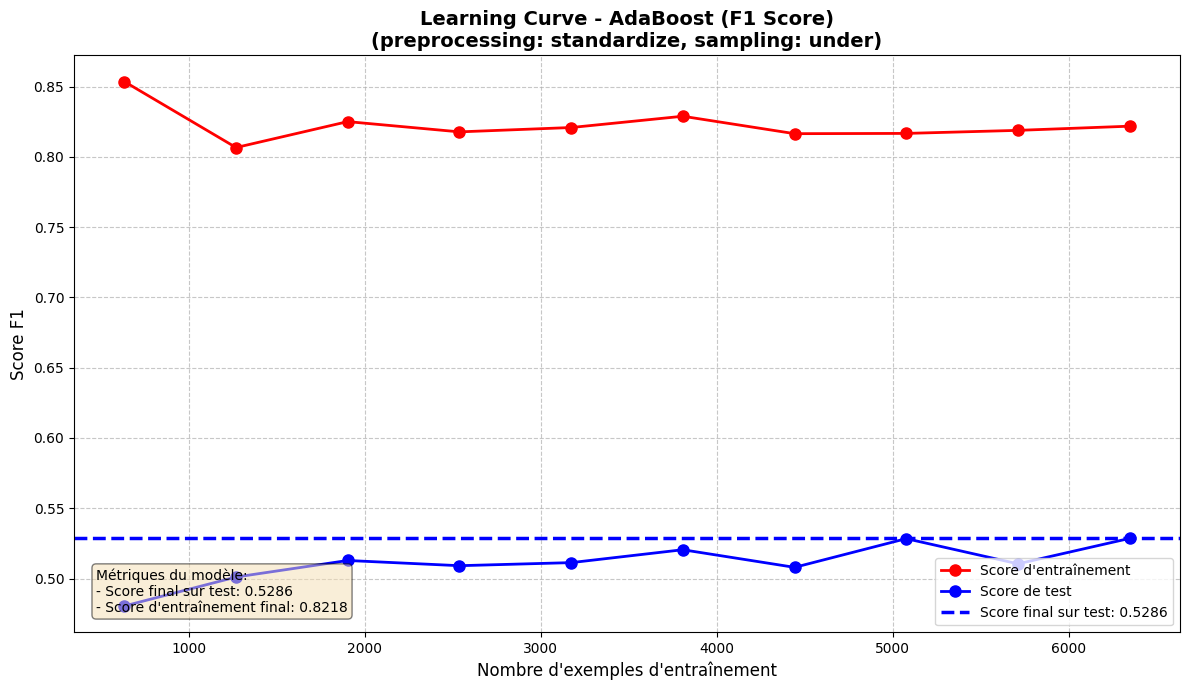

[I 2025-03-07 22:33:25,293] A new study created in memory with name: no-name-704f0574-fbaa-4d05-86b2-a6fdb917537b



Classification report for AdaBoost:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      7985
           1       0.39      0.82      0.53      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.83      0.71      9043
weighted avg       0.90      0.83      0.85      9043

Optimizing hyperparameters for KNN (preprocessing: standardize, sampling: under)...


[I 2025-03-07 22:33:26,117] Trial 0 finished with value: 0.48012519561815337 and parameters: {'n_neighbors': 10, 'weights': 'distance'}. Best is trial 0 with value: 0.48012519561815337.
[I 2025-03-07 22:33:26,885] Trial 1 finished with value: 0.4533571004159239 and parameters: {'n_neighbors': 5, 'weights': 'distance'}. Best is trial 0 with value: 0.48012519561815337.
[I 2025-03-07 22:33:27,829] Trial 2 finished with value: 0.48719723183391006 and parameters: {'n_neighbors': 37, 'weights': 'distance'}. Best is trial 2 with value: 0.48719723183391006.
[I 2025-03-07 22:33:28,508] Trial 3 finished with value: 0.484015125472671 and parameters: {'n_neighbors': 33, 'weights': 'distance'}. Best is trial 2 with value: 0.48719723183391006.
[I 2025-03-07 22:33:29,157] Trial 4 finished with value: 0.48166431593794073 and parameters: {'n_neighbors': 47, 'weights': 'distance'}. Best is trial 2 with value: 0.48719723183391006.
[I 2025-03-07 22:33:29,714] Trial 5 finished with value: 0.481116025859135

Best hyperparameters for KNN: {'n_neighbors': 14, 'weights': 'uniform'}
Best F1-score on test data: 0.4878


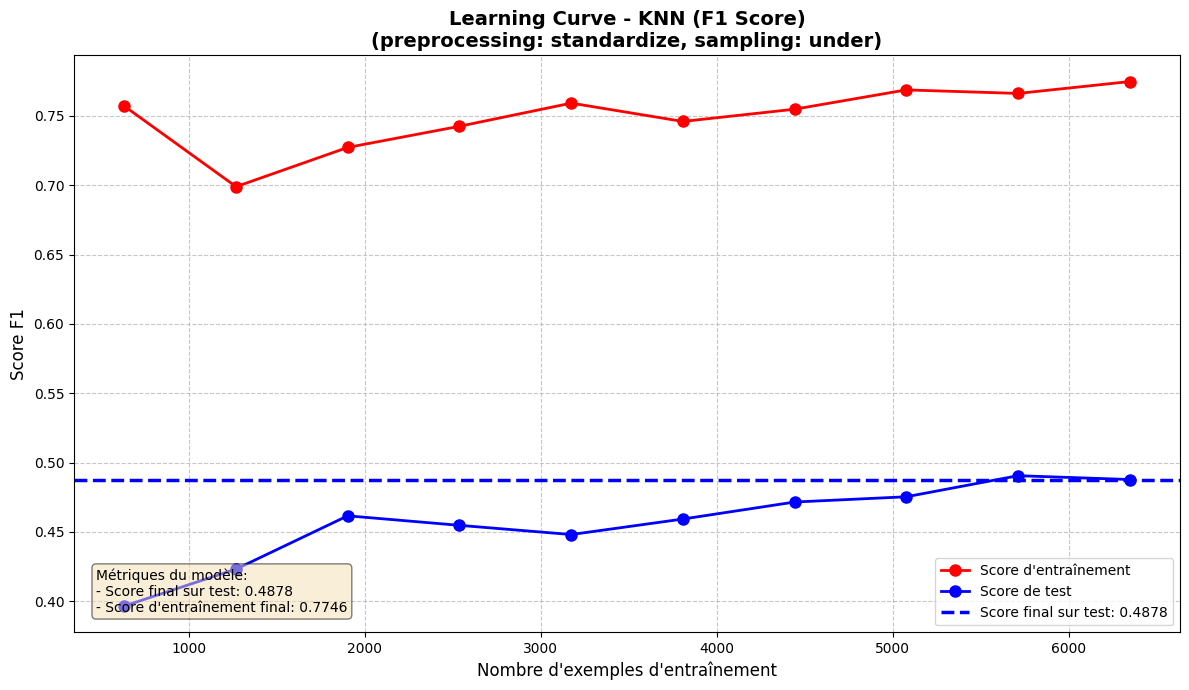

[I 2025-03-07 22:33:51,489] A new study created in memory with name: no-name-86ff8748-9a92-4da3-81b2-fcada50c0c71



Classification report for KNN:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7985
           1       0.39      0.65      0.49      1058

    accuracy                           0.84      9043
   macro avg       0.67      0.76      0.70      9043
weighted avg       0.88      0.84      0.86      9043

Optimizing hyperparameters for XGBoost (preprocessing: standardize, sampling: under)...


[I 2025-03-07 22:33:53,972] Trial 0 finished with value: 0.50956749672346 and parameters: {'n_estimators': 113, 'max_depth': 15, 'learning_rate': 0.19261085659585547, 'subsample': 0.594661452593422, 'colsample_bytree': 0.9541087158877264}. Best is trial 0 with value: 0.50956749672346.
[I 2025-03-07 22:33:54,393] Trial 1 finished with value: 0.33884565499351493 and parameters: {'n_estimators': 137, 'max_depth': 6, 'learning_rate': 0.014705585146218898, 'subsample': 0.9190879213283889, 'colsample_bytree': 0.9777341733051044}. Best is trial 0 with value: 0.50956749672346.
[I 2025-03-07 22:33:55,251] Trial 2 finished with value: 0.5189393939393939 and parameters: {'n_estimators': 197, 'max_depth': 14, 'learning_rate': 0.29993480781343723, 'subsample': 0.6517881357529904, 'colsample_bytree': 0.9941447423595837}. Best is trial 2 with value: 0.5189393939393939.
[I 2025-03-07 22:33:55,646] Trial 3 finished with value: 0.40423446383062145 and parameters: {'n_estimators': 211, 'max_depth': 5, 'l

Best hyperparameters for XGBoost: {'n_estimators': 259, 'max_depth': 9, 'learning_rate': 0.2189370134867919, 'subsample': 0.7578493816435172, 'colsample_bytree': 0.5712298911722264}
Best F1-score on test data: 0.5279


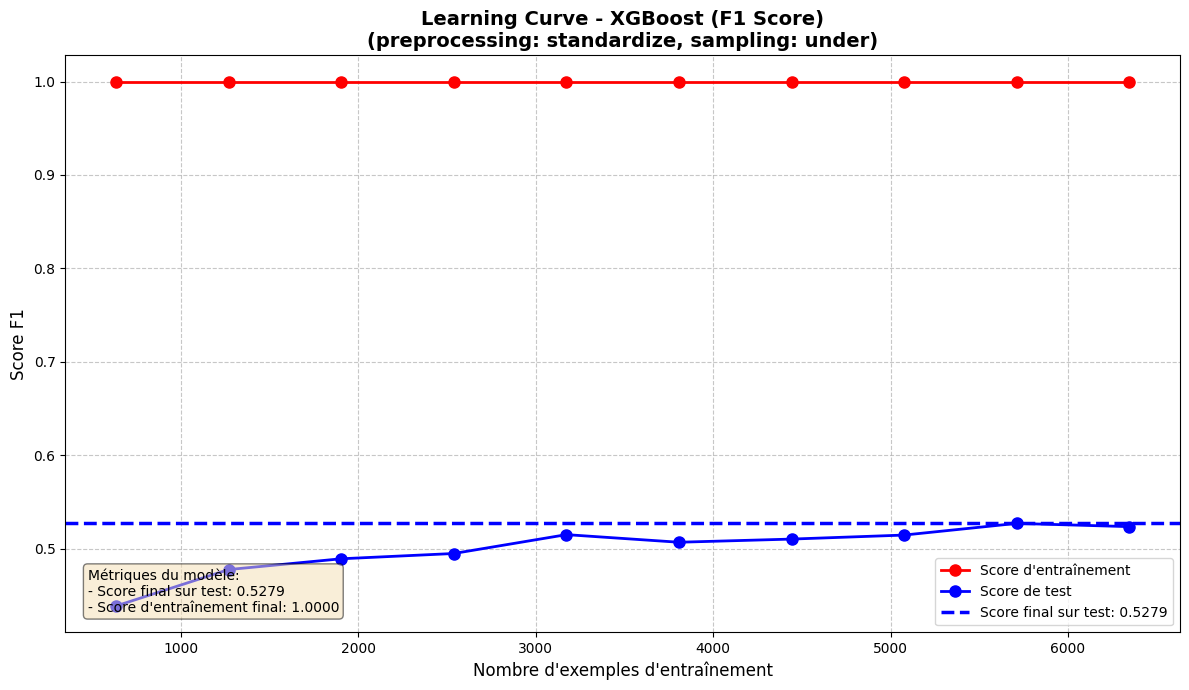

[I 2025-03-07 22:34:16,378] A new study created in memory with name: no-name-7675e2f8-1093-402f-b716-f7ca29b088d7
[I 2025-03-07 22:34:16,434] Trial 0 finished with value: 0.4279835390946502 and parameters: {'alpha': 0.08861258922876208, 'max_iter': 2066}. Best is trial 0 with value: 0.4279835390946502.
[I 2025-03-07 22:34:16,486] Trial 1 finished with value: 0.4279835390946502 and parameters: {'alpha': 0.00018492317580551056, 'max_iter': 512}. Best is trial 0 with value: 0.4279835390946502.



Classification report for XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.80      0.88      7985
           1       0.37      0.91      0.53      1058

    accuracy                           0.81      9043
   macro avg       0.68      0.85      0.70      9043
weighted avg       0.91      0.81      0.84      9043

Optimizing hyperparameters for Perceptron (preprocessing: standardize, sampling: under)...


[I 2025-03-07 22:34:16,586] Trial 2 finished with value: 0.4279835390946502 and parameters: {'alpha': 0.002799600479709795, 'max_iter': 2804}. Best is trial 0 with value: 0.4279835390946502.
[I 2025-03-07 22:34:16,656] Trial 3 finished with value: 0.4279835390946502 and parameters: {'alpha': 3.132850477924028e-05, 'max_iter': 1543}. Best is trial 0 with value: 0.4279835390946502.
[I 2025-03-07 22:34:16,798] Trial 4 finished with value: 0.4279835390946502 and parameters: {'alpha': 0.00017451478731597879, 'max_iter': 2883}. Best is trial 0 with value: 0.4279835390946502.
[I 2025-03-07 22:34:16,937] Trial 5 finished with value: 0.4279835390946502 and parameters: {'alpha': 0.00858857255467636, 'max_iter': 2427}. Best is trial 0 with value: 0.4279835390946502.
[I 2025-03-07 22:34:17,056] Trial 6 finished with value: 0.4279835390946502 and parameters: {'alpha': 0.002901773065622162, 'max_iter': 2247}. Best is trial 0 with value: 0.4279835390946502.
[I 2025-03-07 22:34:17,178] Trial 7 finishe

Best hyperparameters for Perceptron: {'alpha': 0.08861258922876208, 'max_iter': 2066}
Best F1-score on test data: 0.4280


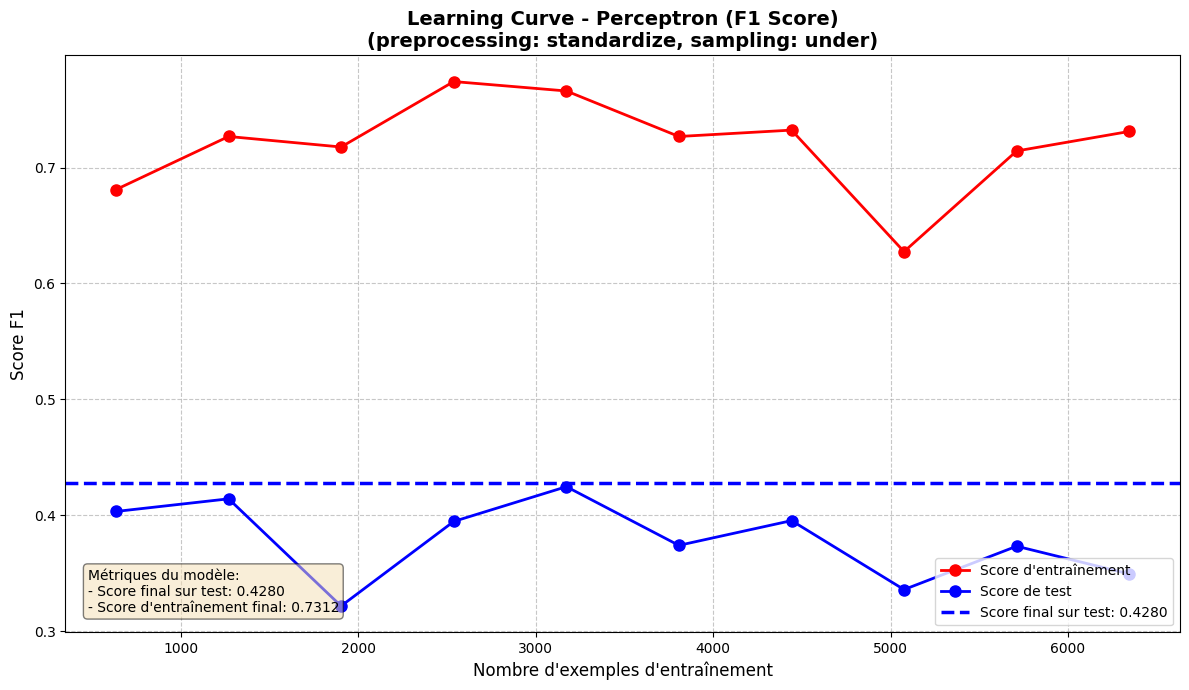


Classification report for Perceptron:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      7985
           1       0.32      0.64      0.43      1058

    accuracy                           0.80      9043
   macro avg       0.63      0.73      0.65      9043
weighted avg       0.87      0.80      0.83      9043


 Best model for standardize/under: Random Forest with F1 score of 0.5484
Model: Logistic Regression
F1 Score (Binary): 0.5205
F1 Score (Weighted): 0.8539

Model: Random Forest
F1 Score (Binary): 0.5484
F1 Score (Weighted): 0.8535

Model: Naive Bayes
F1 Score (Binary): 0.4135
F1 Score (Weighted): 0.8475

Model: AdaBoost
F1 Score (Binary): 0.5286
F1 Score (Weighted): 0.8524

Model: KNN
F1 Score (Binary): 0.4878
F1 Score (Weighted): 0.8561

Model: XGBoost
F1 Score (Binary): 0.5279
F1 Score (Weighted): 0.8391

Model: Perceptron
F1 Score (Binary): 0.4280
F1 Score (Weighted): 0.8262



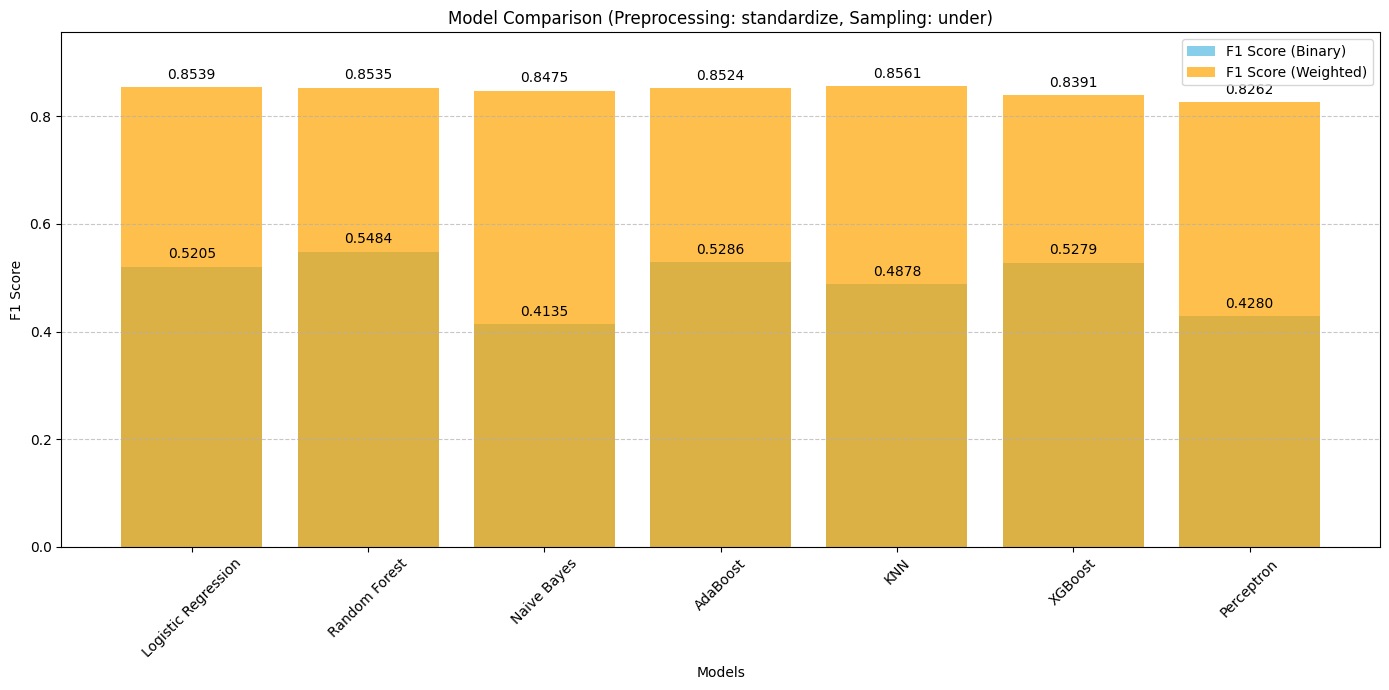


 BEST OVERALL MODEL 
Model: Random Forest
Preprocessing: normalize
Sampling strategy: over
F1 Score: 0.6045
Hyperparameters: {'n_estimators': 120, 'max_depth': 23, 'min_samples_leaf': 4}


In [ ]:
# Usage :
best_model, best_params, best_score = find_best_model_overall(X_train, y_train, X_test, y_test, n_trials=20)

#### Model Performance Analysis
From the graphs, we can see that our model struggles to generalize well on the test set. We can say that it could be normal since our dataset is bery imblanced.

#### Results on *bank.csv* Dataset
The **XGBoost** model, trained with standardized data and an oversampling strategy to address class imbalance, achieved the highest **F1-score of 0.6455**. The optimized hyperparameters include:
- **Number of estimators**: 210
- **Maximum depth**: 10
- **Learning rate**: 0.057
- Additional parameters like `subsample` and `colsample_bytree` were fine-tuned to enhance generalization.

#### Results on *bank-full.csv* Dataset
For the *bank-full.csv* dataset, the **Random Forest** model, trained with normalized data and an oversampling strategy, achieved an **F1-score of 0.6045**. The optimized hyperparameters include:
- **Number of estimators**: 120
- **Maximum depth**: 23
- **Minimum samples leaf**: 4


In [ ]:
# TEST XGBoost with all parameters and different data repartition
preprocessing_methods = {
    'standardized': StandardScaler(),
    'normalized': MinMaxScaler()
}

sampling_strategies = {
    'none': None,
    'oversampling': RandomOverSampler(random_state=42),
    'undersampling': RandomUnderSampler(random_state=42)
}

def evaluate_xgboost(preprocessing_name, scaler, sampling_name, sampler):
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    if sampler:
        X_train_scaled, y_train_resampled = sampler.fit_resample(X_train_scaled, y_train)
    else:
        y_train_resampled = y_train
    scale_pos_weight = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'eval_metric': 'logloss'
        }

        model = XGBClassifier(**params)
        model.fit(X_train_scaled, y_train_resampled)

        y_pred = model.predict(X_test_scaled)
        return f1_score(y_test, y_pred, pos_label=1)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    print(f"\nResults for {preprocessing_name} data with {sampling_name}:")
    print("Best hyperparameters:", study.best_params)
    print("Best F1 score:", study.best_value)

    best_model = XGBClassifier(**study.best_params, random_state=42)
    best_model.fit(X_train_scaled, y_train_resampled)


    y_pred = best_model.predict(X_test_scaled)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

for preprocessing_name, scaler in preprocessing_methods.items():
    for sampling_name, sampler in sampling_strategies.items():
        evaluate_xgboost(preprocessing_name, scaler, sampling_name, sampler)

[I 2025-03-07 22:35:08,751] A new study created in memory with name: no-name-5fece5b7-5fe8-4105-845a-211ba8608c37
[I 2025-03-07 22:35:10,150] Trial 0 finished with value: 0.5816759047929573 and parameters: {'n_estimators': 113, 'max_depth': 4, 'learning_rate': 0.27809379034249043, 'subsample': 0.6011210849439366, 'colsample_bytree': 0.9336746176927408}. Best is trial 0 with value: 0.5816759047929573.
[I 2025-03-07 22:35:16,733] Trial 1 finished with value: 0.5827067669172933 and parameters: {'n_estimators': 199, 'max_depth': 11, 'learning_rate': 0.2037577336426623, 'subsample': 0.8758253049122697, 'colsample_bytree': 0.5587726617093116}. Best is trial 1 with value: 0.5827067669172933.
[I 2025-03-07 22:35:18,658] Trial 2 finished with value: 0.5822102425876011 and parameters: {'n_estimators': 111, 'max_depth': 5, 'learning_rate': 0.27910121448183633, 'subsample': 0.6812375530670036, 'colsample_bytree': 0.5166557006244996}. Best is trial 1 with value: 0.5827067669172933.
[I 2025-03-07 22


Results for standardized data with none:
Best hyperparameters: {'n_estimators': 85, 'max_depth': 11, 'learning_rate': 0.09128790124279096, 'subsample': 0.5197343423787377, 'colsample_bytree': 0.6970329522942963}
Best F1 score: 0.6056661562021439


[I 2025-03-07 22:36:11,473] A new study created in memory with name: no-name-dfa9e525-ce20-4d50-a863-ae3355e7db79



Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.63      0.42      0.51      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.73      9043
weighted avg       0.89      0.90      0.89      9043



[I 2025-03-07 22:36:20,883] Trial 0 finished with value: 0.5877991236939669 and parameters: {'n_estimators': 286, 'max_depth': 6, 'learning_rate': 0.060315203927543, 'subsample': 0.9910417460701113, 'colsample_bytree': 0.9638023974736559}. Best is trial 0 with value: 0.5877991236939669.
[I 2025-03-07 22:36:30,045] Trial 1 finished with value: 0.5618305744888024 and parameters: {'n_estimators': 300, 'max_depth': 14, 'learning_rate': 0.25195777082227205, 'subsample': 0.876283062075468, 'colsample_bytree': 0.829723327884107}. Best is trial 0 with value: 0.5877991236939669.
[I 2025-03-07 22:36:33,275] Trial 2 finished with value: 0.5695301376364499 and parameters: {'n_estimators': 192, 'max_depth': 14, 'learning_rate': 0.16737163614372588, 'subsample': 0.8446717225277083, 'colsample_bytree': 0.8888177859146448}. Best is trial 0 with value: 0.5877991236939669.
[I 2025-03-07 22:36:36,189] Trial 3 finished with value: 0.5828828828828829 and parameters: {'n_estimators': 217, 'max_depth': 11, '

...


Results for normalized data with oversampling:
Best hyperparameters: {'n_estimators': 296, 'max_depth': 10, 'learning_rate': 0.03707003812851411, 'subsample': 0.5478978938743344, 'colsample_bytree': 0.6529504987070783}
Best F1 score: 0.6022988505747127


[I 2025-03-07 22:39:32,111] A new study created in memory with name: no-name-b15002ae-553e-4739-b707-9de3d0861810



Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7985
           1       0.51      0.74      0.60      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.82      0.77      9043
weighted avg       0.91      0.89      0.89      9043



[I 2025-03-07 22:39:32,423] Trial 0 finished with value: 0.56036866359447 and parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.208389163334776, 'subsample': 0.7955242224516723, 'colsample_bytree': 0.6331491929312402}. Best is trial 0 with value: 0.56036866359447.
[I 2025-03-07 22:39:32,837] Trial 1 finished with value: 0.5641800060404711 and parameters: {'n_estimators': 85, 'max_depth': 10, 'learning_rate': 0.06251893753137916, 'subsample': 0.7057293977916828, 'colsample_bytree': 0.7903117044702066}. Best is trial 1 with value: 0.5641800060404711.
[I 2025-03-07 22:39:33,258] Trial 2 finished with value: 0.5623471882640587 and parameters: {'n_estimators': 183, 'max_depth': 7, 'learning_rate': 0.08177091984755279, 'subsample': 0.5625938626589362, 'colsample_bytree': 0.549198834671183}. Best is trial 1 with value: 0.5641800060404711.
[I 2025-03-07 22:39:33,864] Trial 3 finished with value: 0.5600486470051688 and parameters: {'n_estimators': 164, 'max_depth': 13, 'learn


Results for normalized data with undersampling:
Best hyperparameters: {'n_estimators': 275, 'max_depth': 13, 'learning_rate': 0.16990423442527222, 'subsample': 0.9934492959560909, 'colsample_bytree': 0.6001129814818331}
Best F1 score: 0.5715162676488643

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.91      7985
           1       0.42      0.88      0.57      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.86      0.74      9043
weighted avg       0.92      0.85      0.87      9043



We have used XGBoost due to its ability to efficiently handle large datasets and its robustness against overfitting. This efficiency is detailed in this article: https://www.ibm.com/think/topics/xgboost

Additionally, Optuna has proven to be very performant compared to GridSearch for hyperparameter optimization, thanks to its Bayesian optimization approach that significantly reduces computation time. The full reference is available here: https://optuna.readthedocs.io/en/stable/

https://medium.com/optuna/using-optuna-to-optimize-xgboost-hyperparameters-63bfcdfd3407

#Conclusion

Our current highest F1 score is 0.60, which is fairly good considering that the dataset is highly imbalanced.

We have tried different approaches, including those covered during the course, as well as leveraging our knowledge from online resources. Our goal was to explore various models, experiment with different techniques, and improve our model's performance by fine-tuning the best hyperparameters.

Some techniques yielded very promising results, while others struggled to generalize well, leading to overfitting.

Our current best models are :

**Optimized Random Forest Model with Hyperparameter Tuning Using Optuna**

Achieved **F1-score: 0.6045**
The model was fine-tuned using Optuna for hyperparameter optimization.

The best-performing configuration includes the following hyperparameters:

*  **Number of estimators** (n_estimators): 120
*  **Maximum depth** (max_depth): 23


**XGBoost on Raw data (not normalized or standarized) and balancing training Data using Smote and choosing HyperParameters with gridSearch cv:**

* Accuracy: 0.87
* Precision: 0.458333
* Recall: 0.634615
* **F1 Score: 0.594011**
* F1 Score weighted: 0.884827
* AUC: 0.91904
* PR AUC: 0.571076

**Random Forest on Raw data and Balancing training Data using SMOTE:**
* Accuracy: 0.893398
* Precision: 0.537420
* Recall: 0.637996
* **F1 Score : 0.583405**
* F1 Score (Weighted): 0.897290
* AUC: 0.913493

**XGBoost (Std) on standarized data and blanacing data using class_weight='balanced' for models:**

* Accuracy: 0.863651
* Precision: 0.454640
* Recall: 0.828922
* **F1 Score : 0.587211**
* F1 Score (Weighted): 0.879598
* AUC: 0.922295
* PR AUC: 0.573948

